In [5]:
import requests
import re

API_FILE = "api_links.txt"


def extract_id(url: str):
    match = re.search(r"I(\d+)_", url)
    return match.group(1) if match else "unknown"


def get_dimensions_from_url(url):
    result = requests.get(url, timeout=60).json()

    dims = []

    headers = result.get("Headers", {}).get("Items", [])

    for h in headers:
        if str(h.get("indicator_dimension", "")).lower() == "dimension":
            dims.append({
                "id": h.get("ID"),
                "name": h.get("DisplayName")
            })

    return dims


def get_dimension_values(url, dim_ids):
    result = requests.get(url, timeout=60).json()
    data = result.get("Data", [])

    values = {d: set() for d in dim_ids}

    for row in data[:500]:  # limit for speed
        for d in dim_ids:
            if d in row:
                values[d].add(str(row[d]))

    return {k: list(v)[:10] for k, v in values.items()}


def main():
    with open(API_FILE, "r") as f:
        urls = [u.strip() for u in f.read().split("\n\n") if u.strip()]

    urls = urls[:5]  # just first few for now

    for url in urls:
        dataset_id = extract_id(url)

        print("\n" + "="*60)
        print(f"Dataset: {dataset_id}")

        dims = get_dimensions_from_url(url)

        if not dims:
            print("No dimensions found")
            continue

        print("\nDimensions:")
        for d in dims:
            print(f"  {d['id']} → {d['name']}")

        dim_ids = [d["id"] for d in dims]
        values = get_dimension_values(url, dim_ids)

        print("\nSample Values:")
        for k, v in values.items():
            print(f"  {k}: {v}")


if __name__ == "__main__":
    main()


Dataset: 1139

Dimensions:
  Country → Country
  StateCode → State lgd code
  StateName → State
  DistrictCode → District lgd code
  DistrictName → District
  Year → Year
  D1139_4 → Sector

Sample Values:
  Country: ['India']
  StateCode: ['3', '1', '2']
  StateName: ['Punjab', 'Jammu And Kashmir', 'Himachal Pradesh']
  DistrictCode: ['32', '23', '28', '7', '20', '13', '14', '29', '10', '8']
  DistrictName: ['Unknown Districts Of India', 'Rajouri', 'Kullu', 'Sirmaur', 'Kangra', 'Jammu', 'Bathinda', 'Doda', 'Solan', 'Shimla']
  Year: ['Calendar Year (Jan - Dec), 2024', 'Calendar Year (Jan - Dec), 2022', 'Calendar Year (Jan - Dec), 2017', 'Calendar Year (Jan - Dec), 2018', 'Calendar Year (Jan - Dec), 2020', 'Calendar Year (Jan - Dec), 2021', 'Calendar Year (Jan - Dec), 2025', 'Calendar Year (Jan - Dec), 2023', 'Calendar Year (Jan - Dec), 2019']
  D1139_4: ['Public', 'Private']

Dataset: 1201

Dimensions:
  Country → Country
  StateCode → State lgd code
  StateName → State
  Year → Year

In [11]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data/raw")

import re

def get_dimension_columns(df):
    dimension_cols = []

    for c in df.columns:
        if re.match(r"^D\d+", c):   # D followed by number
            dimension_cols.append(c)
        elif c in ["TRU", "Gender"]:
            dimension_cols.append(c)

    return dimension_cols

def detect_columns(df):
    indicator_cols = [c for c in df.columns if c.startswith("I")]
    dimension_cols =  get_dimension_columns(df)
    structural_cols = [
        c for c in df.columns
        if c in ["Country", "StateCode", "StateName", "DistrictCode", "DistrictName", "Year"]
    ]

    return indicator_cols, dimension_cols, structural_cols


def analyze_file(file_path):
    print("\n" + "="*70)
    print(f"File: {file_path.name}")

    # read only first 500 rows for speed
    df = pd.read_csv(file_path, nrows=500)

    print("\nColumns:")
    print(df.columns.tolist())

    ind_cols, dim_cols, struct_cols = detect_columns(df)

    print("\nStructural Columns:")
    print(struct_cols)

    print("\nDimension Columns:")
    print(dim_cols)

    print("\nIndicator Columns (sample):")
    print(ind_cols[:10])

    # show dimension values
    if dim_cols:
        print("\nDimension Values:")
        for col in dim_cols:
            vals = df[col].dropna().astype(str).unique()[:10]
            print(f"  {col}: {list(vals)}")


def main():
    files = list(DATA_DIR.glob("*.csv"))

    for f in files:
        analyze_file(f)


if __name__ == "__main__":
    main()


File: Health_Expenditure_PerCapita_raw.csv

Columns:
['Country', 'StateName', 'StateCode', 'Year', 'D2660_6', 'Number_of_sub_centres_sum', 'Number_of_sub_centres_avg', 'Number_of_Primary_Health_Centres_PHC_sum', 'Number_of_Primary_Health_Centres_PHC_avg', 'Number_of_Community_Health_Centres_CHC_sum', 'Number_of_Community_Health_Centres_CHC_avg']

Structural Columns:
['Country', 'StateName', 'StateCode', 'Year']

Dimension Columns:
['D2660_6']

Indicator Columns (sample):
[]

Dimension Values:
  D2660_6: ['State / UT has no separate Tribal Area / Population', 'State has predominantly tribal areas']

File: Health_Expenditure_PerCapita_state.csv

Columns:
['Country', 'StateName', 'StateCode', 'Year', 'D2660_6', 'Number_of_sub_centres_sum', 'Number_of_sub_centres_avg', 'Number_of_Primary_Health_Centres_PHC_sum', 'Number_of_Primary_Health_Centres_PHC_avg', 'Number_of_Community_Health_Centres_CHC_sum', 'Number_of_Community_Health_Centres_CHC_avg']

Structural Columns:
['Country', 'StateName

In [27]:
import pandas as pd
from pathlib import Path

RAW_DIR  = Path("data/raw")
CLEAN_DIR = Path("data/cleaned")
CLEAN_DIR.mkdir(parents=True, exist_ok=True)


# ── helpers ───────────────────────────────────────────────────────────────────

def safe_rename(df, mapping):
    for k in mapping:
        if k not in df.columns:
            print(f"  WARNING: rename target '{k}' not found — skipping")
    return df.rename(columns={k: v for k, v in mapping.items() if k in df.columns})


def base_clean(df):
    # Extract first 4-digit year safely
    df["Year"] = (
        df["Year"].astype(str)
        .str.extract(r"(\d{4})")[0]
        .astype(float)
        .astype("Int64")
    )
    df = df.drop_duplicates()
    sort_keys = [c for c in ["StateCode", "DistrictCode", "Year"] if c in df.columns]
    df = df.sort_values(sort_keys).reset_index(drop=True)
    return df


def safe_divide(num_col, den_col, df):
    """Division with zero/null safety. Returns Series."""
    return df[num_col] / df[den_col].replace(0, pd.NA)


def norm_str(series):
    """Lowercase + strip for reliable string matching."""
    return series.astype(str).str.lower().str.strip()


# ── per-file cleaning ─────────────────────────────────────────────────────────

def clean_rhs_statewise():
    df = pd.read_csv(RAW_DIR / "RHS_Statewise_state.csv")
    df = base_clean(df)

    rename_map = {
        "Female_health_worker_or_auxiliary_nurse_midwife_anm_in_position_in_rural_areas_avg":  "anm_in_position",
        "Female_health_worker_or_auxiliary_nurse_midwife_required_in_rural_areas_avg":         "anm_required",
        "Doctors_in_positions_at_primary_health_centres_phc_in_rural_areas_avg":               "phc_doctors_in_position",
        "Doctors_requirements_at_primary_health_centres_phc_in_rural_areas_avg":               "phc_doctors_required",
        "Specialists_in_position_at_community_health_centres_chc_in_rural_areas_avg":          "chc_specialists_in_position",
        "Specialists_required_at_community_health_centres_chc_in_rural_areas_avg":             "chc_specialists_required",
        "Lab_technicians_in_position_at_community_health_centres_chc_and_primary_health_centres_phc_in_rural_areas_avg": "lab_tech_in_position",
        "Lab_technicians_required_at_community_health_centres_chc_and_primary_health__centres_phcin_rural_areas_avg":    "lab_tech_required",
        "Pharmacists_in_position_at_community_health_centres_chc_and_primary_health_centres_phc_in_rural_areas_avg":     "pharmacist_in_position",
        "Pharmacists_required_at_community_health_centres_chc_and_primary_health_centres_phc_in_rural_areas_avg":        "pharmacist_required",
        "Nursing_staff_in_position_at_community_health_centres_chc_and_primary_health_centres_phc_in_rural_areas_avg":   "nursing_in_position",
        "Nursing_staff_required_at_community_health_centres_chc_and_primary_health_centres_centres_phc_in_rural_areas_avg": "nursing_required",
        # also try without _avg suffix in case base_clean stripped it
        "Female_health_worker_or_auxiliary_nurse_midwife_anm_in_position_in_rural_areas":  "anm_in_position",
        "Female_health_worker_or_auxiliary_nurse_midwife_required_in_rural_areas":         "anm_required",
        "Doctors_in_positions_at_primary_health_centres_phc_in_rural_areas":               "phc_doctors_in_position",
        "Doctors_requirements_at_primary_health_centres_phc_in_rural_areas":               "phc_doctors_required",
        "Specialists_in_position_at_community_health_centres_chc_in_rural_areas":          "chc_specialists_in_position",
        "Specialists_required_at_community_health_centres_chc_in_rural_areas":             "chc_specialists_required",
        "Lab_technicians_in_position_at_community_health_centres_chc_and_primary_health_centres_phc_in_rural_areas": "lab_tech_in_position",
        "Lab_technicians_required_at_community_health_centres_chc_and_primary_health__centres_phcin_rural_areas":    "lab_tech_required",
        "Pharmacists_in_position_at_community_health_centres_chc_and_primary_health_centres_phc_in_rural_areas":     "pharmacist_in_position",
        "Pharmacists_required_at_community_health_centres_chc_and_primary_health_centres_phc_in_rural_areas":        "pharmacist_required",
        "Nursing_staff_in_position_at_community_health_centres_chc_and_primary_health_centres_phc_in_rural_areas":   "nursing_in_position",
        "Nursing_staff_required_at_community_health_centres_chc_and_primary_health_centres_centres_phc_in_rural_areas": "nursing_required",
    }
    df = safe_rename(df, rename_map)

    fill_pairs = [
        ("lab_tech_fill_rate",       "lab_tech_in_position",       "lab_tech_required"),
        ("phc_doctor_fill_rate",     "phc_doctors_in_position",    "phc_doctors_required"),
        ("chc_specialist_fill_rate", "chc_specialists_in_position","chc_specialists_required"),
        ("anm_fill_rate",            "anm_in_position",            "anm_required"),
        ("pharmacist_fill_rate",     "pharmacist_in_position",     "pharmacist_required"),
    ]
    for rate_col, num, den in fill_pairs:
        if num in df.columns and den in df.columns:
            df[rate_col] = safe_divide(num, den, df).clip(upper=1.0)
        else:
            print(f"  WARNING: cannot compute {rate_col} — missing {num} or {den}")

    keep = ["StateCode", "StateName", "Year",
            "lab_tech_fill_rate", "phc_doctor_fill_rate",
            "chc_specialist_fill_rate", "anm_fill_rate", "pharmacist_fill_rate"]
    return df[[c for c in keep if c in df.columns]]


def clean_rhs_districtwise():
    df = pd.read_csv(RAW_DIR / "RHS_Districtwise_district.csv")
    df = base_clean(df)
    df = safe_rename(df, {
        "Functional_Primary_Health_Centres_PHCs_avg":   "phc_count",
        "Functional_Community_Health_Centres_CHCs_avg": "chc_count",
        "Functional_Sub_Centres_avg":                   "sc_count",
        "Functional_District_Hospitals_DHs_avg":        "dh_count",
        # without _avg
        "Functional_Primary_Health_Centres_PHCs":   "phc_count",
        "Functional_Community_Health_Centres_CHCs": "chc_count",
        "Functional_Sub_Centres":                   "sc_count",
        "Functional_District_Hospitals_DHs":        "dh_count",
    })
    keep = ["StateCode", "StateName", "DistrictCode", "DistrictName", "Year",
            "phc_count", "chc_count", "sc_count", "dh_count"]
    return df[[c for c in keep if c in df.columns]]


def clean_tb_outcome_total():
    df = pd.read_csv(RAW_DIR / "TB_TreatmentOutcome_Total_state.csv")
    df = base_clean(df)
    df = safe_rename(df, {
        "Percentage_of_success_rate_avg":           "success_rate",
        "Percentage_of_lost_to_follow_up_avg":      "ltfu_rate",
        "Percentage_of_death_rate_avg":             "death_rate",
        "Percentage_of_treatment_failure_rate_avg": "failure_rate",
        "Number_of_TB_patients_notified_avg":       "tb_patients_notified",
        # without _avg
        "Percentage_of_success_rate":           "success_rate",
        "Percentage_of_lost_to_follow_up":      "ltfu_rate",
        "Percentage_of_death_rate":             "death_rate",
        "Percentage_of_treatment_failure_rate": "failure_rate",
        "Number_of_TB_patients_notified":       "tb_patients_notified",
    })
    keep = ["StateCode", "StateName", "Year",
            "success_rate", "ltfu_rate", "death_rate", "failure_rate", "tb_patients_notified"]
    return df[[c for c in keep if c in df.columns]]


def clean_tb_outcome_public():
    df = pd.read_csv(RAW_DIR / "TB_TreatmentOutcome_Public_state.csv")
    df = base_clean(df)
    df = safe_rename(df, {
        "Percentage_of_successful_treatments_for_tuberculosistb_avg": "success_rate_public",
        "Percentage_of_tuberculosistb_cases_lost_to_followup_avg":    "ltfu_rate_public",
        "Percentage_of_deaths_due_to_tuberculosistb_avg":             "death_rate_public",
        "Percentage_of_successful_treatments_for_tuberculosistb": "success_rate_public",
        "Percentage_of_tuberculosistb_cases_lost_to_followup":    "ltfu_rate_public",
        "Percentage_of_deaths_due_to_tuberculosistb":             "death_rate_public",
    })
    keep = ["StateCode", "StateName", "Year",
            "success_rate_public", "ltfu_rate_public", "death_rate_public"]
    return df[[c for c in keep if c in df.columns]]


def clean_tb_outcome_private():
    df = pd.read_csv(RAW_DIR / "TB_TreatmentOutcome_Private_state.csv")
    df = base_clean(df)
    df = safe_rename(df, {
        "Percentage_of_successful_treatments_for_tuberculosistb_avg": "success_rate_private",
        "Percentage_of_tuberculosistb_cases_lost_to_followup_avg":    "ltfu_rate_private",
        "Percentage_of_deaths_due_to_tuberculosistb_avg":             "death_rate_private",
        "Percentage_of_successful_treatments_for_tuberculosistb": "success_rate_private",
        "Percentage_of_tuberculosistb_cases_lost_to_followup":    "ltfu_rate_private",
        "Percentage_of_deaths_due_to_tuberculosistb":             "death_rate_private",
    })
    keep = ["StateCode", "StateName", "Year",
            "success_rate_private", "ltfu_rate_private", "death_rate_private"]
    return df[[c for c in keep if c in df.columns]]


def clean_tb_notification():
    # No _state.csv exists — raw file has district rows, aggregate to state
    df = pd.read_csv(RAW_DIR / "TB_Notification_raw.csv")
    df = base_clean(df)
    df = safe_rename(df, {"D1139_4": "sector"})

    # Pick _sum columns for counts before aggregating
    ach_col = next((c for c in df.columns if "Achievement_till_date" in c and c.endswith("_sum")), None)
    tgt_col = next((c for c in df.columns if "Annual_target" in c and c.endswith("_sum")), None)

    if not ach_col or not tgt_col:
        raise ValueError(f"Cannot find achievement/target columns. Available: {df.columns.tolist()}")

    df_agg = (
        df.groupby(["StateCode", "StateName", "Year"], as_index=False)
          .agg(
              notification_achievement=(ach_col, "sum"),
              notification_target=(tgt_col, "sum"),
          )
    )
    df_agg["notification_achievement_rate"] = safe_divide(
        "notification_achievement", "notification_target", df_agg
    )
    return df_agg


def clean_tb_presumptive():
    df = pd.read_csv(RAW_DIR / "TB_PresumptiveCases_state.csv")
    df = base_clean(df)
    df = safe_rename(df, {
        "Total_number_of_presumptive_TB_cases_examined_avg":     "presumptive_cases_examined",
        "Rate_of_presumptive_TuberculosisTB_cases_examined_avg": "presumptive_examination_rate",
        "Population_avg":                                        "population",
        "Total_number_of_presumptive_TB_cases_examined":     "presumptive_cases_examined",
        "Rate_of_presumptive_TuberculosisTB_cases_examined": "presumptive_examination_rate",
        "Population":                                        "population",
    })
    keep = ["StateCode", "StateName", "Year",
            "presumptive_cases_examined", "presumptive_examination_rate", "population"]
    return df[[c for c in keep if c in df.columns]]


def clean_tb_patient_characteristics():
    df = pd.read_csv(RAW_DIR / "TB_PatientCharacteristics_state.csv")
    df = base_clean(df)
    df = safe_rename(df, {
        "Percentage_of_cases_on_basis_of_diagnosis_was_bacteriologically_confirmed_avg": "bacteriologically_confirmed_pct",
        "Percentage_of_Drug_Resistant_Tuberculosis_DRTB_cases_notified_avg":             "drtb_pct",
        "Percentage_of_previously_treated_cases_notified_as_Tuberculosis_avg":           "previously_treated_pct",
        "Percentage_of_cases_on_basis_of_diagnosis_was_bacteriologically_confirmed": "bacteriologically_confirmed_pct",
        "Percentage_of_Drug_Resistant_Tuberculosis_DRTB_cases_notified":             "drtb_pct",
        "Percentage_of_previously_treated_cases_notified_as_Tuberculosis":           "previously_treated_pct",
    })
    keep = ["StateCode", "StateName", "Year",
            "bacteriologically_confirmed_pct", "drtb_pct", "previously_treated_pct"]
    return df[[c for c in keep if c in df.columns]]


def clean_tb_hiv():
    df = pd.read_csv(RAW_DIR / "TB_HIV_Coinfection_state.csv")
    df = base_clean(df)
    df = safe_rename(df, {
        "Total_percentage_of_TB_patients_with_known_HIV_status_avg": "tb_hiv_known_status_pct",
        "Percentage_of_TB-HIV_co-infected_patients_diagnosed_avg":   "tb_hiv_coinfected_pct",
        "Total_percentage_of_TB_patients_with_known_HIV_status": "tb_hiv_known_status_pct",
        "Percentage_of_TB-HIV_co-infected_patients_diagnosed":   "tb_hiv_coinfected_pct",
    })
    keep = ["StateCode", "StateName", "Year",
            "tb_hiv_known_status_pct", "tb_hiv_coinfected_pct"]
    return df[[c for c in keep if c in df.columns]]


def clean_tb_diabetes():
    df = pd.read_csv(RAW_DIR / "TB_Diabetes_Coinfection_state.csv")
    df = base_clean(df)
    df = safe_rename(df, {
        "Percentage_of_Tuberculosis_TB_patients_with_known_Diabetes_Mellitus_DM_status_under_public_sector_avg":  "tb_dm_known_status_pct",
        "Percentage_of_Tuberculosis_TB_and_Diabetes_Mellitus_DM_Patients_diagnosed_among_tested_under_public_sector_avg": "tb_dm_coinfected_pct",
        "Percentage_of_Tuberculosis_TB_patients_with_known_Diabetes_Mellitus_DM_status_under_public_sector":  "tb_dm_known_status_pct",
        "Percentage_of_Tuberculosis_TB_and_Diabetes_Mellitus_DM_Patients_diagnosed_among_tested_under_public_sector": "tb_dm_coinfected_pct",
    })
    keep = ["StateCode", "StateName", "Year",
            "tb_dm_known_status_pct", "tb_dm_coinfected_pct"]
    return df[[c for c in keep if c in df.columns]]


def clean_tb_tobacco():
    df = pd.read_csv(RAW_DIR / "TB_Tobacco_state.csv")
    df = base_clean(df)
    # D1221_3 = Public / Private sector — sum across both
    tobacco_col = next((c for c in df.columns if "tobacco_users_identified" in c.lower() and "_sum" in c), None)
    pct_col     = next((c for c in df.columns if "percentage_of_tobacco_users_identified" in c.lower() and "_avg" in c), None)

    df = safe_rename(df, {"D1221_3": "sector"})
    df_agg = df.groupby(["StateCode", "StateName", "Year"], as_index=False).agg(
        tb_tobacco_users_identified=(tobacco_col, "sum") if tobacco_col else ("sector", "count"),
    )
    if pct_col:
        pct_mean = df.groupby(["StateCode", "StateName", "Year"])[pct_col].mean().reset_index()
        pct_mean = pct_mean.rename(columns={pct_col: "tb_tobacco_pct"})
        df_agg = df_agg.merge(pct_mean, on=["StateCode", "StateName", "Year"], how="left")

    return df_agg


def clean_tb_gender():
    df = pd.read_csv(RAW_DIR / "TB_Gender_Disaggregated_Outcomes_state.csv")
    df = base_clean(df)
    df = safe_rename(df, {
        "GENDER": "gender",
        "Percentage_of_success_rate_on_Tuberculosis_TB_treatment_outcome_avg": "success_rate",
        "Percentage_of_death_rate_on_Tuberculosis_TB_treatment_outcome_avg":   "death_rate",
        "Number_of_TB_cases_notified_avg":                                     "cases_notified",
        "Percentage_of_success_rate_on_Tuberculosis_TB_treatment_outcome": "success_rate",
        "Percentage_of_death_rate_on_Tuberculosis_TB_treatment_outcome":   "death_rate",
        "Number_of_TB_cases_notified":                                     "cases_notified",
    })
    df["gender"] = norm_str(df["gender"])

    df_pivot = df.pivot_table(
        index=["StateCode", "StateName", "Year"],
        columns="gender",
        values=["success_rate", "death_rate", "cases_notified"],
        aggfunc="mean"
    )
    df_pivot.columns = [f"{metric}_{gender}" for metric, gender in df_pivot.columns]
    df_pivot = df_pivot.reset_index()

    if "success_rate_male" in df_pivot.columns and "success_rate_female" in df_pivot.columns:
        df_pivot["success_rate_gender_gap"] = (
            df_pivot["success_rate_male"] - df_pivot["success_rate_female"]
        )
    return df_pivot


def clean_tb_tribal():
    df = pd.read_csv(RAW_DIR / "TB_Tribal_state.csv")
    df = base_clean(df)
    df = safe_rename(df, {
        "Percentage_of_tribal_Tuberculosis_TB_patients_notified_based_on_diagnosing_Public_Health_Information_PHI_under_public_sector_avg": "tribal_tb_notification_pct",
        "Percentage_of_Tribal_Tuberculosis_TB_patients_initiated_on_treatment_under_public_sector_avg": "tribal_tb_treatment_initiation_pct",
        "Number_of_districts_partly_or_wholly_as_tribal_district_avg": "n_tribal_districts",
        "Percentage_of_tribal_Tuberculosis_TB_patients_notified_based_on_diagnosing_Public_Health_Information_PHI_under_public_sector": "tribal_tb_notification_pct",
        "Percentage_of_Tribal_Tuberculosis_TB_patients_initiated_on_treatment_under_public_sector": "tribal_tb_treatment_initiation_pct",
        "Number_of_districts_partly_or_wholly_as_tribal_district": "n_tribal_districts",
    })
    keep = ["StateCode", "StateName", "Year",
            "tribal_tb_notification_pct", "tribal_tb_treatment_initiation_pct", "n_tribal_districts"]
    return df[[c for c in keep if c in df.columns]]


def clean_nfhs():
    df = pd.read_csv(RAW_DIR / "Health_Expenditure_Statewise_state.csv")
    # no base_clean yet — need raw TRU and nfhs_round for filtering
    df = safe_rename(df, {"TRU": "rural_urban", "D6821_5": "nfhs_round"})

    # NFHS-5 has only Rural + Urban rows (no Total) — average them per state
    df_nfhs5 = df[df["nfhs_round"].astype(str).str.strip() == "NFHS-5"].copy()
    df_nfhs5 = df_nfhs5[df_nfhs5["rural_urban"].astype(str).str.strip().isin(["Rural", "Urban"])]
    df_nfhs5 = df_nfhs5.drop(columns=["rural_urban", "nfhs_round"], errors="ignore")

    # average numeric cols across Rural and Urban per state-year
    struct_cols = [c for c in df_nfhs5.columns if c in ["Country", "StateCode", "StateName", "Year"]]
    numeric_cols = df_nfhs5.select_dtypes(include="number").columns.tolist()
    df_agg = df_nfhs5.groupby(struct_cols, as_index=False)[numeric_cols].mean()

    # now apply base_clean (year parse, dedup, sort)
    df_agg = base_clean(df_agg)

    # find columns by fragment — robust to _avg suffix and long names
    def find_col(df, fragment):
        matches = [c for c in df.columns if fragment.lower() in c.lower()]
        return matches[0] if matches else None

    targets = {
        "stunted_height-for-age":                         "stunting_pct",
        "underweight_weight-for-age":                     "underweight_pct",
        "improved_sanitation_facility":                   "improved_sanitation_pct",
        "improved_drinking_water":                        "improved_water_pct",
        "health_insurance_or_financing":                  "health_insurance_coverage_pct",
        "15_years_and_above_who_use_any_kind_of_tobacco": "tobacco_use_men_pct",
    }
    rename_map = {}
    for fragment, new_name in targets.items():
        col = find_col(df_agg, fragment)
        if col:
            rename_map[col] = new_name
        else:
            print(f"  WARNING: NFHS col not found for '{fragment}'")

    df_agg = df_agg.rename(columns=rename_map)
    keep = ["StateCode", "StateName", "Year"] + list(targets.values())
    return df_agg[[c for c in keep if c in df_agg.columns]]

# def clean_nfhs():
#     df = pd.read_csv(RAW_DIR / "Health_Expenditure_Statewise_state.csv")
#     df = base_clean(df)

#     df = safe_rename(df, {"TRU": "rural_urban", "D6821_5": "nfhs_round"})

#     # DO NOT normalize before this

#     print("NFHS unique TRU:", df["rural_urban"].unique())
#     print("NFHS unique round:", df["nfhs_round"].unique())

#     # exact clean match (no regex, no mutation)
#     df = df[
#         (df["rural_urban"].astype(str).str.strip() == "Total") &
#         (df["nfhs_round"].astype(str).str.strip() == "NFHS-5")
#     ]

#     print("NFHS rows after filter:", len(df))

#     df = df.drop(columns=["rural_urban", "nfhs_round"], errors="ignore")

#     def find_col(df, fragment):
#         matches = [c for c in df.columns if fragment.lower() in c.lower()]
#         return matches[0] if matches else None

#     targets = {
#         "stunted_height":                         "stunting_pct",
#         "underweight_weight":                     "underweight_pct",
#         "improved_sanitation":                   "improved_sanitation_pct",
#         "improved_drinking_water":               "improved_water_pct",
#         "health_insurance":                      "health_insurance_coverage_pct",
#         "tobacco":                               "tobacco_use_men_pct",
#     }

#     rename_map = {}
#     for fragment, new_name in targets.items():
#         col = find_col(df, fragment)
#         if col:
#             rename_map[col] = new_name
#         else:
#             print(f"  WARNING: NFHS col not found for '{fragment}'")

#     df = df.rename(columns=rename_map)

#     keep = ["StateCode", "StateName", "Year"] + list(rename_map.values())
#     return df[[c for c in keep if c in df.columns]]

def clean_nss_oop():
    df = pd.read_csv(RAW_DIR / "NSS75_OOP_Expenditure_state.csv")
    df = base_clean(df)
    df = safe_rename(df, {"TRU": "rural_urban", "D7298_3": "gender", "D7298_4": "hospital_type"})
    df["rural_urban"]   = norm_str(df["rural_urban"])
    df["gender"]        = norm_str(df["gender"])
    df["hospital_type"] = norm_str(df["hospital_type"])
    df = df[
        (df["rural_urban"] == "total") &
        (df["gender"] == "person") &
        (df["hospital_type"].str.contains("all"))
    ]
    df = df.drop(columns=["rural_urban", "gender", "hospital_type"], errors="ignore")

    oop_col = find_col_fragment(df, "out_of_pocket_medical_expenditure_per_hospitalisation")
    if oop_col:
        df = df.rename(columns={oop_col: "oop_per_hospitalisation"})
    keep = ["StateCode", "StateName", "Year", "oop_per_hospitalisation"]
    return df[[c for c in keep if c in df.columns]]


def clean_nss_barriers():
    df = pd.read_csv(RAW_DIR / "NSS75_Reasons_NotUsingGovtHospital_state.csv")
    df = base_clean(df)
    df = safe_rename(df, {"TRU": "rural_urban", "D7292_3": "gender"})
    df["rural_urban"] = norm_str(df["rural_urban"])
    df["gender"]      = norm_str(df["gender"])
    df = df[(df["rural_urban"] == "total") & (df["gender"] == "person")]
    df = df.drop(columns=["rural_urban", "gender"], errors="ignore")

    df = safe_rename(df, {
        next((c for c in df.columns if "financial_constraint" in c.lower()), "_missing"): "barrier_financial_pct",
        next((c for c in df.columns if "services_are_not_available" in c.lower() or "required_services_is_not" in c.lower()), "_missing"): "barrier_services_unavailable_pct",
        next((c for c in df.columns if "too_far" in c.lower()), "_missing"): "barrier_distance_pct",
        next((c for c in df.columns if "quality" in c.lower() and "dissatisfactory" in c.lower()), "_missing"): "barrier_quality_pct",
    })
    keep = ["StateCode", "StateName", "Year",
            "barrier_financial_pct", "barrier_services_unavailable_pct",
            "barrier_distance_pct", "barrier_quality_pct"]
    return df[[c for c in keep if c in df.columns]]


def clean_nss_treatment_source():
    df = pd.read_csv(RAW_DIR / "NSS75_Treatment_Source_state.csv")
    df = base_clean(df)
    df = safe_rename(df, {"TRU": "rural_urban", "D7294_3": "hospital_type", "D7294_4": "timing"})
    df["rural_urban"]   = norm_str(df["rural_urban"])
    df["hospital_type"] = norm_str(df["hospital_type"])
    df["timing"]        = norm_str(df["timing"])
    # Keep Rural+Urban, all hospital types combined, after-treatment timing
    df = df[
        (df["rural_urban"].str.contains("rural.*urban|rural \+ urban")) &
        (df["hospital_type"] == "all") &
        (df["timing"] == "after")
    ]
    df = df.drop(columns=["rural_urban", "hospital_type", "timing"], errors="ignore")

    govt_col    = next((c for c in df.columns if "government_or_public" in c.lower()), None)
    private_col = next((c for c in df.columns if "private_hospital" in c.lower() and "charitable" not in c.lower()), None)

    rename = {}
    if govt_col:    rename[govt_col]    = "treatment_from_govt_pct"
    if private_col: rename[private_col] = "treatment_from_private_pct"
    df = df.rename(columns=rename)

    keep = ["StateCode", "StateName", "Year",
            "treatment_from_govt_pct", "treatment_from_private_pct"]
    return df[[c for c in keep if c in df.columns]]


def clean_health_expenditure():
    df = pd.read_csv(RAW_DIR / "Public_Health_Expenditure_By_Component_state.csv")
    df = base_clean(df)
    df = safe_rename(df, {
        "D6066_3": "state_category",
        "Medical_and_public_expenditure_on_health_by_Rural_Health_Services_RHS_avg": "expenditure_rural_health",
        "Medical_and_public_expenditure_on_health_by_Urban_Health_Services_UHS_avg": "expenditure_urban_health",
        "Medical_and_public_expenditure_on_health_by_Public_Health_PH_avg":          "expenditure_public_health",
        "Medical_and_public_expenditure_on_health_by_Rural_Health_Services_RHS": "expenditure_rural_health",
        "Medical_and_public_expenditure_on_health_by_Urban_Health_Services_UHS": "expenditure_urban_health",
        "Medical_and_public_expenditure_on_health_by_Public_Health_PH":          "expenditure_public_health",
    })
    keep = ["StateCode", "StateName", "Year", "state_category",
            "expenditure_rural_health", "expenditure_urban_health", "expenditure_public_health"]
    return df[[c for c in keep if c in df.columns]]


# ── shared utility (used inside cleaners) ────────────────────────────────────

def find_col_fragment(df, fragment):
    matches = [c for c in df.columns if fragment.lower() in c.lower()]
    return matches[0] if matches else None


# ── run all and save ──────────────────────────────────────────────────────────

def main():
    cleaners = {
        "rhs_statewise.csv":              clean_rhs_statewise,
        "rhs_districtwise.csv":           clean_rhs_districtwise,
        "tb_outcome_total.csv":           clean_tb_outcome_total,
        "tb_outcome_public.csv":          clean_tb_outcome_public,
        "tb_outcome_private.csv":         clean_tb_outcome_private,
        "tb_notification.csv":            clean_tb_notification,
        "tb_presumptive.csv":             clean_tb_presumptive,
        "tb_patient_characteristics.csv": clean_tb_patient_characteristics,
        "tb_hiv.csv":                     clean_tb_hiv,
        "tb_diabetes.csv":                clean_tb_diabetes,
        "tb_tobacco.csv":                 clean_tb_tobacco,
        "tb_gender.csv":                  clean_tb_gender,
        "tb_tribal.csv":                  clean_tb_tribal,
        "nfhs5.csv":                      clean_nfhs,
        "nss_oop.csv":                    clean_nss_oop,
        "nss_barriers.csv":               clean_nss_barriers,
        "nss_treatment_source.csv":       clean_nss_treatment_source,
        "health_expenditure.csv":         clean_health_expenditure,
    }

    print(f"Writing cleaned files to {CLEAN_DIR}\n")
    for filename, cleaner_fn in cleaners.items():
        try:
            df = cleaner_fn()
            out_path = CLEAN_DIR / filename
            df.to_csv(out_path, index=False)
            print(f"✓  {filename:45s} {df.shape[0]:4d} rows × {df.shape[1]:2d} cols")
        except Exception as e:
            print(f"✗  {filename}: {e}")


if __name__ == "__main__":
    main()

<>:460: SyntaxWarning: "\+" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\+"? A raw string is also an option.
<>:460: SyntaxWarning: "\+" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\+"? A raw string is also an option.
C:\Users\Administrator\AppData\Local\Temp\ipykernel_27548\2619241994.py:460: SyntaxWarning: "\+" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\+"? A raw string is also an option.
  (df["rural_urban"].str.contains("rural.*urban|rural \+ urban")) &
C:\Users\Administrator\AppData\Local\Temp\ipykernel_27548\2619241994.py:86: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[rate_col] = safe_divide(num, den, df).cl

Writing cleaned files to data\cleaned

✓  rhs_statewise.csv                              144 rows ×  8 cols
✓  rhs_districtwise.csv                          3874 rows ×  9 cols
✓  tb_outcome_total.csv                           180 rows ×  8 cols
✓  tb_outcome_public.csv                          216 rows ×  6 cols
✓  tb_outcome_private.csv                         210 rows ×  6 cols
✓  tb_notification.csv                            324 rows ×  6 cols
✓  tb_presumptive.csv                             216 rows ×  6 cols
✓  tb_patient_characteristics.csv                 177 rows ×  6 cols
✓  tb_hiv.csv                                     180 rows ×  5 cols
✓  tb_diabetes.csv                                180 rows ×  5 cols
✓  tb_tobacco.csv                                 180 rows ×  5 cols
✓  tb_gender.csv                                  108 rows × 13 cols
✓  tb_tribal.csv                                  170 rows ×  6 cols
✓  nfhs5.csv                                       36 rows ×  9 

In [28]:
import pandas as pd
from pathlib import Path

CLEAN_DIR = Path("data/cleaned")

# ── load all cleaned state-level files ───────────────────────────────────────

tb_total        = pd.read_csv(CLEAN_DIR / "tb_outcome_total.csv")
tb_public       = pd.read_csv(CLEAN_DIR / "tb_outcome_public.csv")
tb_private      = pd.read_csv(CLEAN_DIR / "tb_outcome_private.csv")
tb_notification = pd.read_csv(CLEAN_DIR / "tb_notification.csv")
tb_presumptive  = pd.read_csv(CLEAN_DIR / "tb_presumptive.csv")
tb_chars        = pd.read_csv(CLEAN_DIR / "tb_patient_characteristics.csv")
tb_hiv          = pd.read_csv(CLEAN_DIR / "tb_hiv.csv")
tb_diabetes     = pd.read_csv(CLEAN_DIR / "tb_diabetes.csv")
tb_tobacco      = pd.read_csv(CLEAN_DIR / "tb_tobacco.csv")
tb_gender       = pd.read_csv(CLEAN_DIR / "tb_gender.csv")
tb_tribal       = pd.read_csv(CLEAN_DIR / "tb_tribal.csv")
rhs             = pd.read_csv(CLEAN_DIR / "rhs_statewise.csv")
health_exp      = pd.read_csv(CLEAN_DIR / "health_expenditure.csv")

# cross-sectional — join on StateCode only (no Year)
nfhs            = pd.read_csv(CLEAN_DIR / "nfhs5.csv")
nss_oop         = pd.read_csv(CLEAN_DIR / "nss_oop.csv")
nss_barriers    = pd.read_csv(CLEAN_DIR / "nss_barriers.csv")
nss_treatment   = pd.read_csv(CLEAN_DIR / "nss_treatment_source.csv")

# ── define merge key ─────────────────────────────────────────────────────────

STATE_YEAR = ["StateCode", "Year"]
STATE_ONLY = ["StateCode"]

# ── build panel: start from TB outcomes (this defines the spine) ──────────────
# tb_total is the primary outcome table — all other tables join to it

panel = tb_total.copy()

# State × Year joins
for name, df in [
    ("tb_public",       tb_public),
    ("tb_private",      tb_private),
    ("tb_notification", tb_notification),
    ("tb_presumptive",  tb_presumptive),
    ("tb_chars",        tb_chars),
    ("tb_hiv",          tb_hiv),
    ("tb_diabetes",     tb_diabetes),
    ("tb_tobacco",      tb_tobacco),
    ("tb_gender",       tb_gender),
    ("tb_tribal",       tb_tribal),
    ("rhs",             rhs),
    ("health_exp",      health_exp),
]:
    # drop StateName from right side to avoid _x/_y duplicates
    df_right = df.drop(columns=["StateName", "Country"], errors="ignore")
    panel = panel.merge(df_right, on=STATE_YEAR, how="left")
    print(f"After merging {name:20s}: {panel.shape}")

print("\n--- cross-sectional joins (StateCode only) ---\n")

# State-only joins — drop Year from right side
for name, df in [
    ("nfhs",          nfhs),
    ("nss_oop",       nss_oop),
    ("nss_barriers",  nss_barriers),
    ("nss_treatment", nss_treatment),
]:
    df_right = df.drop(columns=["StateName", "Country", "Year"], errors="ignore")
    panel = panel.merge(df_right, on=STATE_ONLY, how="left")
    print(f"After merging {name:20s}: {panel.shape}")

print(f"\nFinal panel shape: {panel.shape}")
print(f"States: {panel['StateCode'].nunique()}")
print(f"Years:  {sorted(panel['Year'].unique())}")

After merging tb_public           : (180, 11)
After merging tb_private          : (180, 14)
After merging tb_notification     : (180, 17)
After merging tb_presumptive      : (180, 20)
After merging tb_chars            : (180, 23)
After merging tb_hiv              : (180, 25)
After merging tb_diabetes         : (180, 27)
After merging tb_tobacco          : (180, 29)
After merging tb_gender           : (180, 39)
After merging tb_tribal           : (180, 42)
After merging rhs                 : (180, 47)
After merging health_exp          : (180, 51)

--- cross-sectional joins (StateCode only) ---

After merging nfhs                : (180, 57)
After merging nss_oop             : (180, 58)
After merging nss_barriers        : (180, 62)
After merging nss_treatment       : (180, 64)

Final panel shape: (180, 64)
States: 36
Years:  [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


In [30]:
missing = (
    panel.isnull()
         .sum()
         .reset_index()
         .rename(columns={"index": "column", 0: "missing_count"})
)
missing["missing_pct"] = (missing["missing_count"] / len(panel) * 100).round(1)
missing = missing[missing["missing_count"] > 0].sort_values("missing_pct", ascending=False)

print(f"Columns with any missing values: {len(missing)} / {panel.shape[1]}")
print()
print(missing.to_string(index=False))

Columns with any missing values: 35 / 64

                            column  missing_count  missing_pct
        tribal_tb_notification_pct            180        100.0
tribal_tb_treatment_initiation_pct            180        100.0
           tb_hiv_known_status_pct            180        100.0
                          drtb_pct            145         80.6
             tb_hiv_coinfected_pct            144         80.0
                n_tribal_districts            128         71.1
          success_rate_transgender            120         66.7
            death_rate_transgender            120         66.7
          expenditure_rural_health            116         64.4
         expenditure_public_health            116         64.4
          expenditure_urban_health            116         64.4
                    state_category            110         61.1
                 success_rate_male            108         60.0
        cases_notified_transgender            108         60.0
             

In [31]:
year_counts = (
    panel.groupby("StateName")["Year"]
         .agg(["count", lambda x: sorted(x.tolist())])
         .rename(columns={"count": "n_years", "<lambda_0>": "years"})
         .sort_values("n_years")
)
print(year_counts.to_string())

                                              n_years                           years
StateName                                                                            
Andaman And Nicobar Islands                         5  [2018, 2019, 2020, 2021, 2022]
Andhra Pradesh                                      5  [2018, 2019, 2020, 2021, 2022]
Arunachal Pradesh                                   5  [2018, 2019, 2020, 2021, 2022]
Assam                                               5  [2018, 2019, 2020, 2021, 2022]
Bihar                                               5  [2018, 2019, 2020, 2021, 2022]
Chandigarh                                          5  [2018, 2019, 2020, 2021, 2022]
Chhattisgarh                                        5  [2018, 2019, 2020, 2021, 2022]
Delhi                                               5  [2018, 2019, 2020, 2021, 2022]
Goa                                                 5  [2018, 2019, 2020, 2021, 2022]
Gujarat                                             5 

In [32]:
rhs_check = panel[["StateName", "Year", "lab_tech_fill_rate", "phc_doctor_fill_rate",
                    "chc_specialist_fill_rate", "anm_fill_rate"]].copy()

print("RHS fill rate missingness by year:")
print(rhs_check.groupby("Year")[["lab_tech_fill_rate", "phc_doctor_fill_rate"]].apply(
    lambda x: x.isnull().sum()
))

print("\nStates missing lab_tech_fill_rate entirely:")
missing_rhs = panel[panel["lab_tech_fill_rate"].isnull()]["StateName"].unique()
print(missing_rhs)

RHS fill rate missingness by year:
      lab_tech_fill_rate  phc_doctor_fill_rate
Year                                          
2018                  36                    36
2019                   9                     8
2020                   4                     4
2021                   3                     3
2022                   8                     4

States missing lab_tech_fill_rate entirely:
<StringArray>
[                           'Jammu And Kashmir',
                             'Himachal Pradesh',
                                       'Punjab',
                                   'Chandigarh',
                                  'Uttarakhand',
                                      'Haryana',
                                        'Delhi',
                                    'Rajasthan',
                                'Uttar Pradesh',
                                        'Bihar',
                                       'Sikkim',
                            'Arunachal

In [33]:
# ── BLOCK 5: quick sanity check on key variables ─────────────────────────────

key_cols = [
    "success_rate", "ltfu_rate", "death_rate",
    "lab_tech_fill_rate", "phc_doctor_fill_rate", "chc_specialist_fill_rate",
    "notification_achievement_rate", "presumptive_examination_rate",
    "tb_hiv_coinfected_pct", "tb_dm_coinfected_pct",
    "oop_per_hospitalisation", "barrier_financial_pct",
    "stunting_pct", "improved_sanitation_pct",
]
existing = [c for c in key_cols if c in panel.columns]
print(panel[existing].describe().round(2).to_string())

       success_rate  ltfu_rate  death_rate  lab_tech_fill_rate  phc_doctor_fill_rate  chc_specialist_fill_rate  notification_achievement_rate  presumptive_examination_rate  tb_hiv_coinfected_pct  tb_dm_coinfected_pct  oop_per_hospitalisation  barrier_financial_pct  stunting_pct  improved_sanitation_pct
count        180.00     180.00      180.00              120.00                125.00                    106.00                         178.00                        180.00                  36.00                 72.00                   180.00                 180.00        180.00                   180.00
mean          83.95       2.64        4.10                0.21                  0.19                      0.54                           0.66                       1156.55                   2.64                 10.68                 15365.55                   0.38         30.03                    77.60
std            5.32       1.46        1.66                0.19                  0.17    

In [36]:
# ── sanity check fill rates ───────────────────────────────────────────────────
rhs_raw = pd.read_csv("data/cleaned/rhs_statewise.csv")
print(rhs_raw.describe().round(2))
print()
# show a few actual state values to eyeball
print(rhs_raw[rhs_raw["Year"] == 2021][
    ["StateName", "lab_tech_fill_rate", "phc_doctor_fill_rate", 
     "chc_specialist_fill_rate", "anm_fill_rate"]
].sort_values("lab_tech_fill_rate").to_string(index=False))

       StateCode     Year  lab_tech_fill_rate  phc_doctor_fill_rate  \
count     144.00   144.00              120.00                125.00   
mean       19.17  2020.50                0.21                  0.19   
std        11.21     1.12                0.19                  0.17   
min         1.00  2019.00                0.00                  0.00   
25%         9.75  2019.75                0.04                  0.04   
50%        18.50  2020.50                0.17                  0.16   
75%        29.25  2021.25                0.32                  0.31   
max        38.00  2022.00                0.80                  0.59   

       chc_specialist_fill_rate  anm_fill_rate  pharmacist_fill_rate  
count                    106.00         120.00                121.00  
mean                       0.54           0.12                  0.16  
std                        0.31           0.12                  0.16  
min                        0.00           0.00                  0.00  
25%  

In [37]:
# ── build analysis panel ──────────────────────────────────────────────────────

# drop dead columns
drop_cols = [
    "tribal_tb_notification_pct", "tribal_tb_treatment_initiation_pct",
    "tb_hiv_known_status_pct",
    "success_rate_transgender", "death_rate_transgender", "cases_notified_transgender",
    "success_rate_male", "success_rate_female", "success_rate_gender_gap",
    "death_rate_male", "death_rate_female",
    "cases_notified_male", "cases_notified_female",
    "bacteriologically_confirmed_pct", "previously_treated_pct",
    "tb_dm_known_status_pct", "tb_tobacco_users_identified",
    "n_tribal_districts",
]
panel_clean = panel.drop(columns=[c for c in drop_cols if c in panel.columns])

# separate 2018 out — keep for trend EDA, exclude from regression
panel_2018    = panel_clean[panel_clean["Year"] == 2018].copy()
panel_reg     = panel_clean[panel_clean["Year"] >= 2019].copy()

print(f"Full panel (all years):     {panel_clean.shape}")
print(f"2018 only (trends/EDA):     {panel_2018.shape}")
print(f"Regression panel (2019-22): {panel_reg.shape}")

# check complete cases for the core regression variables
core_vars = [
    "success_rate", "ltfu_rate",
    "lab_tech_fill_rate", "phc_doctor_fill_rate", "chc_specialist_fill_rate",
    "anm_fill_rate", "stunting_pct", "improved_sanitation_pct",
    "tb_dm_coinfected_pct", "oop_per_hospitalisation",
]
existing_core = [c for c in core_vars if c in panel_reg.columns]
complete = panel_reg[existing_core].dropna()
print(f"\nComplete cases on core regression vars: {len(complete)} / {len(panel_reg)}")

# show which variables are causing the most dropouts
print("\nMissing in regression panel (2019-22):")
missing_reg = panel_reg[existing_core].isnull().sum()
print(missing_reg[missing_reg > 0].sort_values(ascending=False))

Full panel (all years):     (180, 46)
2018 only (trends/EDA):     (36, 46)
Regression panel (2019-22): (144, 46)

Complete cases on core regression vars: 53 / 144

Missing in regression panel (2019-22):
tb_dm_coinfected_pct        72
chc_specialist_fill_rate    38
lab_tech_fill_rate          24
anm_fill_rate               24
phc_doctor_fill_rate        19
dtype: int64


In [38]:
# ── model-ready feature set ───────────────────────────────────────────────────

OUTCOMES = [
    "success_rate",       # primary outcome
    "ltfu_rate",          # retention failure
    "death_rate",         # severity
]

SUPPLY_PREDICTORS = [
    "lab_tech_fill_rate",        # detection capacity — primary predictor
    "phc_doctor_fill_rate",      # treatment initiation
    "anm_fill_rate",             # follow-up / retention
    "chc_specialist_fill_rate",  # complex case handling
]

DEMAND_PREDICTORS = [
    "oop_per_hospitalisation",   # financial burden
    "barrier_financial_pct",     # fix units first
    "barrier_distance_pct",      # access barrier
]

CONTROLS = [
    "tb_dm_coinfected_pct",         # comorbidity complexity
    "drtb_pct",                     # drug resistance (sparse — secondary)
    "stunting_pct",                 # population vulnerability
    "improved_sanitation_pct",      # structural deprivation
    "health_insurance_coverage_pct",# demand-side mitigation
]

DETECTION_OUTCOME = [
    "notification_achievement_rate",   # detection pipeline
    "presumptive_examination_rate",    # detection effort
]

# ── build model-ready panel ───────────────────────────────────────────────────

all_model_vars = (["StateCode", "StateName", "Year", "state_category"] + 
                  OUTCOMES + SUPPLY_PREDICTORS + DEMAND_PREDICTORS + 
                  CONTROLS + DETECTION_OUTCOME)

panel_model = panel_reg[[c for c in all_model_vars if c in panel_reg.columns]].copy()

# fix barrier_financial_pct units — if max < 10 it's on 0-100 scale wrongly
if panel_model["barrier_financial_pct"].max() < 10:
    panel_model["barrier_financial_pct"] = panel_model["barrier_financial_pct"] * 100
    panel_model["barrier_distance_pct"]  = panel_model["barrier_distance_pct"]  * 100
    print("NOTE: barrier columns rescaled ×100")

# complete cases for core regression
core_regression_vars = (OUTCOMES[:1] + SUPPLY_PREDICTORS[:2] + 
                        CONTROLS[:2] + ["improved_sanitation_pct"])
complete_cases = panel_model.dropna(subset=core_regression_vars)

print(f"Model panel shape:          {panel_model.shape}")
print(f"Complete cases (core vars): {len(complete_cases)}")
print(f"\nMissing per variable:")
print(panel_model[all_model_vars[4:]].isnull().sum().sort_values(ascending=False))

# save both
panel_model.to_csv("data/cleaned/panel_model.csv", index=False)
panel_clean.to_csv("data/cleaned/panel_full.csv", index=False)
print("\nSaved panel_model.csv and panel_full.csv")

NOTE: barrier columns rescaled ×100
Model panel shape:          (144, 21)
Complete cases (core vars): 27

Missing per variable:
drtb_pct                         109
tb_dm_coinfected_pct              72
chc_specialist_fill_rate          38
anm_fill_rate                     24
lab_tech_fill_rate                24
phc_doctor_fill_rate              19
notification_achievement_rate      2
success_rate                       0
ltfu_rate                          0
barrier_financial_pct              0
oop_per_hospitalisation            0
death_rate                         0
barrier_distance_pct               0
stunting_pct                       0
improved_sanitation_pct            0
health_insurance_coverage_pct      0
presumptive_examination_rate       0
dtype: int64

Saved panel_model.csv and panel_full.csv


In [39]:
# ── define regression-ready subsets ──────────────────────────────────────────

# SPEC 1: Parsimonious — maximise N
# Drop tb_dm, chc_specialist, anm — they kill sample size
# Core question: does lab tech fill rate predict success rate, 
# controlling for structural deprivation and financial barriers?

SPEC1_VARS = [
    "StateCode", "StateName", "Year",
    "success_rate",              # outcome 1
    "ltfu_rate",                 # outcome 2
    "lab_tech_fill_rate",        # primary supply predictor
    "phc_doctor_fill_rate",      # secondary supply predictor
    "stunting_pct",              # population vulnerability control
    "improved_sanitation_pct",   # structural deprivation control
    "oop_per_hospitalisation",   # demand-side control
]

spec1 = panel_model[SPEC1_VARS].dropna()
print(f"SPEC 1 — Parsimonious")
print(f"  N = {len(spec1)} rows, {spec1['StateCode'].nunique()} states")
print(f"  Years: {sorted(spec1['Year'].unique())}")
print(f"  Missing: {spec1.isnull().sum().sum()}")

# SPEC 2: Fuller — adds comorbidity + ANM fill rate
# Smaller N but tests whether comorbidity confounds infrastructure effect

SPEC2_VARS = SPEC1_VARS + [
    "anm_fill_rate",
    "tb_dm_coinfected_pct",
]

spec2 = panel_model[SPEC2_VARS].dropna()
print(f"\nSPEC 2 — With comorbidity + ANM")
print(f"  N = {len(spec2)} rows, {spec2['StateCode'].nunique()} states")
print(f"  Years: {sorted(spec2['Year'].unique())}")

# SPEC 3: Detection model — notification as outcome
# Tests whether lab tech fill rate predicts detection, not just treatment

SPEC3_VARS = [
    "StateCode", "StateName", "Year",
    "notification_achievement_rate",   # outcome: detection
    "presumptive_examination_rate",    # effort: how hard states are looking
    "lab_tech_fill_rate",              # detection capacity
    "phc_doctor_fill_rate",
    "stunting_pct",
]

spec3 = panel_model[SPEC3_VARS].dropna()
print(f"\nSPEC 3 — Detection model")
print(f"  N = {len(spec3)} rows, {spec3['StateCode'].nunique()} states")

# ── save all three specs ──────────────────────────────────────────────────────
spec1.to_csv("data/cleaned/spec1_parsimonious.csv", index=False)
spec2.to_csv("data/cleaned/spec2_comorbidity.csv", index=False)
spec3.to_csv("data/cleaned/spec3_detection.csv", index=False)

print("\n--- State coverage in SPEC 1 ---")
print(spec1.groupby("StateName")["Year"].count().sort_values().to_string())

SPEC 1 — Parsimonious
  N = 120 rows, 33 states
  Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
  Missing: 0

SPEC 2 — With comorbidity + ANM
  N = 61 rows, 33 states
  Years: [np.int64(2021), np.int64(2022)]

SPEC 3 — Detection model
  N = 119 rows, 33 states

--- State coverage in SPEC 1 ---
StateName
Arunachal Pradesh                               1
Assam                                           2
Sikkim                                          2
Meghalaya                                       2
Bihar                                           3
Nagaland                                        3
Himachal Pradesh                                3
Andaman And Nicobar Islands                     4
Goa                                             4
Gujarat                                         4
Haryana                                         4
Jammu And Kashmir                               4
Jharkhand                                       4
Chhattisgarh       

EDA

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

CLEAN_DIR = Path("data/cleaned")
FIG_DIR   = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

panel_full  = pd.read_csv(CLEAN_DIR / "panel_full.csv")
spec1       = pd.read_csv(CLEAN_DIR / "spec1_parsimonious.csv")
spec3       = pd.read_csv(CLEAN_DIR / "spec3_detection.csv")
rhs_dist    = pd.read_csv(CLEAN_DIR / "rhs_districtwise.csv")

# consistent style
plt.rcParams.update({
    "figure.dpi":       150,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        10,
})
BLUE   = "#2563EB"
RED    = "#DC2626"
GREY   = "#6B7280"
GREEN  = "#16A34A"

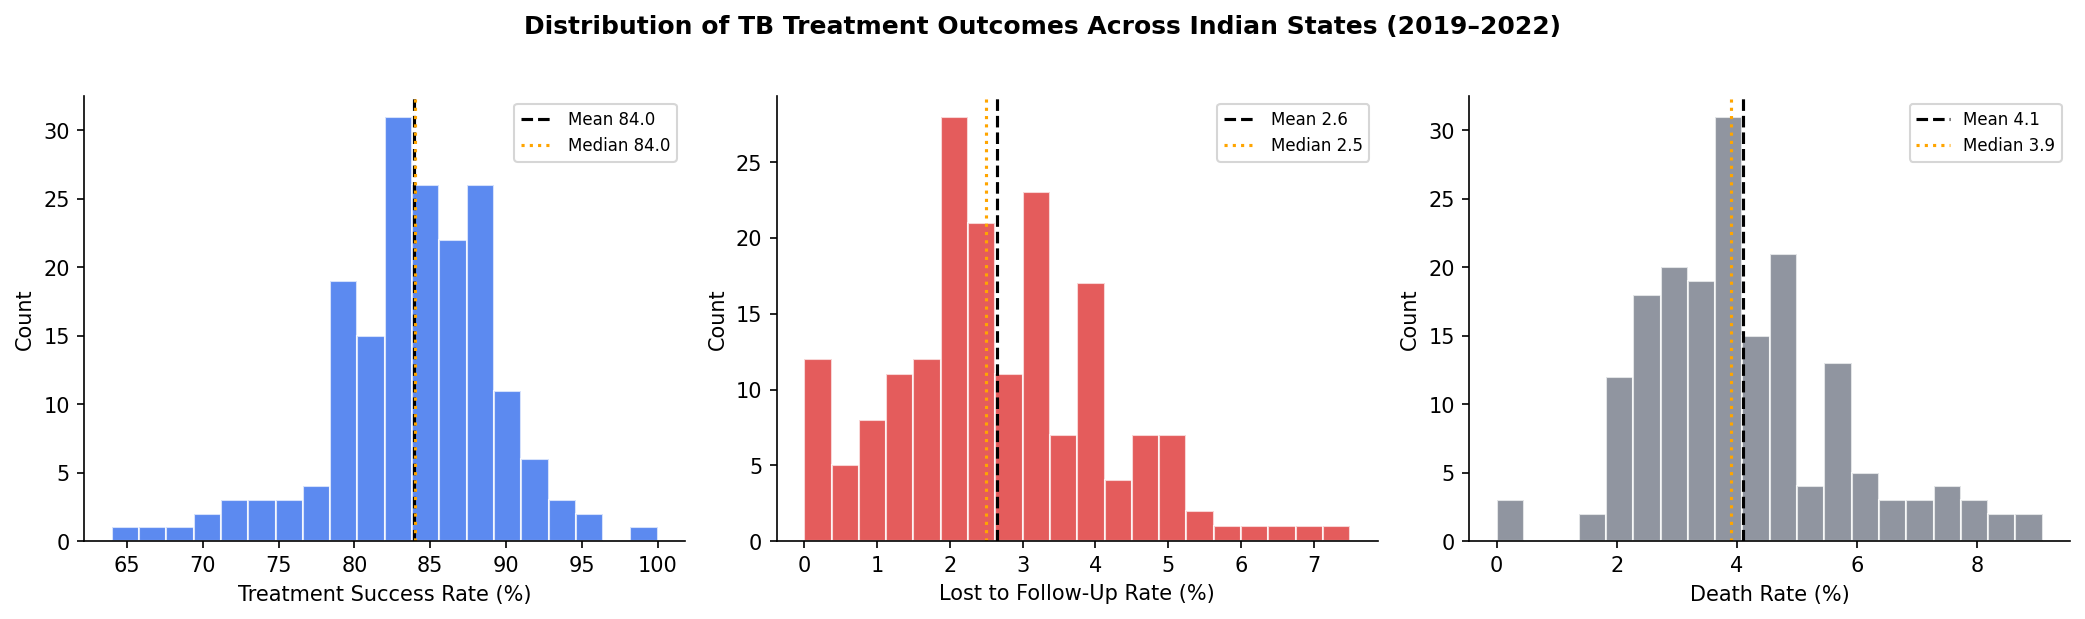

Saved 01_outcome_distributions.png


In [49]:
# ── EDA BLOCK 1: outcome distributions ───────────────────────────────────────
# What does the TB pipeline look like across states?

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Distribution of TB Treatment Outcomes Across Indian States (2019–2022)",
             fontsize=12, fontweight="bold", y=1.02)

outcome_meta = [
    ("success_rate",  "Treatment Success Rate (%)", BLUE),
    ("ltfu_rate",     "Lost to Follow-Up Rate (%)",  RED),
    ("death_rate",    "Death Rate (%)",               GREY),
]

for ax, (col, label, color) in zip(axes, outcome_meta):
    data = panel_full[col].dropna()
    ax.hist(data, bins=20, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(data.mean(),   color="black",  lw=1.5, linestyle="--", label=f"Mean {data.mean():.1f}")
    ax.axvline(data.median(), color="orange", lw=1.5, linestyle=":",  label=f"Median {data.median():.1f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_outcome_distributions.png", bbox_inches="tight")
plt.show()
print("Saved 01_outcome_distributions.png")

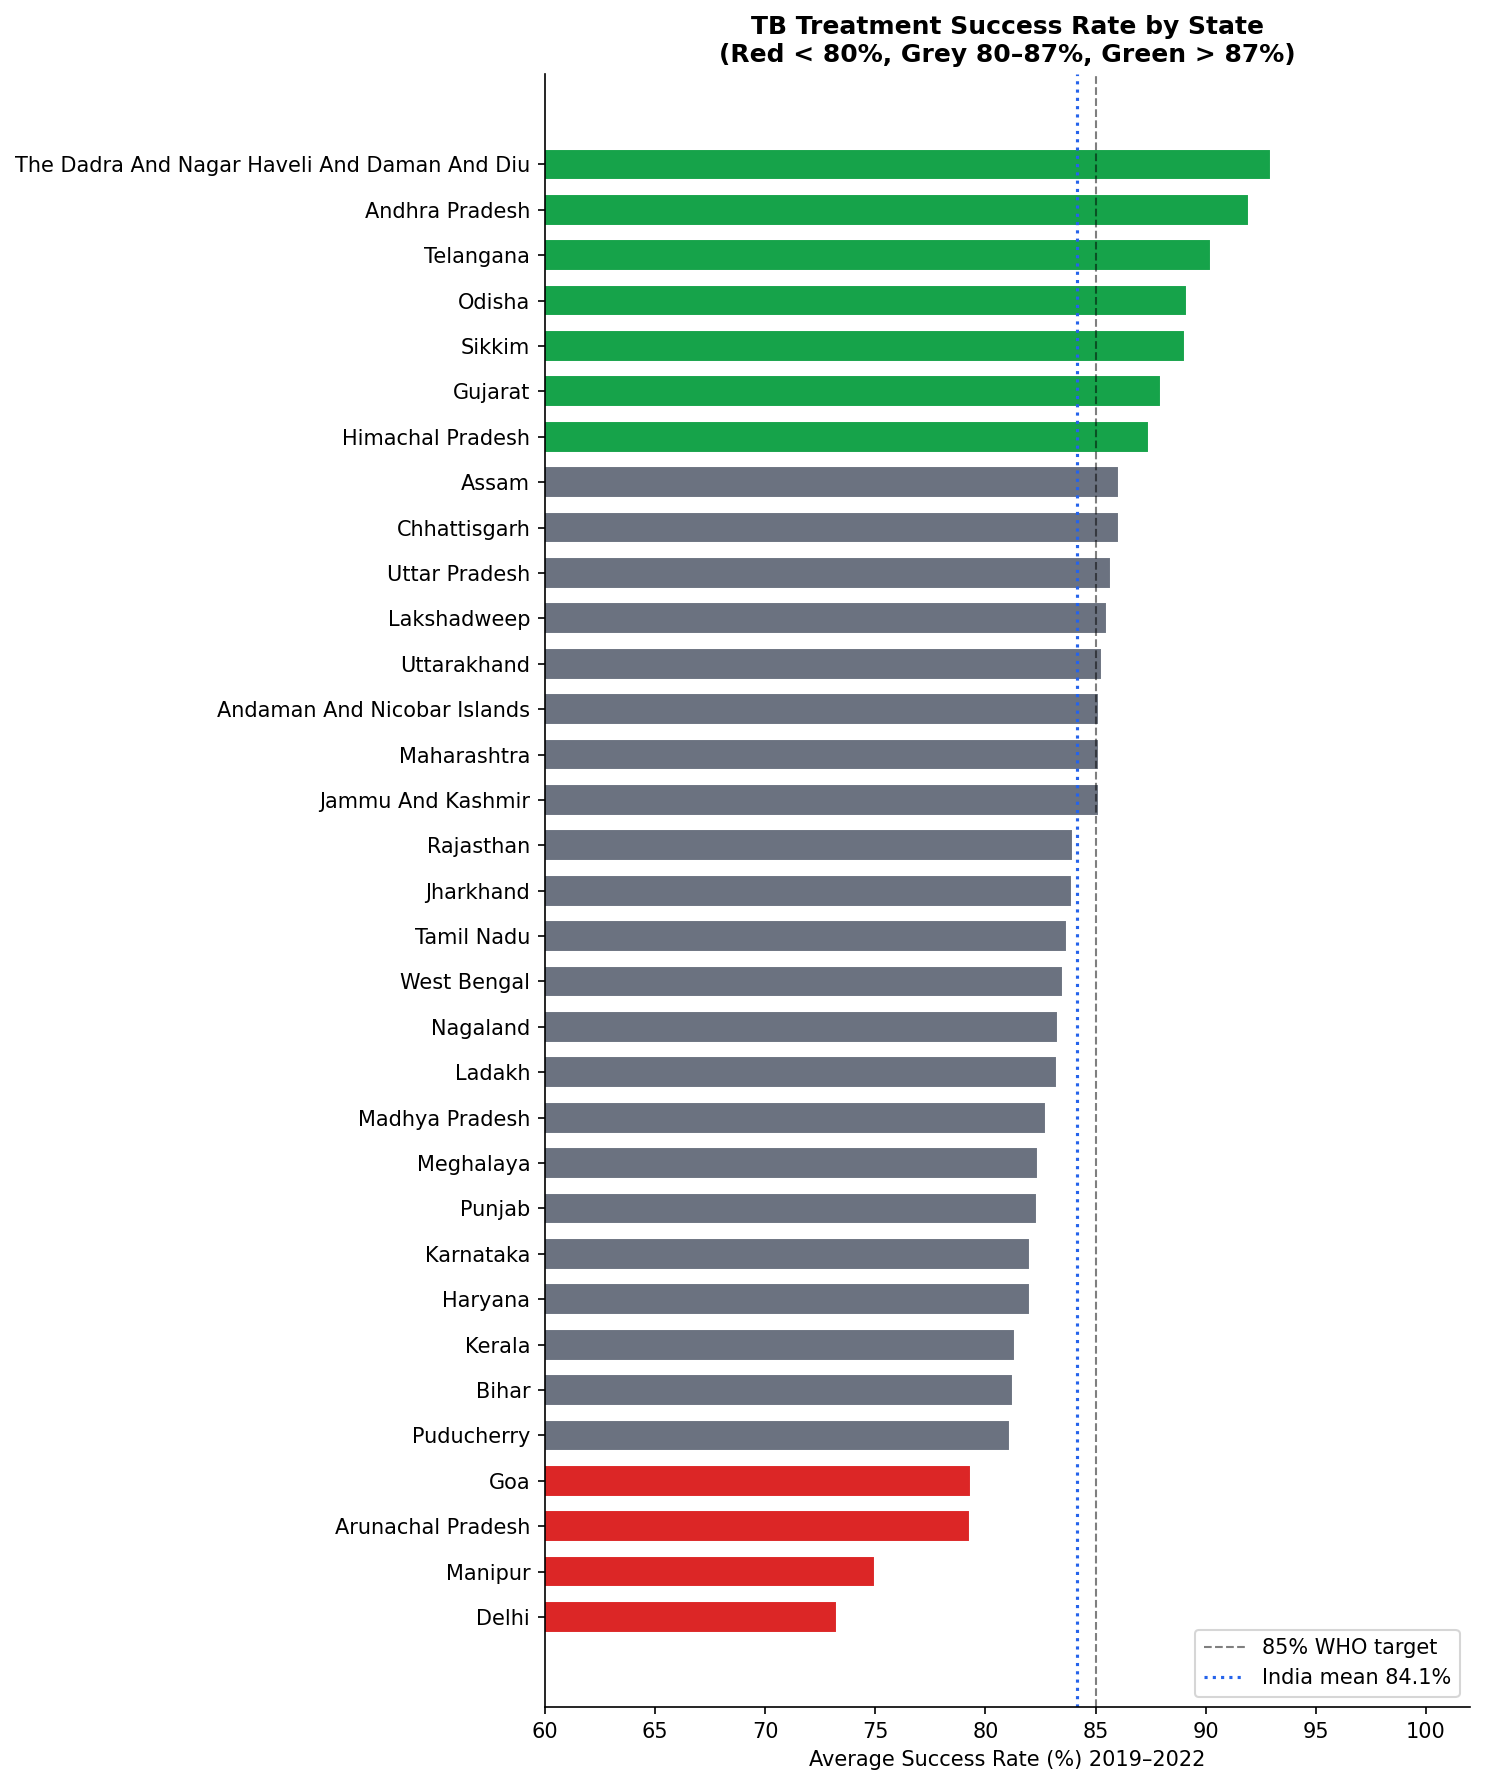

Saved 02_state_success_ranking.png


In [42]:
# ── EDA BLOCK 2: state-level success rate ranking ────────────────────────────
# Which states perform best/worst? Name them explicitly.

state_avg = (
    spec1.groupby("StateName")[["success_rate", "ltfu_rate"]]
         .mean()
         .sort_values("success_rate")
         .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 12))
colors = [RED if x < 80 else (GREY if x < 87 else GREEN) 
          for x in state_avg["success_rate"]]

bars = ax.barh(state_avg["StateName"], state_avg["success_rate"], 
               color=colors, edgecolor="white", height=0.7)
ax.axvline(85, color="black", lw=1, linestyle="--", alpha=0.5, label="85% WHO target")
ax.axvline(state_avg["success_rate"].mean(), color=BLUE, lw=1.5, 
           linestyle=":", label=f"India mean {state_avg['success_rate'].mean():.1f}%")
ax.set_xlabel("Average Success Rate (%) 2019–2022")
ax.set_title("TB Treatment Success Rate by State\n(Red < 80%, Grey 80–87%, Green > 87%)",
             fontweight="bold")
ax.legend()
ax.set_xlim(60, 102)

plt.tight_layout()
plt.savefig(FIG_DIR / "02_state_success_ranking.png", bbox_inches="tight")
plt.show()
print("Saved 02_state_success_ranking.png")

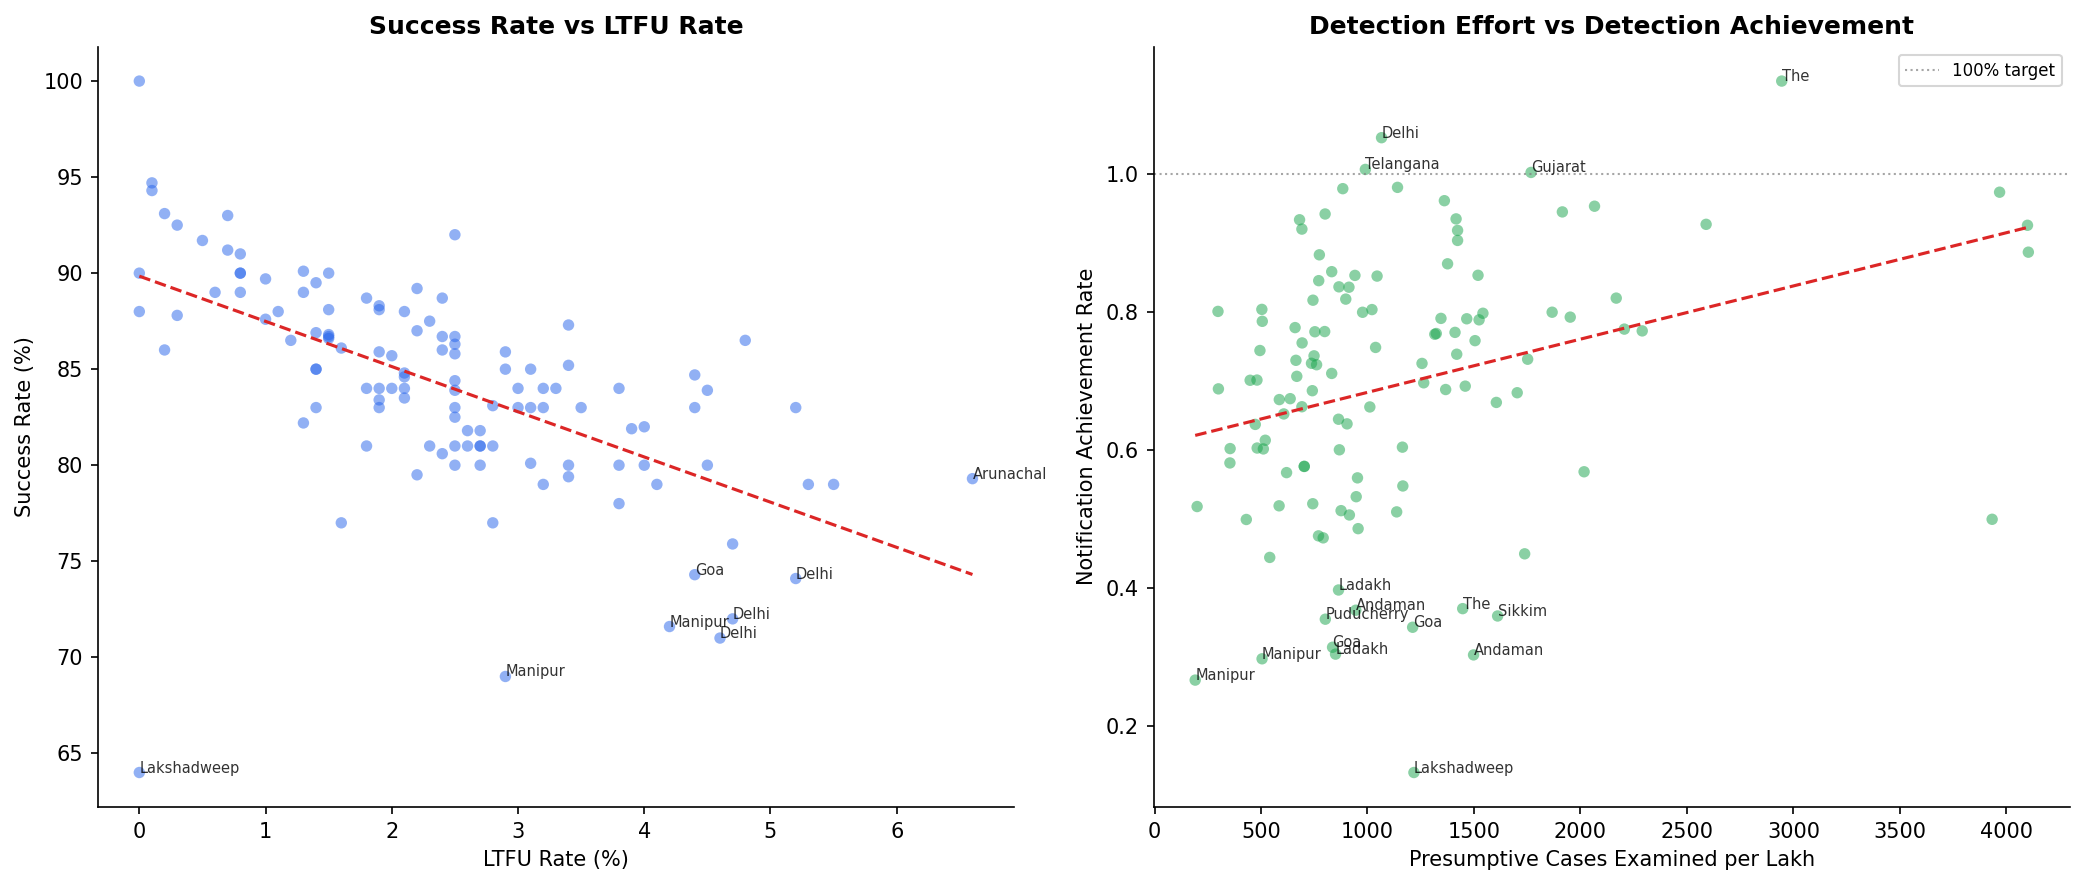

Saved 03_pipeline_decomposition.png


In [43]:
# ── EDA BLOCK 3: pipeline decomposition ──────────────────────────────────────
# Detection vs Retention failure — are they the same states?

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: success rate vs LTFU — are they inversely correlated?
ax = axes[0]
ax.scatter(spec1["ltfu_rate"], spec1["success_rate"],
           alpha=0.5, color=BLUE, s=30, edgecolors="none")
# label notable outliers
for _, row in spec1.iterrows():
    if row["success_rate"] < 75 or row["ltfu_rate"] > 6:
        ax.annotate(row["StateName"].split()[0], 
                    (row["ltfu_rate"], row["success_rate"]),
                    fontsize=7, alpha=0.8)
m, b = np.polyfit(spec1["ltfu_rate"].dropna(), 
                  spec1.loc[spec1["ltfu_rate"].notna(), "success_rate"], 1)
x_line = np.linspace(spec1["ltfu_rate"].min(), spec1["ltfu_rate"].max(), 100)
ax.plot(x_line, m * x_line + b, color=RED, lw=1.5, linestyle="--")
ax.set_xlabel("LTFU Rate (%)")
ax.set_ylabel("Success Rate (%)")
ax.set_title("Success Rate vs LTFU Rate", fontweight="bold")

# Right: presumptive exam rate vs notification achievement
# Does detection effort translate to detection outcomes?
ax = axes[1]
merged = spec3.dropna(subset=["presumptive_examination_rate", "notification_achievement_rate"])
ax.scatter(merged["presumptive_examination_rate"],
           merged["notification_achievement_rate"],
           alpha=0.5, color=GREEN, s=30, edgecolors="none")
for _, row in merged.iterrows():
    if row["notification_achievement_rate"] > 1.0 or row["notification_achievement_rate"] < 0.4:
        ax.annotate(row["StateName"].split()[0],
                    (row["presumptive_examination_rate"], row["notification_achievement_rate"]),
                    fontsize=7, alpha=0.8)
m, b = np.polyfit(merged["presumptive_examination_rate"],
                  merged["notification_achievement_rate"], 1)
x_line = np.linspace(merged["presumptive_examination_rate"].min(),
                     merged["presumptive_examination_rate"].max(), 100)
ax.plot(x_line, m * x_line + b, color=RED, lw=1.5, linestyle="--")
ax.axhline(1.0, color="grey", lw=1, linestyle=":", alpha=0.7, label="100% target")
ax.set_xlabel("Presumptive Cases Examined per Lakh")
ax.set_ylabel("Notification Achievement Rate")
ax.set_title("Detection Effort vs Detection Achievement", fontweight="bold")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "03_pipeline_decomposition.png", bbox_inches="tight")
plt.show()
print("Saved 03_pipeline_decomposition.png")

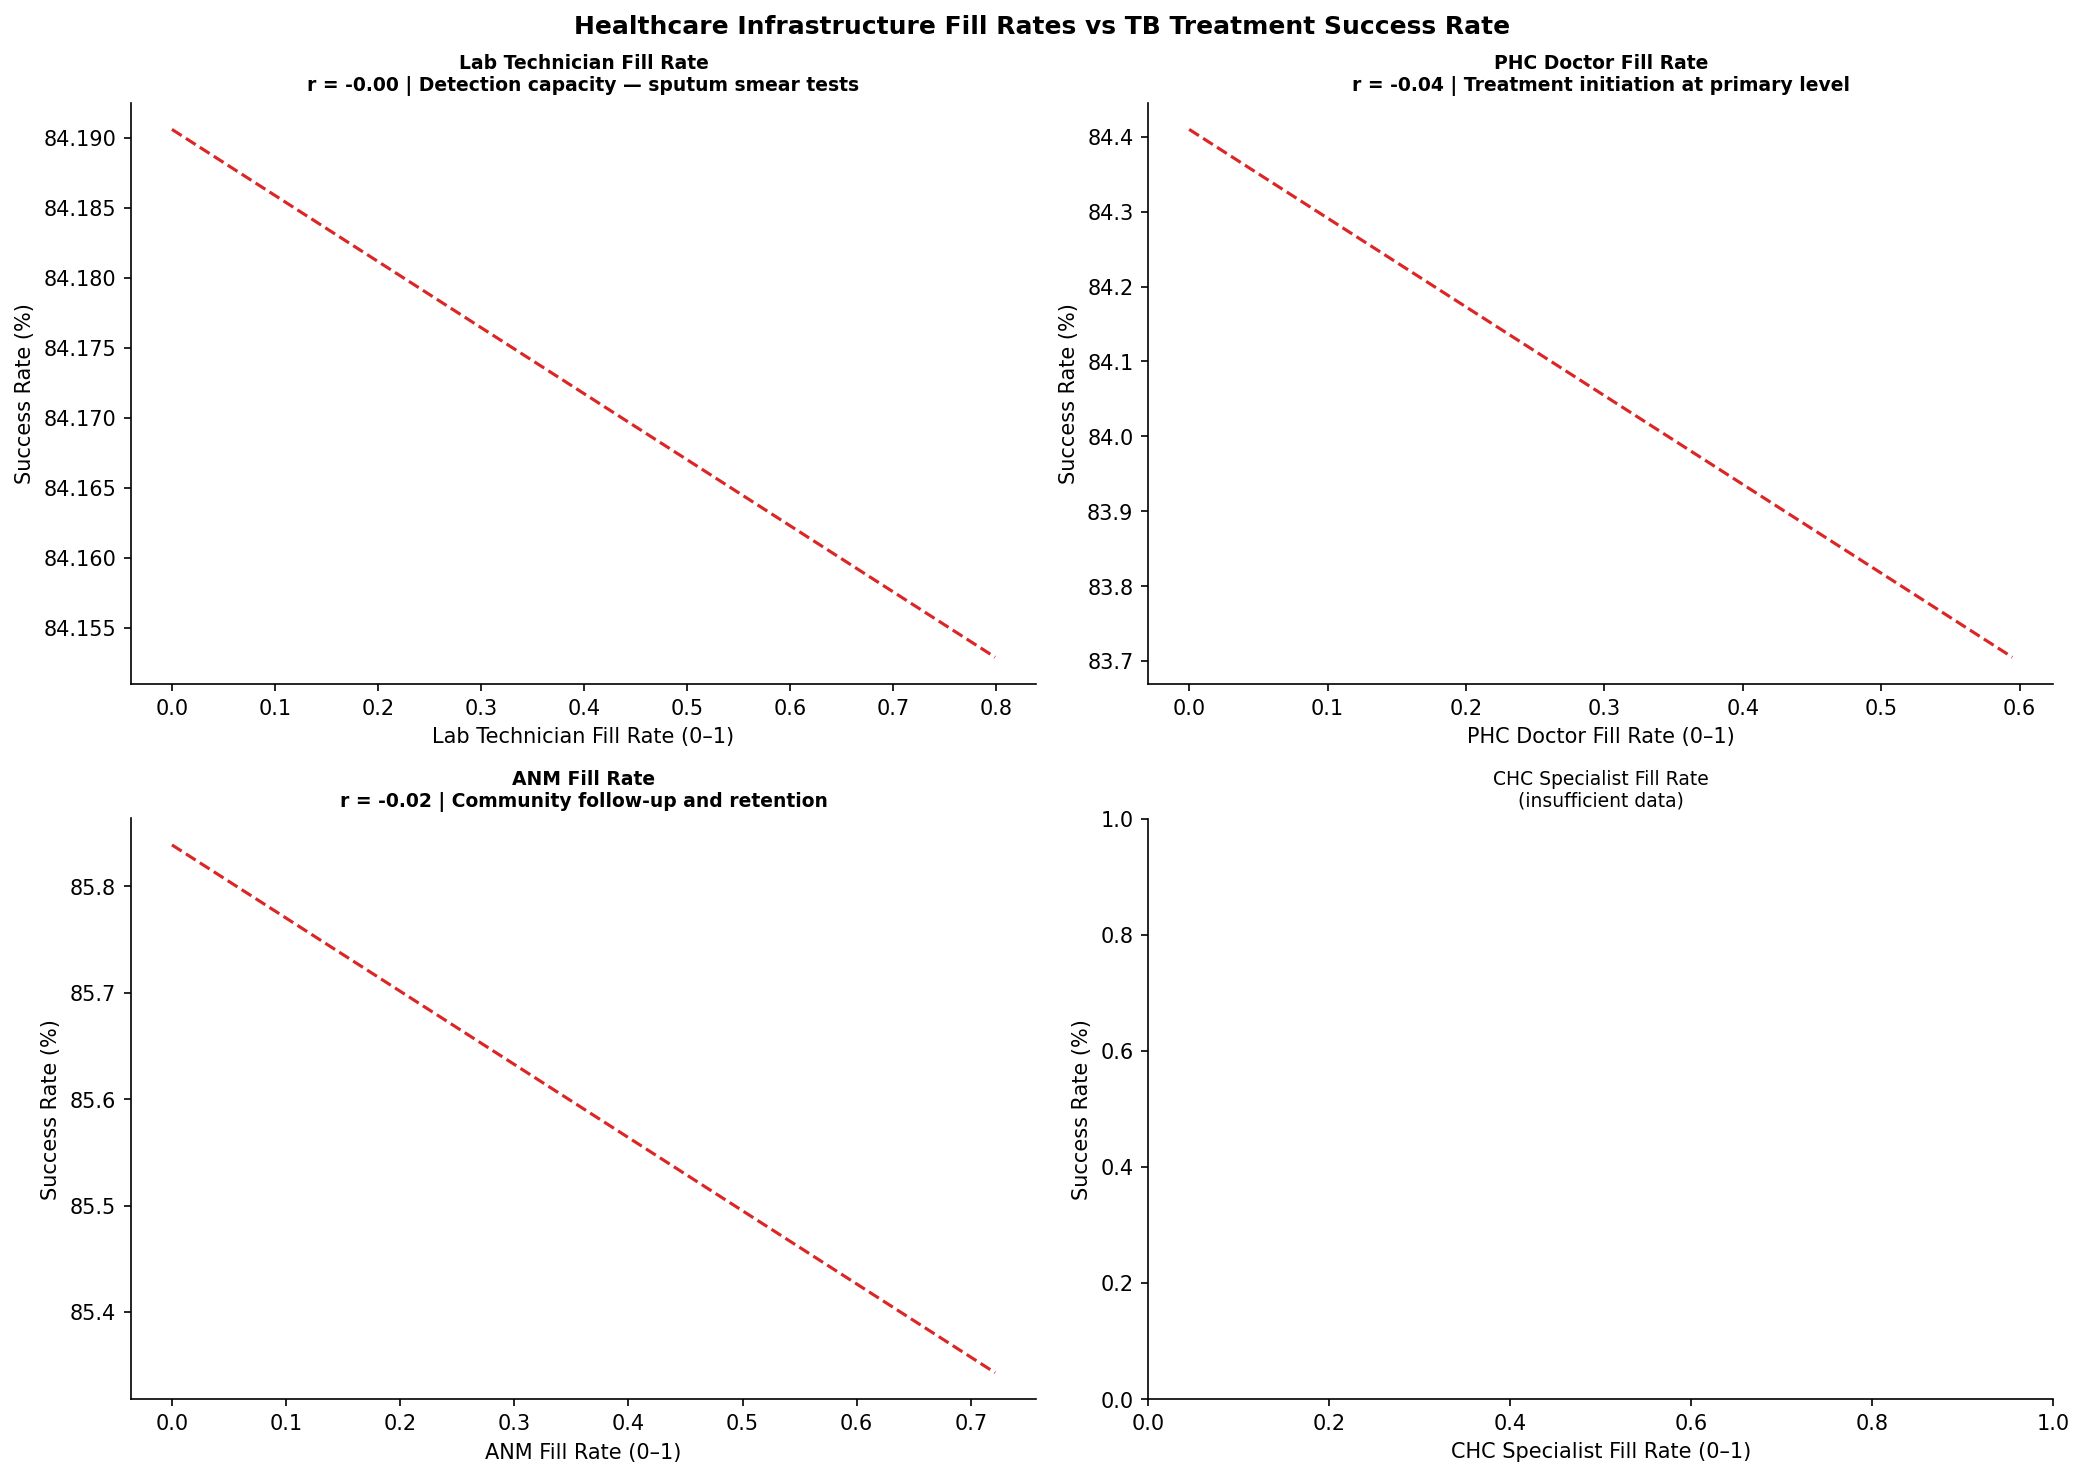

Saved 04_infrastructure_vs_outcomes.png


In [52]:
# ── EDA BLOCK 4: infrastructure → outcomes ───────────────────────────────────
# The core supply-side hypothesis: fill rates vs success rate

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Healthcare Infrastructure Fill Rates vs TB Treatment Success Rate",
             fontweight="bold", fontsize=12)

infra_vars = [
    ("lab_tech_fill_rate",       "Lab Technician Fill Rate",    
     "Detection capacity — sputum smear tests"),
    ("phc_doctor_fill_rate",     "PHC Doctor Fill Rate",        
     "Treatment initiation at primary level"),
    ("anm_fill_rate",            "ANM Fill Rate",               
     "Community follow-up and retention"),
    ("chc_specialist_fill_rate", "CHC Specialist Fill Rate",    
     "Complex case management"),
]

for ax, (var, label, subtitle) in zip(axes.flat, infra_vars):

    # SAFE column selection — no KeyError
    if var in spec1.columns:
        data = spec1[["success_rate", var, "StateName"]].dropna()
    else:
        data = pd.DataFrame()

    # fallback to spec2 if needed
    if len(data) < 10:
        if var in spec2.columns:
            data = spec2[["success_rate", var, "StateName"]].dropna()

    if len(data) >= 5:
        m, b = np.polyfit(data[var], data["success_rate"], 1)
        x_line = np.linspace(data[var].min(), data[var].max(), 100)
        ax.plot(x_line, m * x_line + b, color=RED, lw=1.5, linestyle="--")
        corr = data[[var, "success_rate"]].corr().iloc[0, 1]
        ax.set_title(f"{label}\nr = {corr:.2f} | {subtitle}", fontweight="bold", fontsize=9)
    else:
        ax.set_title(f"{label}\n(insufficient data)", fontsize=9)

    ax.set_xlabel(f"{label} (0–1)")
    ax.set_ylabel("Success Rate (%)")

plt.tight_layout()
plt.savefig(FIG_DIR / "04_infrastructure_vs_outcomes.png", bbox_inches="tight")
plt.show()
print("Saved 04_infrastructure_vs_outcomes.png")

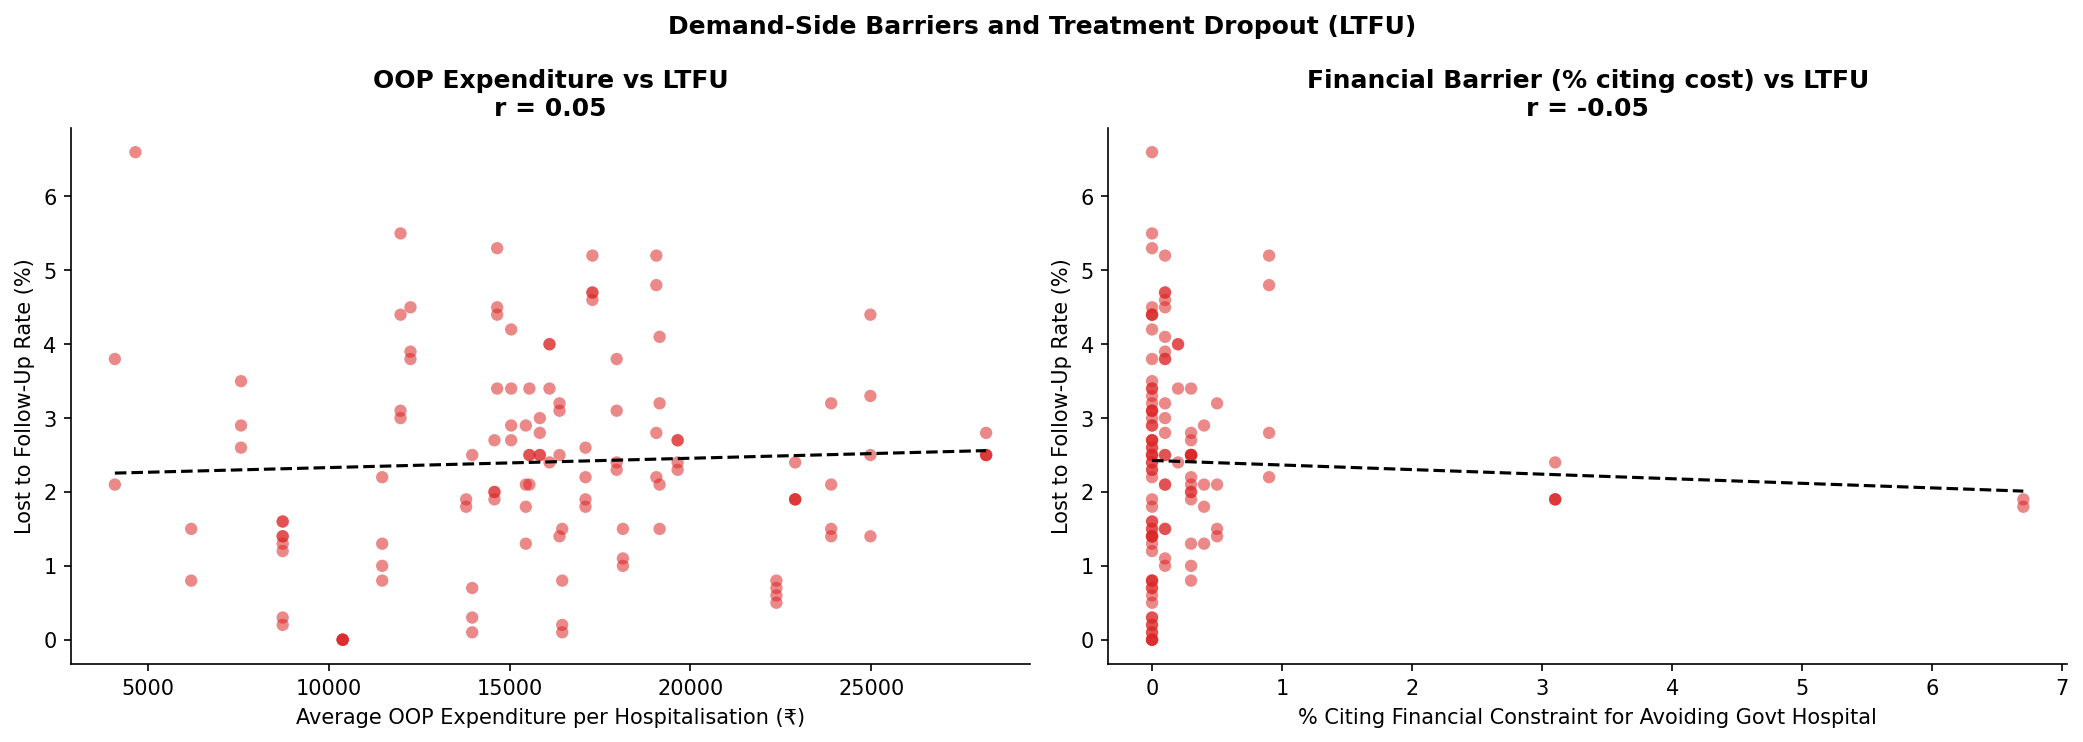

Saved 05_demand_side_ltfu.png


In [45]:
# ── EDA BLOCK 5: demand side — OOP and barriers ───────────────────────────────
# Does financial burden predict dropout (LTFU)?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Demand-Side Barriers and Treatment Dropout (LTFU)",
             fontweight="bold", fontsize=12)

# Left: OOP vs LTFU
ax = axes[0]
data = spec1[["ltfu_rate", "oop_per_hospitalisation", "StateName"]].dropna()
ax.scatter(data["oop_per_hospitalisation"], data["ltfu_rate"],
           alpha=0.55, color=RED, s=35, edgecolors="none")
m, b = np.polyfit(data["oop_per_hospitalisation"], data["ltfu_rate"], 1)
x_line = np.linspace(data["oop_per_hospitalisation"].min(),
                     data["oop_per_hospitalisation"].max(), 100)
ax.plot(x_line, m * x_line + b, color="black", lw=1.5, linestyle="--")
corr = data[["oop_per_hospitalisation", "ltfu_rate"]].corr().iloc[0, 1]
ax.set_xlabel("Average OOP Expenditure per Hospitalisation (₹)")
ax.set_ylabel("Lost to Follow-Up Rate (%)")
ax.set_title(f"OOP Expenditure vs LTFU\nr = {corr:.2f}", fontweight="bold")

# Right: financial barrier reason vs LTFU
ax = axes[1]
data2 = spec1.merge(
    panel_full[["StateCode", "barrier_financial_pct"]].drop_duplicates(),
    on="StateCode", how="left"
).dropna(subset=["ltfu_rate", "barrier_financial_pct"])

if len(data2) > 10:
    ax.scatter(data2["barrier_financial_pct"], data2["ltfu_rate"],
               alpha=0.55, color=RED, s=35, edgecolors="none")
    m, b = np.polyfit(data2["barrier_financial_pct"], data2["ltfu_rate"], 1)
    x_line = np.linspace(data2["barrier_financial_pct"].min(),
                         data2["barrier_financial_pct"].max(), 100)
    ax.plot(x_line, m * x_line + b, color="black", lw=1.5, linestyle="--")
    corr2 = data2[["barrier_financial_pct", "ltfu_rate"]].corr().iloc[0, 1]
    ax.set_title(f"Financial Barrier (% citing cost) vs LTFU\nr = {corr2:.2f}",
                 fontweight="bold")
else:
    ax.set_title("Financial Barrier vs LTFU\n(insufficient overlap)")

ax.set_xlabel("% Citing Financial Constraint for Avoiding Govt Hospital")
ax.set_ylabel("Lost to Follow-Up Rate (%)")

plt.tight_layout()
plt.savefig(FIG_DIR / "05_demand_side_ltfu.png", bbox_inches="tight")
plt.show()
print("Saved 05_demand_side_ltfu.png")

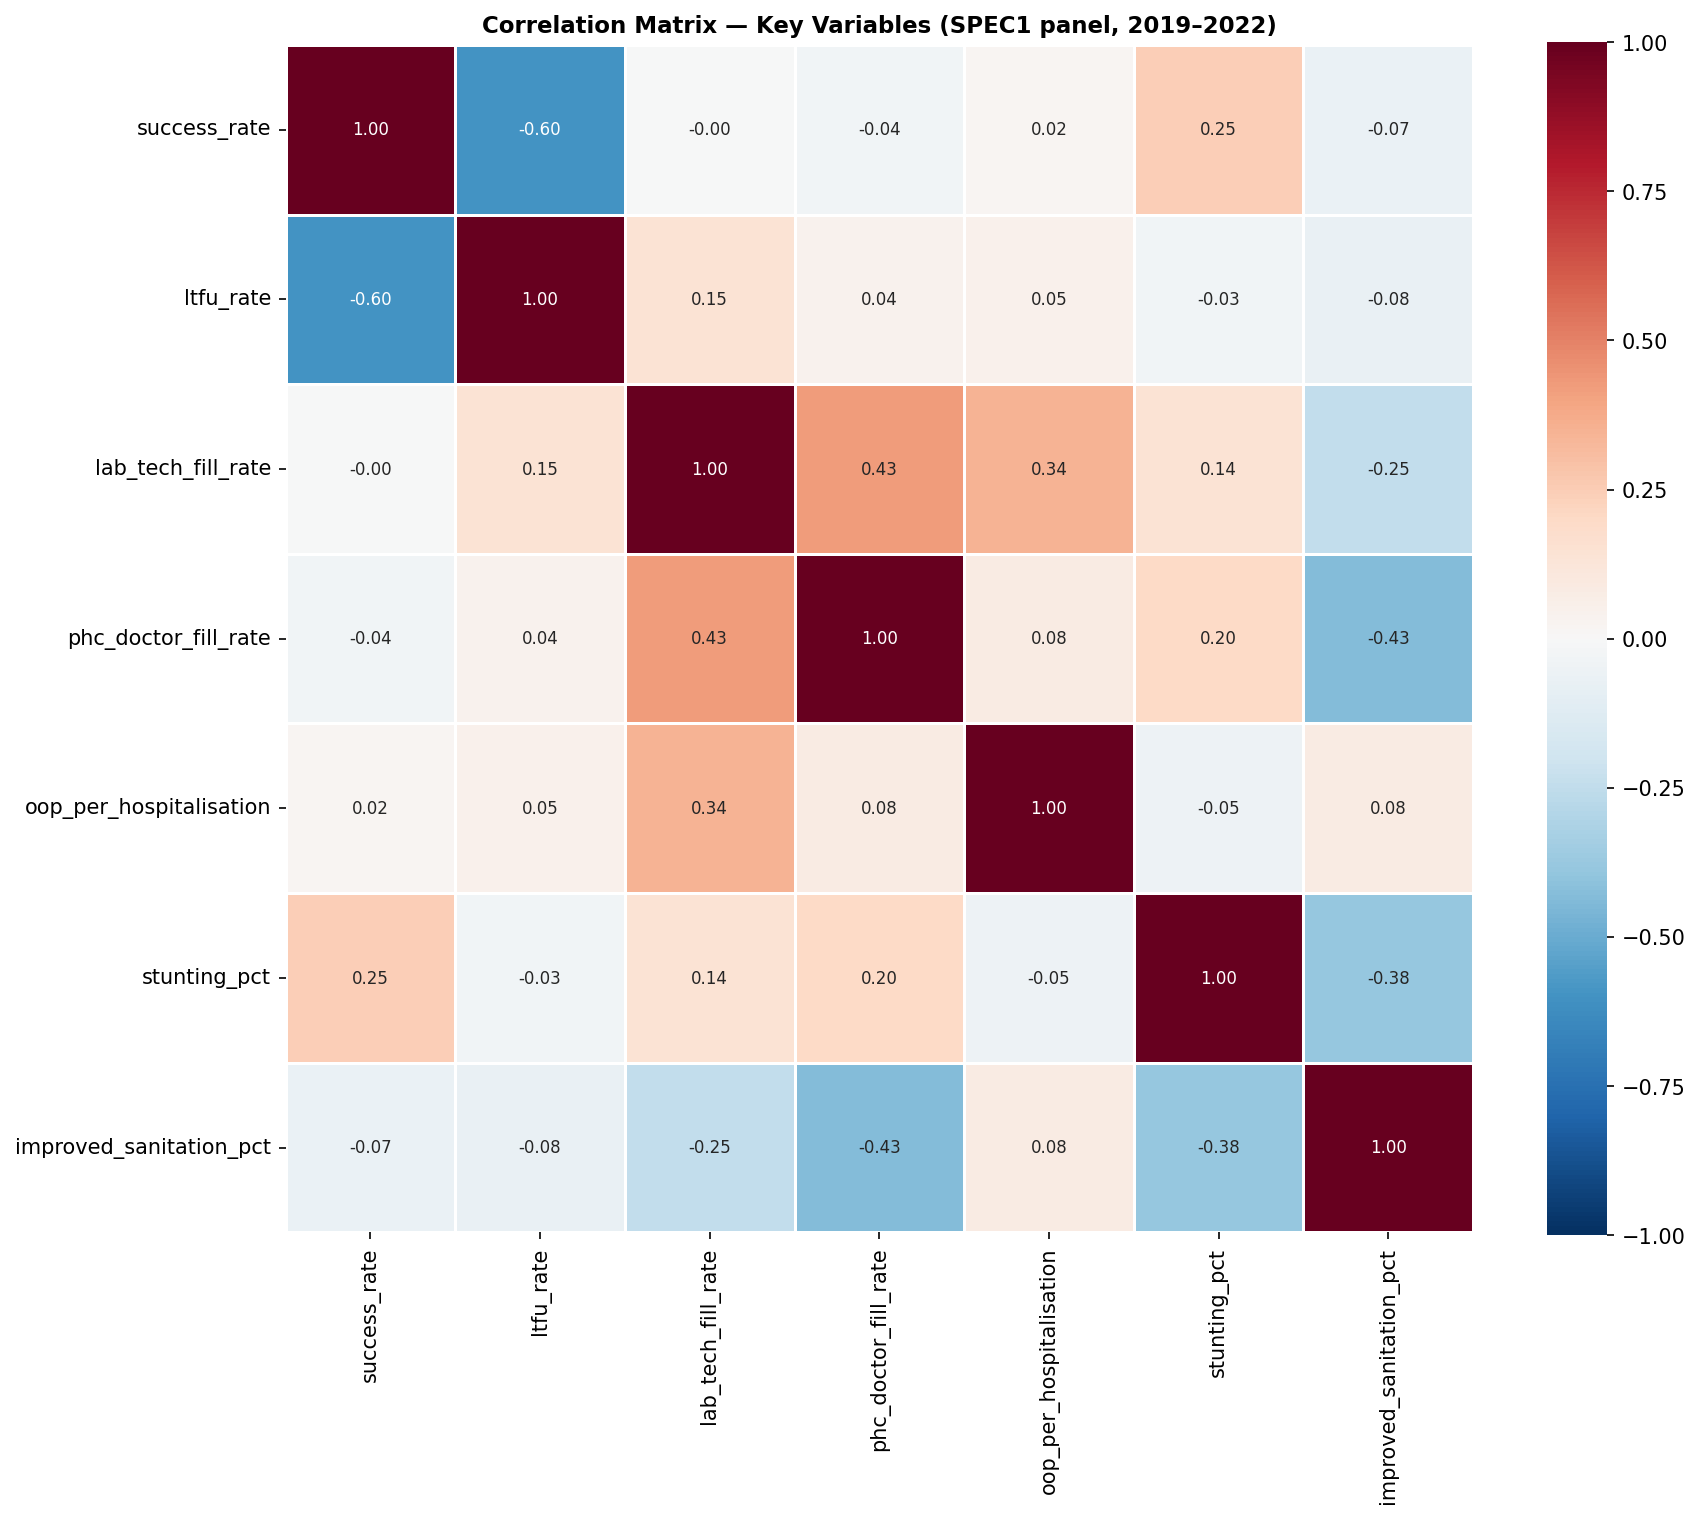

Saved 06_correlation_matrix.png


In [46]:
# ── EDA BLOCK 6: correlation matrix — key variables only ─────────────────────

corr_vars = [
    "success_rate", "ltfu_rate", "death_rate",
    "lab_tech_fill_rate", "phc_doctor_fill_rate", "anm_fill_rate",
    "notification_achievement_rate", "presumptive_examination_rate",
    "oop_per_hospitalisation", "stunting_pct", "improved_sanitation_pct",
    "health_insurance_coverage_pct",
]
existing = [c for c in corr_vars if c in spec1.columns]
corr_data = spec1[existing].dropna(how="all")
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    annot_kws={"size": 8},
    ax=ax
)
ax.set_title("Correlation Matrix — Key Variables (SPEC1 panel, 2019–2022)",
             fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_correlation_matrix.png", bbox_inches="tight")
plt.show()
print("Saved 06_correlation_matrix.png")

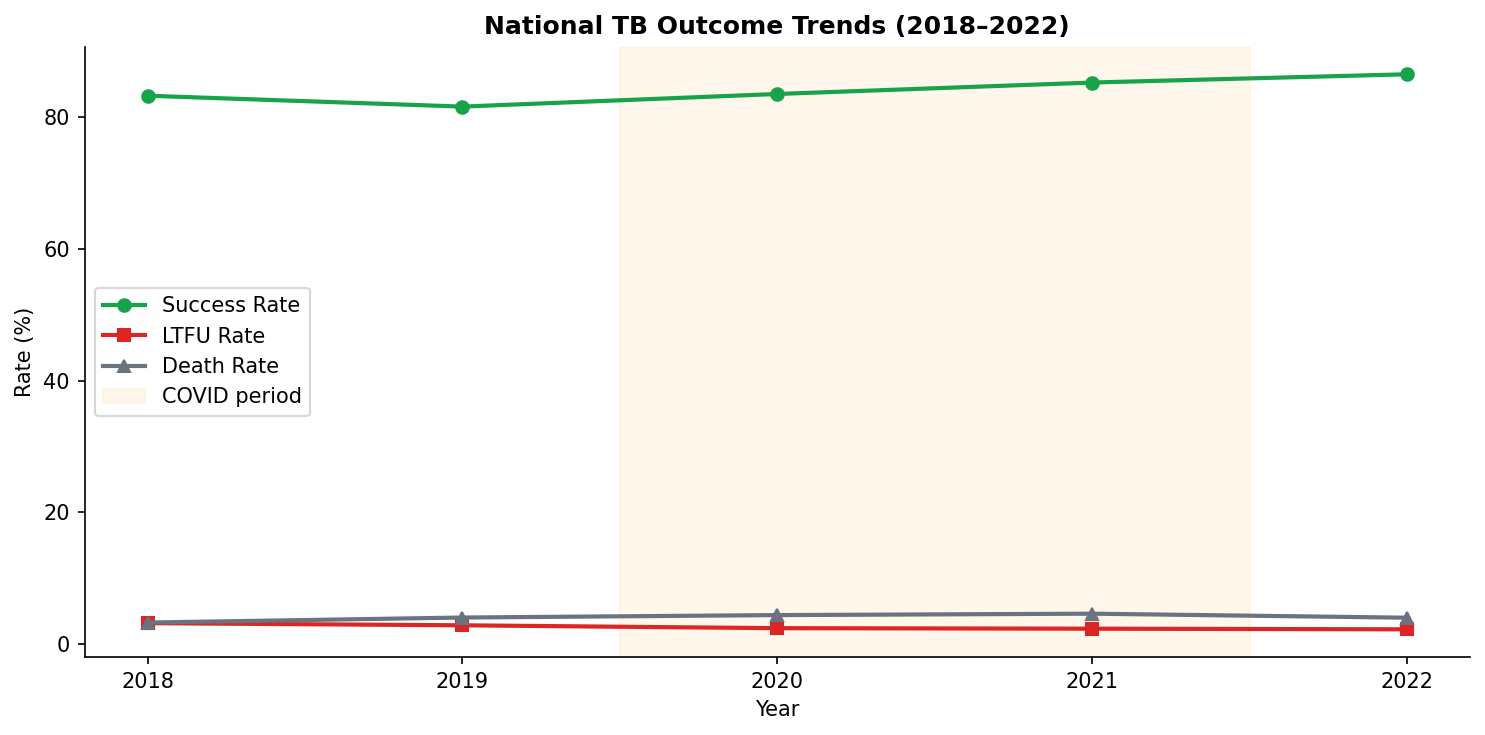

Saved 07_time_trends.png


In [47]:
# ── EDA BLOCK 7: time trends ──────────────────────────────────────────────────
# Has India improved? Did COVID (2020) disrupt outcomes?

yearly = (
    panel_full.groupby("Year")[["success_rate", "ltfu_rate", "death_rate"]]
              .mean()
              .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly["Year"], yearly["success_rate"], 
        marker="o", color=GREEN,  lw=2, label="Success Rate")
ax.plot(yearly["Year"], yearly["ltfu_rate"],    
        marker="s", color=RED,    lw=2, label="LTFU Rate")
ax.plot(yearly["Year"], yearly["death_rate"],   
        marker="^", color=GREY,   lw=2, label="Death Rate")
ax.axvspan(2019.5, 2021.5, alpha=0.08, color="orange", label="COVID period")
ax.set_xlabel("Year")
ax.set_ylabel("Rate (%)")
ax.set_title("National TB Outcome Trends (2018–2022)", fontweight="bold")
ax.legend()
ax.set_xticks([2018, 2019, 2020, 2021, 2022])

plt.tight_layout()
plt.savefig(FIG_DIR / "07_time_trends.png", bbox_inches="tight")
plt.show()
print("Saved 07_time_trends.png")

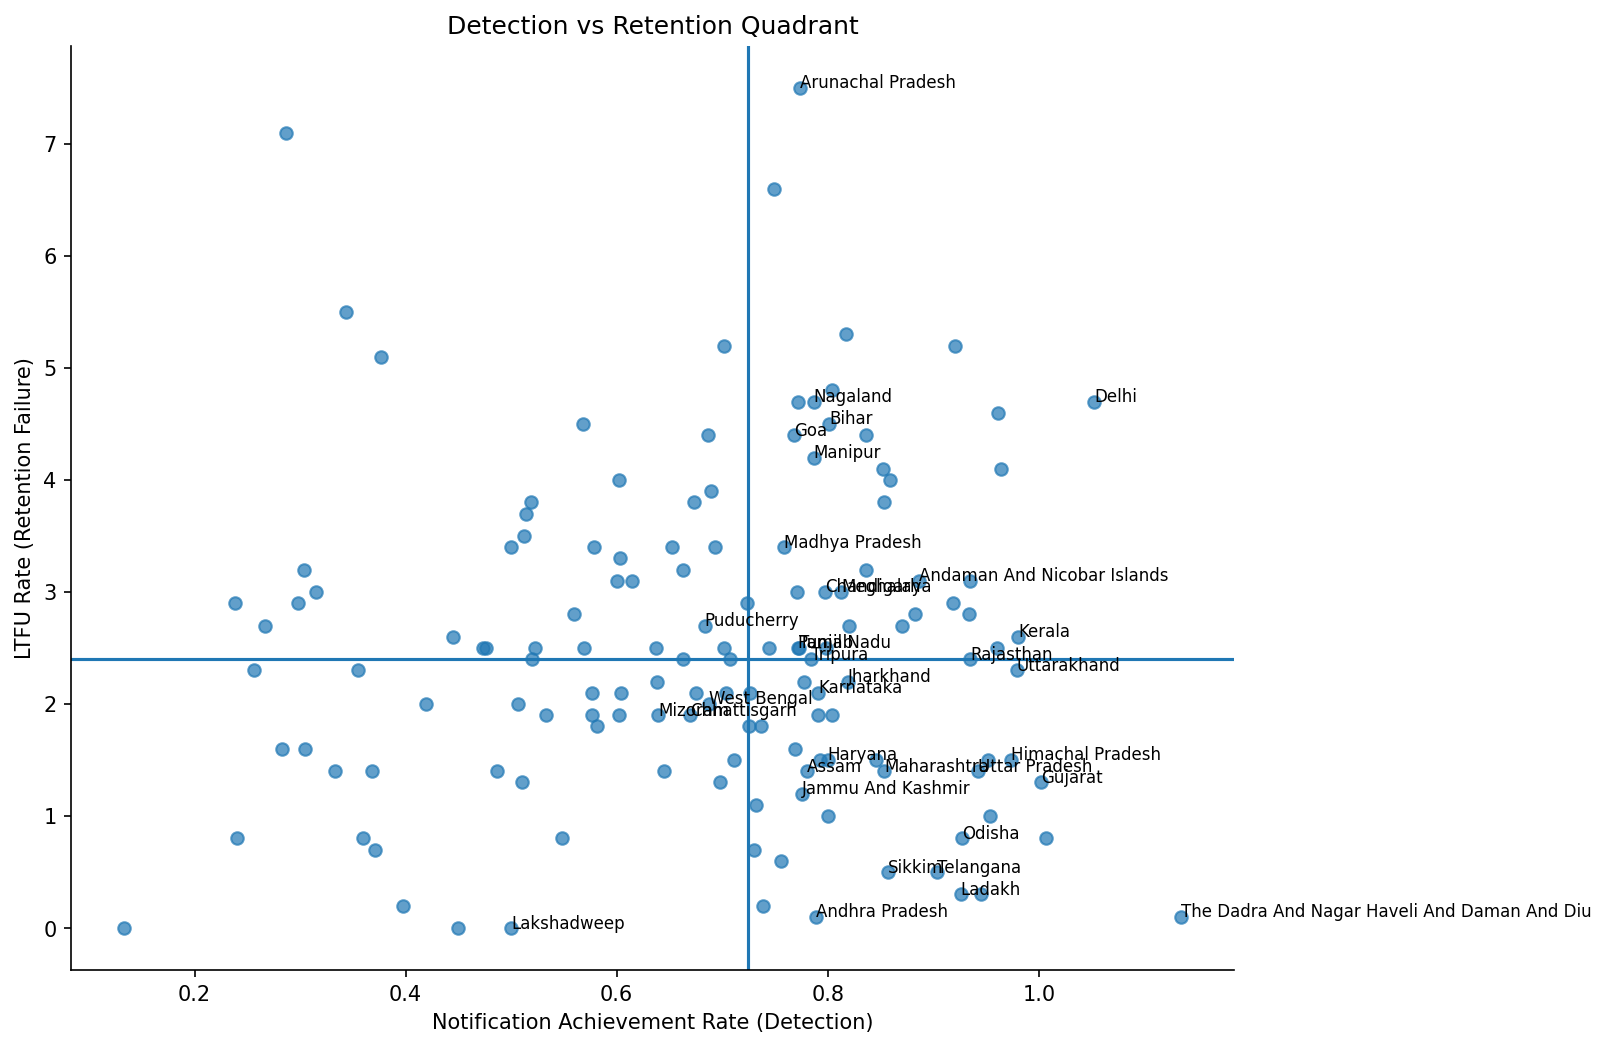

In [50]:
import matplotlib.pyplot as plt

df_q = panel_reg.copy()

x = df_q["notification_achievement_rate"]
y = df_q["ltfu_rate"]

x_med = x.median()
y_med = y.median()

plt.figure(figsize=(10, 8))
plt.scatter(x, y, alpha=0.7)

# quadrant lines
plt.axvline(x_med)
plt.axhline(y_med)

# label states (use last available year per state to avoid clutter)
latest = df_q.sort_values("Year").groupby("StateName").tail(1)
for _, row in latest.iterrows():
    plt.text(row["notification_achievement_rate"], row["ltfu_rate"], row["StateName"], fontsize=8)

plt.xlabel("Notification Achievement Rate (Detection)")
plt.ylabel("LTFU Rate (Retention Failure)")
plt.title("Detection vs Retention Quadrant")
plt.show()

Regression

In [54]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.6 MB 9.3 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.6 MB 21.2 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 21.0 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ---------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
# ── PHASE 3: REGRESSION ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

CLEAN_DIR = Path("data/cleaned")
FIG_DIR   = Path("figures")

spec1 = pd.read_csv(CLEAN_DIR / "spec1_parsimonious.csv")
spec3 = pd.read_csv(CLEAN_DIR / "spec3_detection.csv")

BLUE  = "#2563EB"
RED   = "#DC2626"
GREEN = "#16A34A"

In [56]:
# ── MODEL A: Retention (primary) ─────────────────────────────────────────────
# Does supply-side infrastructure predict treatment success?
# Using SPEC1: N=120, 33 states, 2019-2022

formula_A = ("success_rate ~ lab_tech_fill_rate + phc_doctor_fill_rate "
             "+ stunting_pct + improved_sanitation_pct + oop_per_hospitalisation")

model_A = smf.ols(formula_A, data=spec1).fit(
    cov_type='cluster', 
    cov_kwds={'groups': spec1['StateCode']}
)
print("=" * 60)
print("MODEL A — Treatment Success Rate (SPEC1, N=120)")
print("=" * 60)
print(model_A.summary2())

MODEL A — Treatment Success Rate (SPEC1, N=120)
                    Results: Ordinary least squares
Model:                 OLS                Adj. R-squared:       0.029   
Dependent Variable:    success_rate       AIC:                  746.6937
Date:                  2026-04-26 20:39   BIC:                  763.4186
No. Observations:      120                Log-Likelihood:       -367.35 
Df Model:              5                  F-statistic:          0.8708  
Df Residuals:          114                Prob (F-statistic):   0.512   
R-squared:             0.070              Scale:                28.103  
------------------------------------------------------------------------
                         Coef.  Std.Err.    z    P>|z|   [0.025   0.975]
------------------------------------------------------------------------
Intercept               76.8457  10.2951  7.4643 0.0000  56.6677 97.0238
lab_tech_fill_rate      -0.6492   3.3566 -0.1934 0.8466  -7.2279  5.9295
phc_doctor_fill_rate    

In [57]:
# ── MODEL B: LTFU (retention failure) ────────────────────────────────────────
formula_B = ("ltfu_rate ~ lab_tech_fill_rate + phc_doctor_fill_rate "
             "+ stunting_pct + improved_sanitation_pct + oop_per_hospitalisation")

model_B = smf.ols(formula_B, data=spec1).fit(
    cov_type='cluster',
    cov_kwds={'groups': spec1['StateCode']}
)
print("=" * 60)
print("MODEL B — LTFU Rate (SPEC1, N=120)")
print("=" * 60)
print(model_B.summary2())

MODEL B — LTFU Rate (SPEC1, N=120)
                   Results: Ordinary least squares
Model:                 OLS               Adj. R-squared:      -0.013  
Dependent Variable:    ltfu_rate         AIC:                 423.8886
Date:                  2026-04-26 20:39  BIC:                 440.6136
No. Observations:      120               Log-Likelihood:      -205.94 
Df Model:              5                 F-statistic:         0.3892  
Df Residuals:          114               Prob (F-statistic):  0.853   
R-squared:             0.030             Scale:               1.9076  
----------------------------------------------------------------------
                         Coef.  Std.Err.    z    P>|z|   [0.025 0.975]
----------------------------------------------------------------------
Intercept                3.7219   2.5827  1.4411 0.1496 -1.3401 8.7838
lab_tech_fill_rate       1.1008   1.0346  1.0640 0.2873 -0.9270 3.1287
phc_doctor_fill_rate    -0.3506   1.1439 -0.3065 0.7592 -2.592

In [58]:
# ── MODEL C: Detection ────────────────────────────────────────────────────────
formula_C = ("notification_achievement_rate ~ presumptive_examination_rate "
             "+ lab_tech_fill_rate + phc_doctor_fill_rate + stunting_pct")

model_C = smf.ols(formula_C, data=spec3).fit(
    cov_type='cluster',
    cov_kwds={'groups': spec3['StateCode']}
)
print("=" * 60)
print("MODEL C — Notification Achievement (SPEC3, N=119)")
print("=" * 60)
print(model_C.summary2())

MODEL C — Notification Achievement (SPEC3, N=119)
                       Results: Ordinary least squares
Model:              OLS                           Adj. R-squared:     0.141   
Dependent Variable: notification_achievement_rate AIC:                -67.6619
Date:               2026-04-26 20:40              BIC:                -53.7662
No. Observations:   119                           Log-Likelihood:     38.831  
Df Model:           4                             F-statistic:        7.550   
Df Residuals:       114                           Prob (F-statistic): 0.000211
R-squared:          0.170                         Scale:              0.031823
------------------------------------------------------------------------------
                                 Coef.  Std.Err.    z    P>|z|   [0.025 0.975]
------------------------------------------------------------------------------
Intercept                        0.4183   0.1230  3.4003 0.0007  0.1772 0.6595
presumptive_examination_ra

In [59]:
# ── COEFFICIENT COMPARISON CHART ─────────────────────────────────────────────
# Which predictors matter for success vs LTFU vs detection?

def extract_coef_table(model, model_name, exclude=["Intercept"]):
    df = pd.DataFrame({
        "coef":   model.params,
        "ci_low": model.conf_int()[0],
        "ci_high":model.conf_int()[1],
        "pval":   model.pvalues,
    })
    df = df[~df.index.isin(exclude)].copy()
    df["model"]     = model_name
    df["predictor"] = df.index
    df["sig"]       = df["pval"] < 0.05
    return df.reset_index(drop=True)

coef_A = extract_coef_table(model_A, "Success Rate")
coef_B = extract_coef_table(model_B, "LTFU Rate")
coef_C = extract_coef_table(model_C, "Notification Rate")
all_coefs = pd.concat([coef_A, coef_B, coef_C], ignore_index=True)

# standardise coefficients for comparison
def standardise_coefs(df, model, data, outcome):
    preds = [p for p in model.params.index if p != "Intercept"]
    for p in preds:
        if p in data.columns and outcome in data.columns:
            sd_x = data[p].std()
            sd_y = data[outcome].std()
            if sd_x > 0 and sd_y > 0:
                df.loc[df["predictor"] == p, "beta_std"] = (
                    model.params[p] * sd_x / sd_y
                )
    return df

coef_A = standardise_coefs(coef_A, model_A, spec1, "success_rate")
coef_B = standardise_coefs(coef_B, model_B, spec1, "ltfu_rate")
coef_C = standardise_coefs(coef_C, model_C, spec3, "notification_achievement_rate")
all_coefs = pd.concat([coef_A, coef_B, coef_C], ignore_index=True)

print("\nStandardised Coefficients (beta):")
print(all_coefs[["model", "predictor", "beta_std", "pval"]].to_string(index=False))


Standardised Coefficients (beta):
            model                    predictor  beta_std     pval
     Success Rate           lab_tech_fill_rate -0.022953 0.846634
     Success Rate         phc_doctor_fill_rate -0.089315 0.462103
     Success Rate                 stunting_pct  0.263009 0.078838
     Success Rate      improved_sanitation_pct -0.014544 0.930222
     Success Rate      oop_per_hospitalisation  0.053626 0.590854
        LTFU Rate           lab_tech_fill_rate  0.152598 0.287334
        LTFU Rate         phc_doctor_fill_rate -0.042680 0.759195
        LTFU Rate                 stunting_pct -0.080214 0.545557
        LTFU Rate      improved_sanitation_pct -0.087030 0.664881
        LTFU Rate      oop_per_hospitalisation  0.002153 0.988279
Notification Rate presumptive_examination_rate  0.336731 0.000467
Notification Rate           lab_tech_fill_rate  0.261737 0.015566
Notification Rate         phc_doctor_fill_rate -0.053468 0.638322
Notification Rate                 stuntin

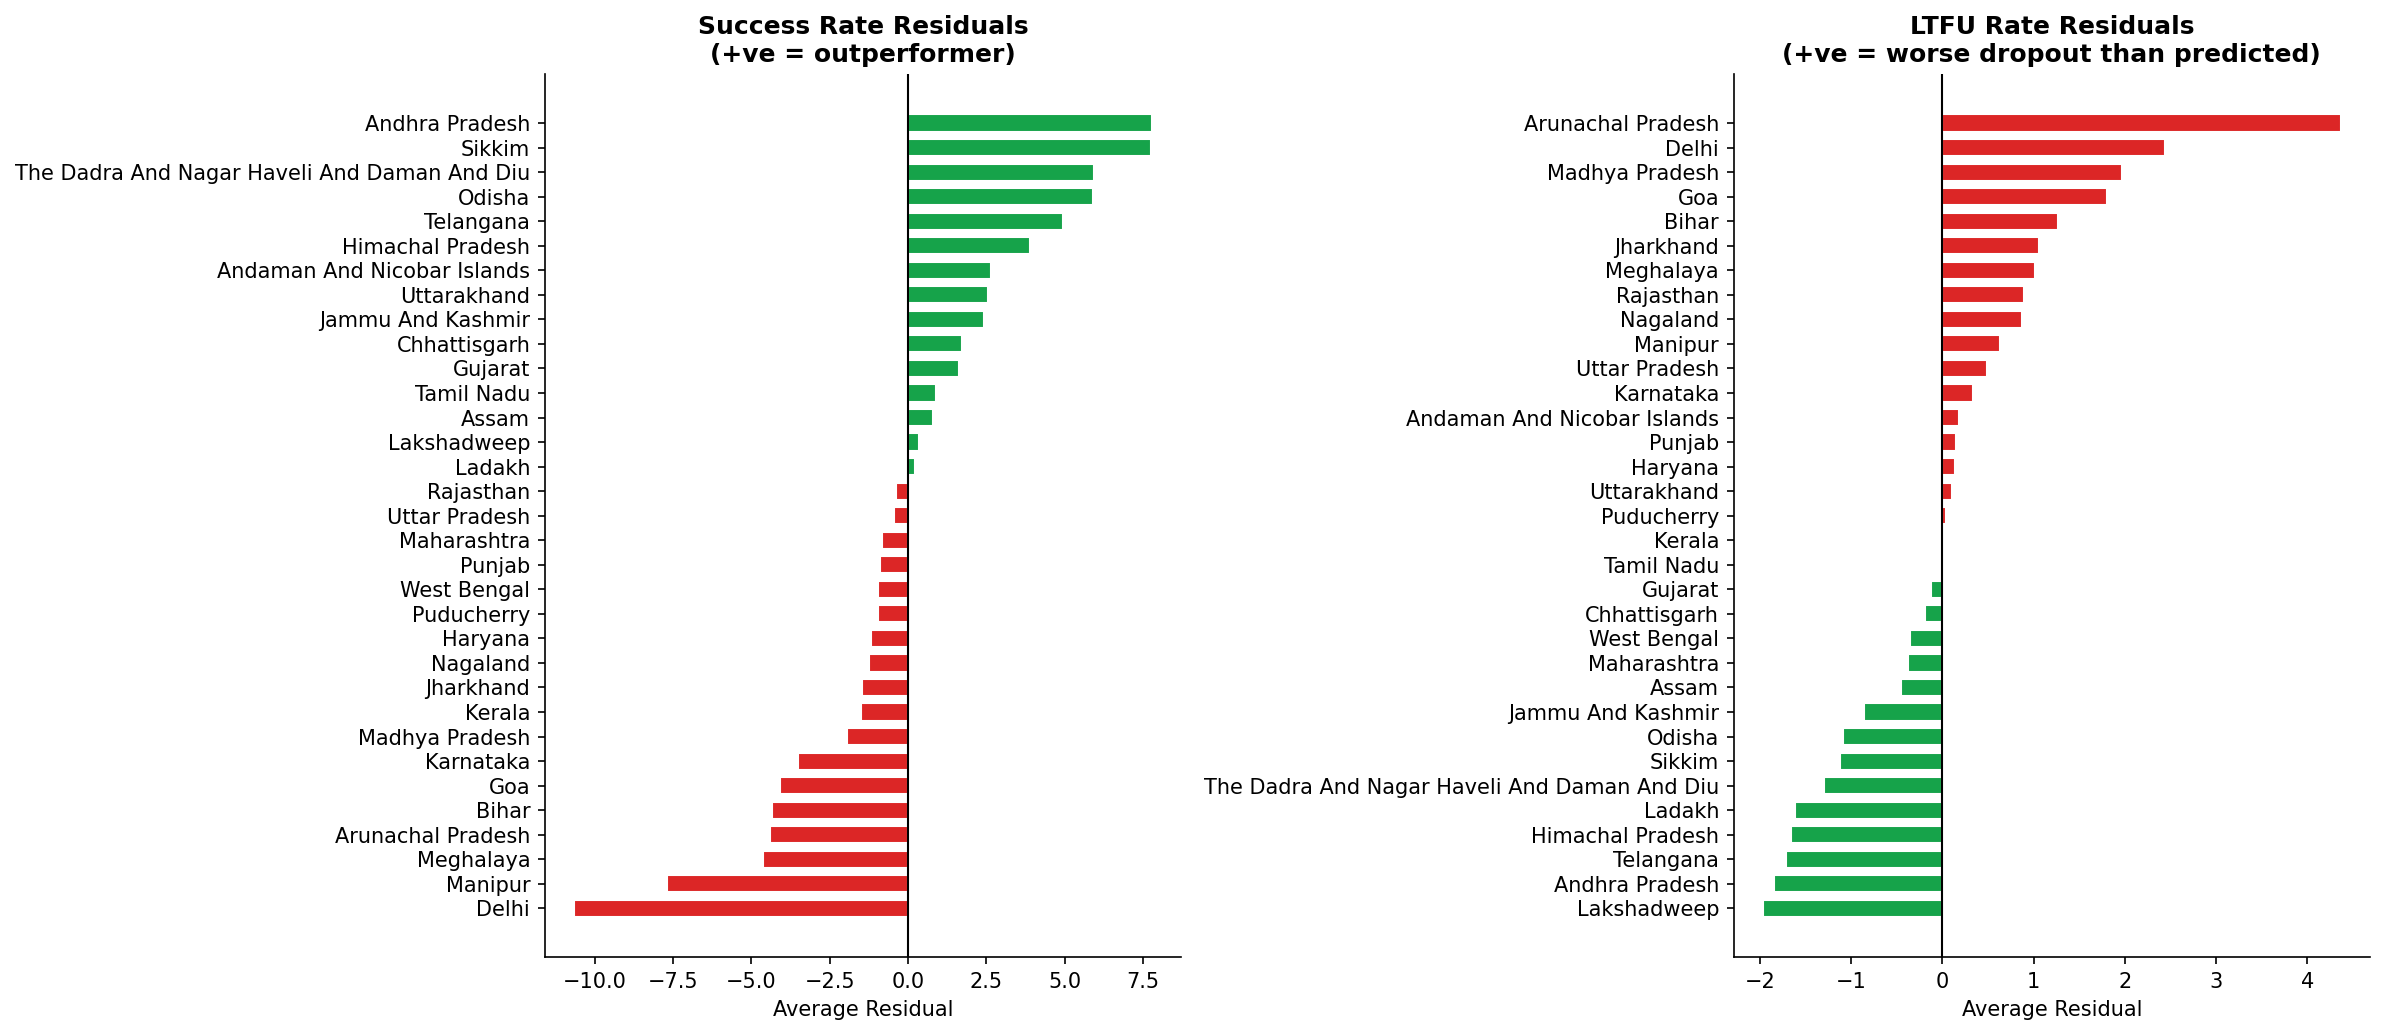

Saved 09_residuals_by_state.png

Top outperformers (success rate):
                                       StateName  avg_resid_success
1                                 Andhra Pradesh           7.793818
26                                        Sikkim           7.745043
29  The Dadra And Nagar Haveli And Daman And Diu           5.935689
22                                        Odisha           5.892991
28                                     Telangana           4.940538

Worst underperformers (success rate):
            StateName  avg_resid_success
6               Delhi         -10.671606
19            Manipur          -7.681977
20          Meghalaya          -4.639942
2   Arunachal Pradesh          -4.416844
4               Bihar          -4.349090


In [60]:
# ── RESIDUAL ANALYSIS — which states are outliers? ────────────────────────────
# Large positive residual = doing better than predicted (over-performer)
# Large negative residual = doing worse than predicted (under-performer)

spec1_copy = spec1.copy()
spec1_copy["resid_A"] = model_A.resid
spec1_copy["resid_B"] = model_B.resid

state_resid = (
    spec1_copy.groupby("StateName")[["resid_A", "resid_B"]]
              .mean()
              .reset_index()
              .rename(columns={
                  "resid_A": "avg_resid_success",
                  "resid_B": "avg_resid_ltfu"
              })
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (col, title, color_pos, color_neg) in zip(axes, [
    ("avg_resid_success", "Success Rate Residuals\n(+ve = outperformer)", GREEN, RED),
    ("avg_resid_ltfu",    "LTFU Rate Residuals\n(+ve = worse dropout than predicted)", RED, GREEN),
]):
    df_sorted = state_resid.sort_values(col)
    colors = [color_pos if v > 0 else color_neg for v in df_sorted[col]]
    ax.barh(df_sorted["StateName"], df_sorted[col],
            color=colors, edgecolor="white", height=0.7)
    ax.axvline(0, color="black", lw=1)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Average Residual")

plt.tight_layout()
plt.savefig(FIG_DIR / "09_residuals_by_state.png", bbox_inches="tight")
plt.show()
print("Saved 09_residuals_by_state.png")
print("\nTop outperformers (success rate):")
print(state_resid.nlargest(5, "avg_resid_success")[["StateName","avg_resid_success"]])
print("\nWorst underperformers (success rate):")
print(state_resid.nsmallest(5, "avg_resid_success")[["StateName","avg_resid_success"]])

In [61]:
import statsmodels.formula.api as smf

# Add state fixed effects via C() — absorbs all time-invariant state characteristics
model_fe = smf.ols(
    "notification_achievement_rate ~ presumptive_examination_rate "
    "+ lab_tech_fill_rate + C(StateCode)",
    data=spec3
).fit(cov_type='cluster', cov_kwds={'groups': spec3['StateCode']})

# Only care about the non-state coefficients
params = model_fe.params.filter(regex='^(?!C\(StateCode\))')
print(params)
print(f"R² with FE: {model_fe.rsquared:.3f}")

Intercept                       0.446933
presumptive_examination_rate    0.000184
lab_tech_fill_rate             -0.214708
dtype: float64
R² with FE: 0.661


<>:11: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:11: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
C:\Users\Administrator\AppData\Local\Temp\ipykernel_27548\4099112962.py:11: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
  params = model_fe.params.filter(regex='^(?!C\(StateCode\))')


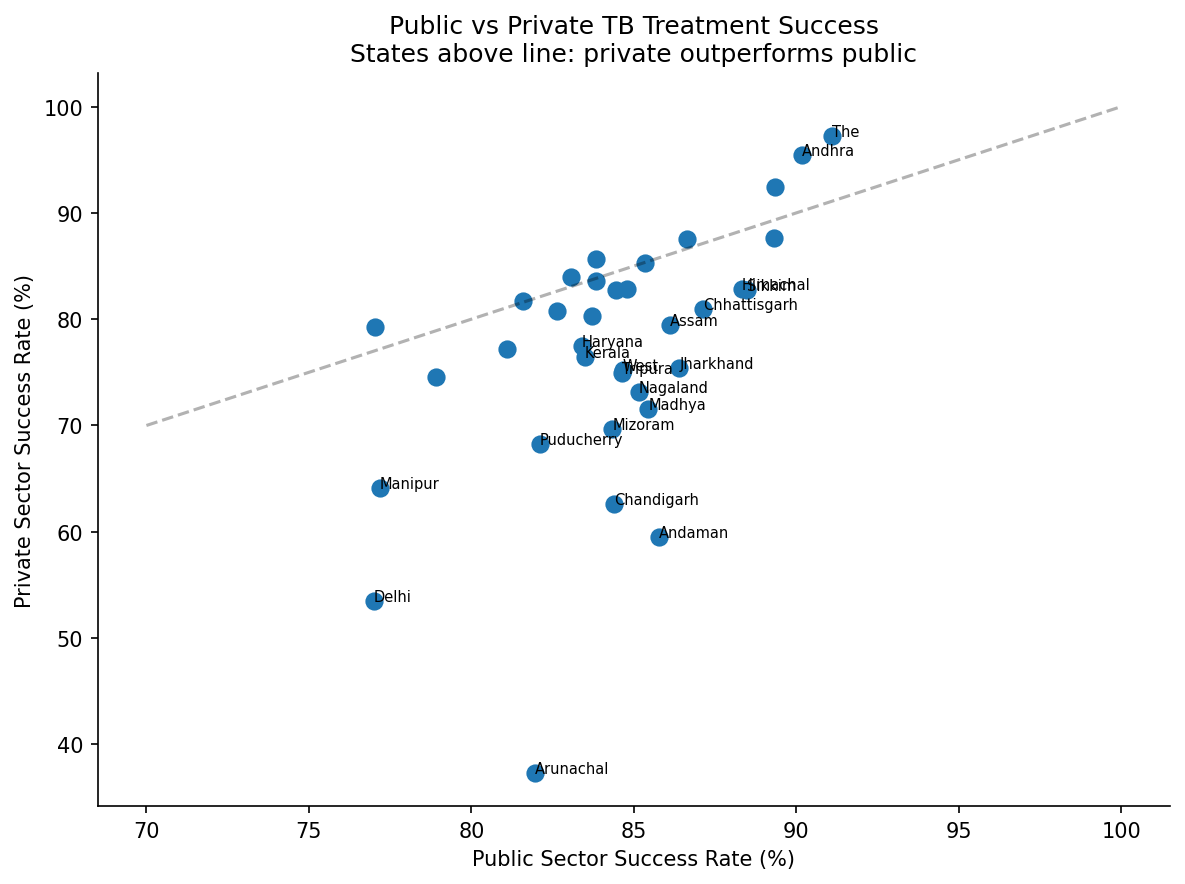


Largest public-private gaps:
StateName
Arunachal Pradesh                              -44.635000
Andaman And Nicobar Islands                    -26.280000
Delhi                                          -23.480000
Chandigarh                                     -21.760000
Mizoram                                        -14.680000
Madhya Pradesh                                 -13.880000
Puducherry                                     -13.850000
Manipur                                        -13.020000
Nagaland                                       -12.000000
Jharkhand                                      -10.980000
Tripura                                         -9.680000
West Bengal                                     -9.440000
Kerala                                          -7.075000
Assam                                           -6.620000
Chhattisgarh                                    -6.220000
Haryana                                         -5.920000
Sikkim                          

In [62]:
panel_full = pd.read_csv("data/cleaned/panel_full.csv")

# State average public vs private success rates
pub_priv = (
    panel_full.groupby("StateName")[
        ["success_rate", "success_rate_public", "success_rate_private", "ltfu_rate"]
    ].mean().dropna(subset=["success_rate_public", "success_rate_private"])
)

# Gap between public and private
pub_priv["pub_priv_gap"] = pub_priv["success_rate_private"] - pub_priv["success_rate_public"]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pub_priv["success_rate_public"], pub_priv["success_rate_private"], s=60)
ax.plot([70, 100], [70, 100], "k--", alpha=0.3, label="Public = Private line")
for state, row in pub_priv.iterrows():
    if abs(row["pub_priv_gap"]) > 5:
        ax.annotate(state.split()[0], 
                    (row["success_rate_public"], row["success_rate_private"]),
                    fontsize=7)
ax.set_xlabel("Public Sector Success Rate (%)")
ax.set_ylabel("Private Sector Success Rate (%)")
ax.set_title("Public vs Private TB Treatment Success\nStates above line: private outperforms public")
plt.tight_layout()
plt.show()

print("\nLargest public-private gaps:")
print(pub_priv["pub_priv_gap"].sort_values().to_string())

In [63]:
spec1_covid = spec1.copy()
spec1_covid["covid"] = spec1_covid["Year"].isin([2020, 2021]).astype(int)

model_covid = smf.ols(
    "success_rate ~ lab_tech_fill_rate + phc_doctor_fill_rate "
    "+ stunting_pct + improved_sanitation_pct + oop_per_hospitalisation + covid",
    data=spec1_covid
).fit(cov_type='cluster', cov_kwds={'groups': spec1_covid['StateCode']})

print(model_covid.params[["covid"]])
print(model_covid.pvalues[["covid"]])

covid    0.144123
dtype: float64
covid    0.834396
dtype: float64


In [64]:
gender = pd.read_csv("data/cleaned/tb_gender.csv")
gender_2122 = gender[gender["Year"].isin([2021, 2022])]

# Compare notification rates and success rates by gender
print(gender_2122.groupby("Year")[
    ["cases_notified_male", "cases_notified_female",
     "success_rate_male", "success_rate_female"]
].mean().round(2))

# Gender gap in notification (male:female ratio — should be ~1 ideally)
gender_2122 = gender_2122.copy()
gender_2122["notif_ratio"] = (
    gender_2122["cases_notified_male"] / gender_2122["cases_notified_female"]
)
print("\nStates with highest male:female notification ratio (most underdiagnosis of women):")
print(gender_2122.groupby("StateName")["notif_ratio"].mean().nlargest(10))

      cases_notified_male  cases_notified_female  success_rate_male  \
Year                                                                  
2021             41909.00               24767.42              78.56   
2022             29984.53               18640.64              82.31   

      success_rate_female  
Year                       
2021                83.03  
2022                85.39  

States with highest male:female notification ratio (most underdiagnosis of women):
StateName
Tripura           2.971533
Tamil Nadu        2.213128
Jharkhand         2.193419
West Bengal       2.070435
Assam             2.031808
Odisha            2.028210
Rajasthan         1.968930
Andhra Pradesh    1.942333
Kerala            1.934303
Puducherry        1.885323
Name: notif_ratio, dtype: float64


In [65]:
# ── PIPELINE METRICS ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

CLEAN_DIR = Path("data/cleaned")
FIG_DIR   = Path("figures")
BLUE, RED, GREEN, ORANGE = "#2563EB", "#DC2626", "#16A34A", "#F59E0B"

spec1  = pd.read_csv(CLEAN_DIR / "spec1_parsimonious.csv")
spec3  = pd.read_csv(CLEAN_DIR / "spec3_detection.csv")
panel_full = pd.read_csv(CLEAN_DIR / "panel_full.csv")

# State-level averages
state_avg = spec1.groupby("StateName")[
    ["success_rate", "ltfu_rate"]
].mean().reset_index()

notif_avg = spec3.groupby("StateName")[
    ["notification_achievement_rate"]
].mean().reset_index()

state_avg = state_avg.merge(notif_avg, on="StateName", how="inner")

# Pipeline metrics
state_avg["retention_rate"]    = 100 - state_avg["ltfu_rate"]
state_avg["detection_gap"]     = 1 - state_avg["notification_achievement_rate"]
state_avg["retention_gap"]     = state_avg["ltfu_rate"]
state_avg["system_efficiency"] = (
    state_avg["notification_achievement_rate"] * 
    state_avg["retention_rate"]
)

# Which gap dominates?
state_avg["dominant_failure"] = np.where(
    state_avg["detection_gap"] * 10 > state_avg["retention_gap"],
    "Detection-Dominated",
    "Retention-Dominated"
)

print("System efficiency by state:")
print(state_avg[["StateName","notification_achievement_rate",
                  "retention_rate","system_efficiency"]]
      .sort_values("system_efficiency", ascending=False)
      .to_string(index=False))

System efficiency by state:
                                   StateName  notification_achievement_rate  retention_rate  system_efficiency
                                       Delhi                       0.926490       95.200000          88.201848
                            Himachal Pradesh                       0.886249       98.800000          87.561417
                                   Telangana                       0.849003       99.350000          84.348444
                                      Kerala                       0.821305       97.875000          80.385196
                                     Gujarat                       0.812676       97.975000          79.621883
                                   Jharkhand                       0.814521       96.250000          78.397639
                                 Uttarakhand                       0.788339       97.100000          76.547672
                               Uttar Pradesh                       0.781561       97

In [66]:
# ── RULE-BASED STATE TYPOLOGY ─────────────────────────────────────────────────
x_med = state_avg["notification_achievement_rate"].median()
y_med = state_avg["ltfu_rate"].median()

def assign_type(row):
    hi_detect = row["notification_achievement_rate"] >= x_med
    hi_ltfu   = row["ltfu_rate"] >= y_med
    if hi_detect and hi_ltfu:
        return "Retention Failure"      # finds cases, loses patients
    elif hi_detect and not hi_ltfu:
        return "Efficient System"       # working well
    elif not hi_detect and hi_ltfu:
        return "Double Failure"         # crisis states
    else:
        return "Under-Detection"        # low detection, low LTFU

state_avg["system_type"] = state_avg.apply(assign_type, axis=1)

print("\nState Typology:")
for t in ["Efficient System", "Retention Failure", 
          "Under-Detection", "Double Failure"]:
    states = state_avg[state_avg["system_type"]==t]["StateName"].tolist()
    print(f"\n{t} ({len(states)} states):")
    print(", ".join(states))


State Typology:

Efficient System (8 states):
Andhra Pradesh, Gujarat, Himachal Pradesh, Kerala, Maharashtra, Odisha, Telangana, The Dadra And Nagar Haveli And Daman And Diu

Retention Failure (9 states):
Arunachal Pradesh, Delhi, Haryana, Jharkhand, Madhya Pradesh, Punjab, Rajasthan, Uttar Pradesh, Uttarakhand

Under-Detection (8 states):
Assam, Chhattisgarh, Jammu And Kashmir, Ladakh, Lakshadweep, Puducherry, Sikkim, West Bengal

Double Failure (8 states):
Andaman And Nicobar Islands, Bihar, Goa, Karnataka, Manipur, Meghalaya, Nagaland, Tamil Nadu


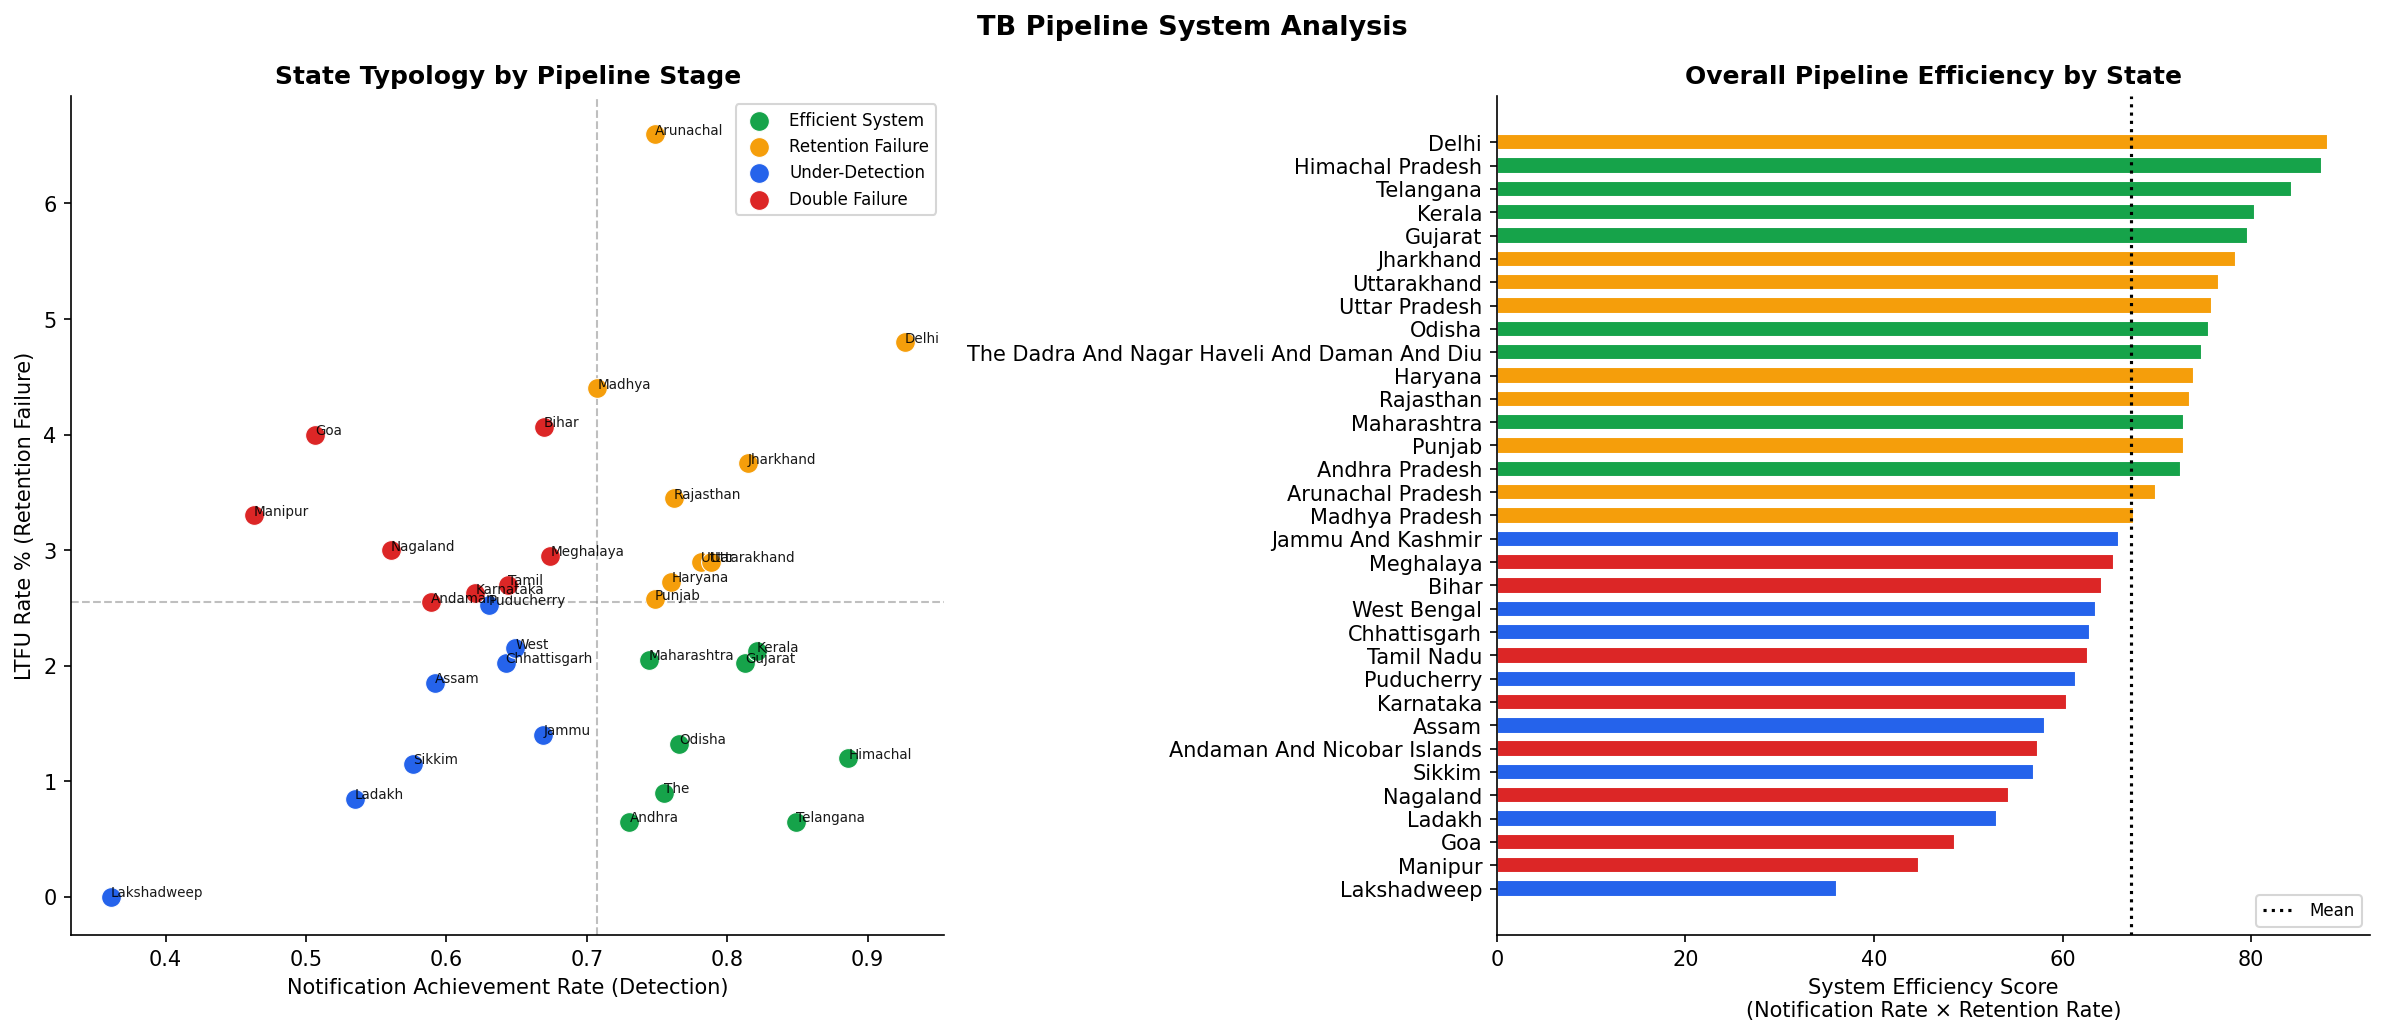

Saved 13_system_efficiency.png


In [67]:
# ── SYSTEM EFFICIENCY CHART ───────────────────────────────────────────────────
type_colors = {
    "Efficient System":   GREEN,
    "Retention Failure":  ORANGE,
    "Under-Detection":    BLUE,
    "Double Failure":     RED,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("TB Pipeline System Analysis", fontweight="bold", fontsize=13)

# Left: quadrant coloured by type
ax = axes[0]
for t, color in type_colors.items():
    sub = state_avg[state_avg["system_type"] == t]
    ax.scatter(sub["notification_achievement_rate"], sub["ltfu_rate"],
               color=color, s=90, label=t, edgecolors="white",
               linewidth=0.5, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row["StateName"].split()[0],
                    (row["notification_achievement_rate"], row["ltfu_rate"]),
                    fontsize=6.5, alpha=0.9)

ax.axvline(x_med, color="grey", lw=1, linestyle="--", alpha=0.5)
ax.axhline(y_med, color="grey", lw=1, linestyle="--", alpha=0.5)
ax.set_xlabel("Notification Achievement Rate (Detection)")
ax.set_ylabel("LTFU Rate % (Retention Failure)")
ax.set_title("State Typology by Pipeline Stage", fontweight="bold")
ax.legend(fontsize=8)

# Right: system efficiency ranking
ax = axes[1]
df_eff = state_avg.sort_values("system_efficiency")
bar_colors = [type_colors[t] for t in df_eff["system_type"]]
ax.barh(df_eff["StateName"], df_eff["system_efficiency"],
        color=bar_colors, edgecolor="white", height=0.7)
ax.set_xlabel("System Efficiency Score\n(Notification Rate × Retention Rate)")
ax.set_title("Overall Pipeline Efficiency by State", fontweight="bold")
ax.axvline(df_eff["system_efficiency"].mean(), color="black", 
           lw=1.5, linestyle=":", label="Mean")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "13_system_efficiency.png", bbox_inches="tight")
plt.show()
print("Saved 13_system_efficiency.png")

In [68]:
# ── DASHBOARD TABLE ───────────────────────────────────────────────────────────
# Add residuals from your earlier regression
spec1_copy = spec1.copy()

import statsmodels.formula.api as smf
model_A = smf.ols(
    "success_rate ~ lab_tech_fill_rate + phc_doctor_fill_rate "
    "+ stunting_pct + improved_sanitation_pct + oop_per_hospitalisation",
    data=spec1
).fit(cov_type='cluster', cov_kwds={'groups': spec1['StateCode']})

spec1_copy["resid"] = model_A.resid
resid_avg = spec1_copy.groupby("StateName")["resid"].mean().reset_index()
resid_avg.columns = ["StateName", "success_residual"]

dashboard = state_avg.merge(resid_avg, on="StateName", how="left")
dashboard["performance"] = dashboard["success_residual"].apply(
    lambda x: "Outperformer" if x > 2 else ("Underperformer" if x < -2 else "Average")
)

# Final table
cols = ["StateName", "notification_achievement_rate", "ltfu_rate",
        "system_efficiency", "system_type", "performance"]
dashboard_display = dashboard[cols].sort_values(
    "system_efficiency", ascending=False
).round(3)
dashboard_display.columns = [
    "State", "Detection Rate", "LTFU %", 
    "Efficiency Score", "System Type", "vs Prediction"
]

print("\n" + "="*90)
print("STATE DASHBOARD — TB PIPELINE ANALYSIS")
print("="*90)
print(dashboard_display.to_string(index=False))

dashboard_display.to_csv("data/cleaned/state_dashboard.csv", index=False)
print("\nSaved state_dashboard.csv")


STATE DASHBOARD — TB PIPELINE ANALYSIS
                                       State  Detection Rate  LTFU %  Efficiency Score       System Type  vs Prediction
                                       Delhi           0.926   4.800            88.202 Retention Failure Underperformer
                            Himachal Pradesh           0.886   1.200            87.561  Efficient System   Outperformer
                                   Telangana           0.849   0.650            84.348  Efficient System   Outperformer
                                      Kerala           0.821   2.125            80.385  Efficient System        Average
                                     Gujarat           0.813   2.025            79.622  Efficient System        Average
                                   Jharkhand           0.815   3.750            78.398 Retention Failure        Average
                                 Uttarakhand           0.788   2.900            76.548 Retention Failure   Outperformer


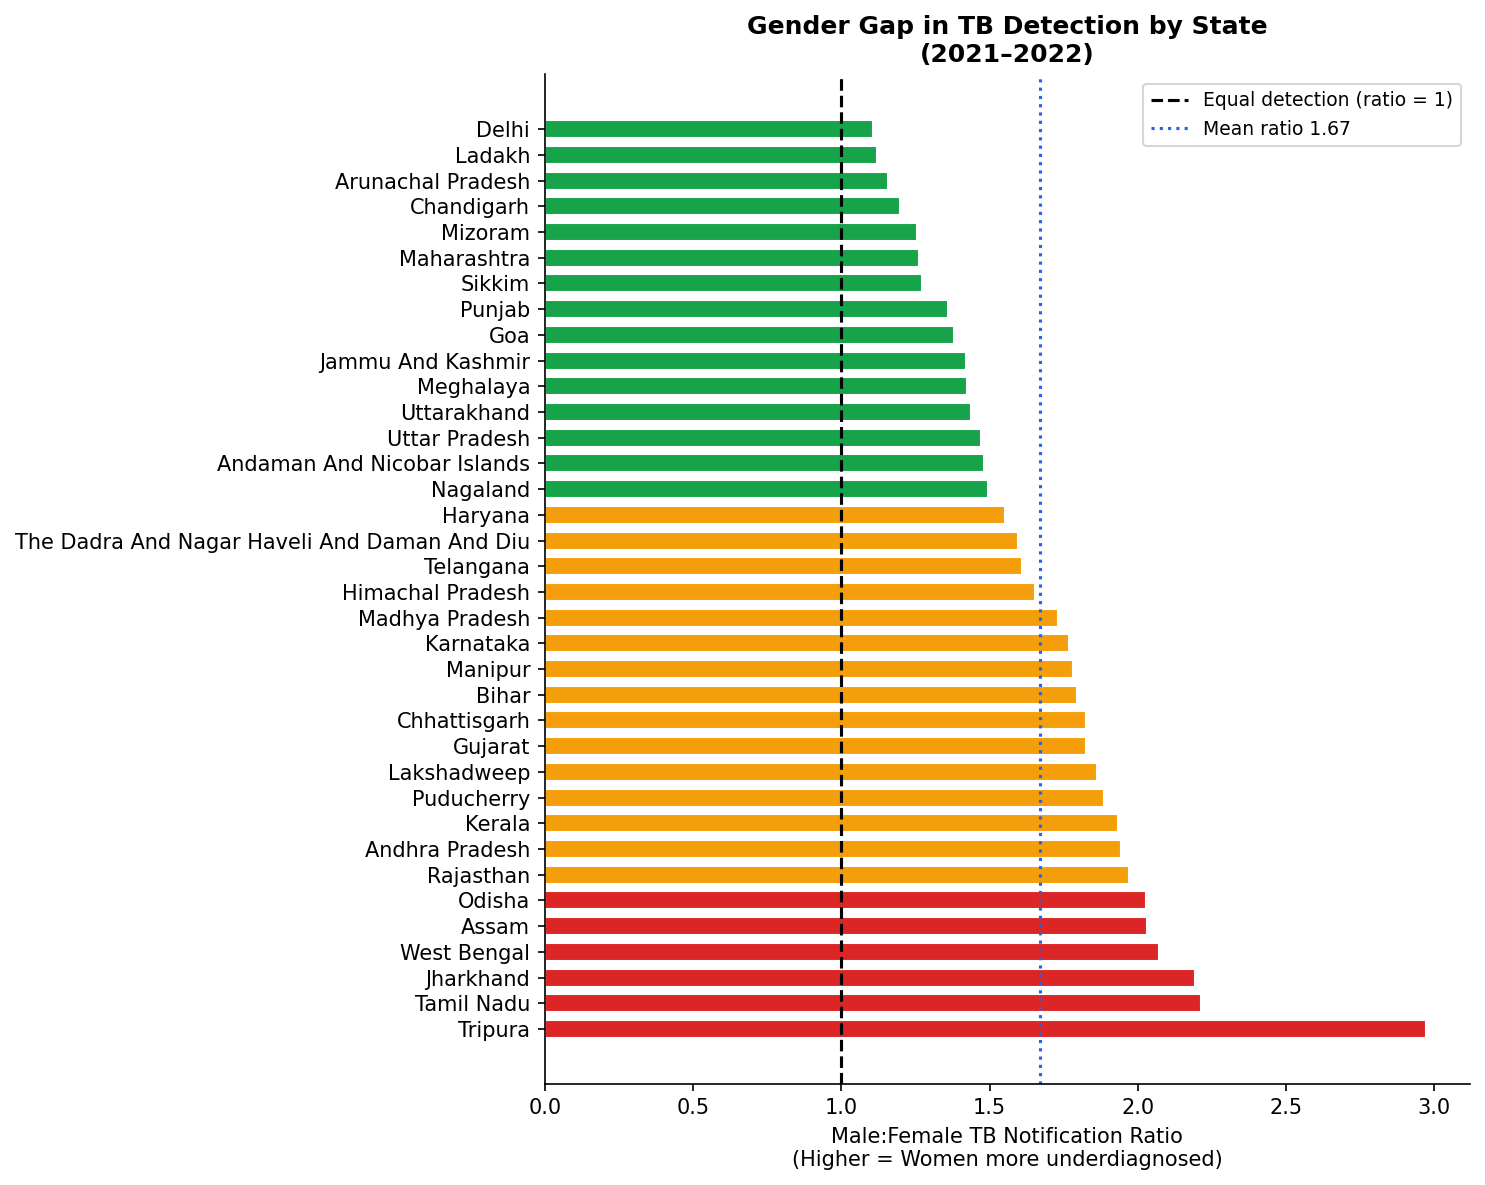

Saved 14_gender_gap.png


In [69]:
# ── GENDER CHART ──────────────────────────────────────────────────────────────
gender = pd.read_csv("data/cleaned/tb_gender.csv")
gender_2122 = gender[gender["Year"].isin([2021, 2022])].copy()
gender_2122["notif_ratio"] = (
    gender_2122["cases_notified_male"] / 
    gender_2122["cases_notified_female"]
)

ratio_avg = (
    gender_2122.groupby("StateName")["notif_ratio"]
               .mean().reset_index()
               .sort_values("notif_ratio", ascending=False)
               .dropna()
)

fig, ax = plt.subplots(figsize=(10, 8))
colors = [RED if r > 2 else (ORANGE if r > 1.5 else GREEN) 
          for r in ratio_avg["notif_ratio"]]
ax.barh(ratio_avg["StateName"], ratio_avg["notif_ratio"],
        color=colors, edgecolor="white", height=0.7)
ax.axvline(1.0, color="black", lw=1.5, linestyle="--", 
           label="Equal detection (ratio = 1)")
ax.axvline(ratio_avg["notif_ratio"].mean(), color=BLUE, lw=1.5,
           linestyle=":", label=f"Mean ratio {ratio_avg['notif_ratio'].mean():.2f}")
ax.set_xlabel("Male:Female TB Notification Ratio\n(Higher = Women more underdiagnosed)")
ax.set_title("Gender Gap in TB Detection by State\n(2021–2022)",
             fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "14_gender_gap.png", bbox_inches="tight")
plt.show()
print("Saved 14_gender_gap.png")

In [70]:
# ── PHASE 4: K-MEANS CLUSTERING ───────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

# Build clustering dataset — state-level averages
cluster_vars = [
    "lab_tech_fill_rate",
    "notification_achievement_rate",
    "ltfu_rate",
    "success_rate",
    "oop_per_hospitalisation",
]

# Use spec1 merged with spec3 notification data
notif = spec3[["StateCode","StateName","notification_achievement_rate"]].groupby(
    ["StateCode","StateName"]).mean().reset_index()

cluster_base = (
    spec1.groupby(["StateCode","StateName"])
         [["lab_tech_fill_rate","ltfu_rate","success_rate","oop_per_hospitalisation"]]
         .mean()
         .reset_index()
         .merge(notif, on=["StateCode","StateName"], how="inner")
         .dropna(subset=cluster_vars)
)

print(f"States available for clustering: {len(cluster_base)}")
print(cluster_base[["StateName"] + cluster_vars].to_string(index=False))

States available for clustering: 33
                                   StateName  lab_tech_fill_rate  notification_achievement_rate  ltfu_rate  success_rate  oop_per_hospitalisation
                           Jammu And Kashmir            0.114736                       0.668926   1.400000     85.150000              8724.000000
                            Himachal Pradesh            0.679176                       0.886249   1.200000     87.433333             18132.000000
                                      Punjab            0.234810                       0.748305   2.575000     82.325000             28177.000000
                                 Uttarakhand            0.542130                       0.788339   2.900000     85.300000             17960.000000
                                     Haryana            0.418036                       0.760187   2.725000     82.025000             19147.000000
                                       Delhi            0.196429                       0

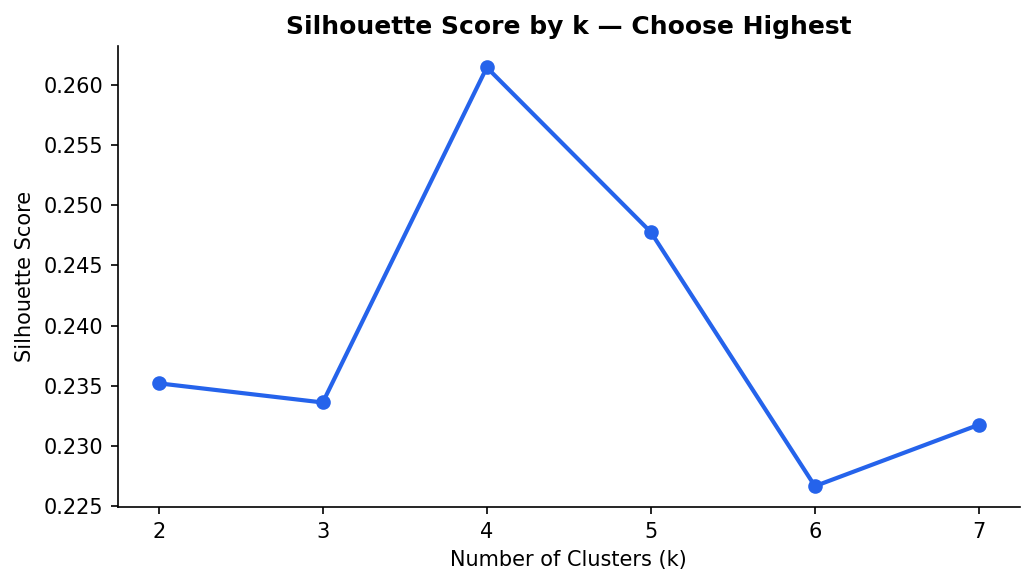

Silhouette scores: {2: 0.23520332651573644, 3: 0.2336083804831001, 4: 0.26146736821640726, 5: 0.24777175844209084, 6: 0.22665267974187767, 7: 0.2317608453095825}
Best k = 4


In [71]:
# ── SILHOUETTE SCORE — choose k ───────────────────────────────────────────────
X = cluster_base[cluster_vars].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(sil_scores.keys()), list(sil_scores.values()),
        marker="o", color=BLUE, lw=2)
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score by k — Choose Highest", fontweight="bold")
ax.set_xticks(list(sil_scores.keys()))
plt.tight_layout()
plt.savefig(FIG_DIR / "10_silhouette.png", bbox_inches="tight")
plt.show()
print("Silhouette scores:", sil_scores)
best_k = max(sil_scores, key=sil_scores.get)
print(f"Best k = {best_k}")

In [72]:
# ── FIT FINAL MODEL ───────────────────────────────────────────────────────────
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_base["cluster"] = km_final.fit_predict(X_scaled)

# Print cluster profiles
profile = cluster_base.groupby("cluster")[cluster_vars].mean().round(3)
print("\nCluster Profiles:")
print(profile.to_string())

# Print which states are in each cluster
print("\nStates per cluster:")
for c in sorted(cluster_base["cluster"].unique()):
    states = cluster_base[cluster_base["cluster"]==c]["StateName"].tolist()
    print(f"\nCluster {c}: {states}")


Cluster Profiles:
         lab_tech_fill_rate  notification_achievement_rate  ltfu_rate  success_rate  oop_per_hospitalisation
cluster                                                                                                     
0                     0.381                          0.738      2.838        84.090                19051.385
1                     0.061                          0.585      2.179        82.975                11936.385
2                     0.098                          0.838      5.700        76.275                10970.500
3                     0.125                          0.783      1.110        90.450                15943.942

States per cluster:

Cluster 0: ['Himachal Pradesh', 'Punjab', 'Uttarakhand', 'Haryana', 'Rajasthan', 'Uttar Pradesh', 'Bihar', 'West Bengal', 'Jharkhand', 'Chhattisgarh', 'Madhya Pradesh', 'Maharashtra', 'Tamil Nadu']

Cluster 1: ['Jammu And Kashmir', 'Sikkim', 'Nagaland', 'Manipur', 'Meghalaya', 'Assam', 'Karnataka', 'Goa'

In [73]:
# ── NAME THE CLUSTERS ─────────────────────────────────────────────────────────
# After seeing the profiles, assign names
# (You'll update this after seeing the output)
cluster_names = {
    0: "Cluster 0",   # update after seeing profiles
    1: "Cluster 1",
    2: "Cluster 2",
    3: "Cluster 3",
}
# Example names based on expected patterns — update to match actual output:
# "Infrastructure-Constrained"  → low fill, low notification
# "Cost-Constrained"            → decent infra, high LTFU
# "Systemically Functional"     → high fill, high success, low LTFU
# "Private-Dependent"           → weak public metrics but decent success

cluster_base["cluster_name"] = cluster_base["cluster"].map(cluster_names)

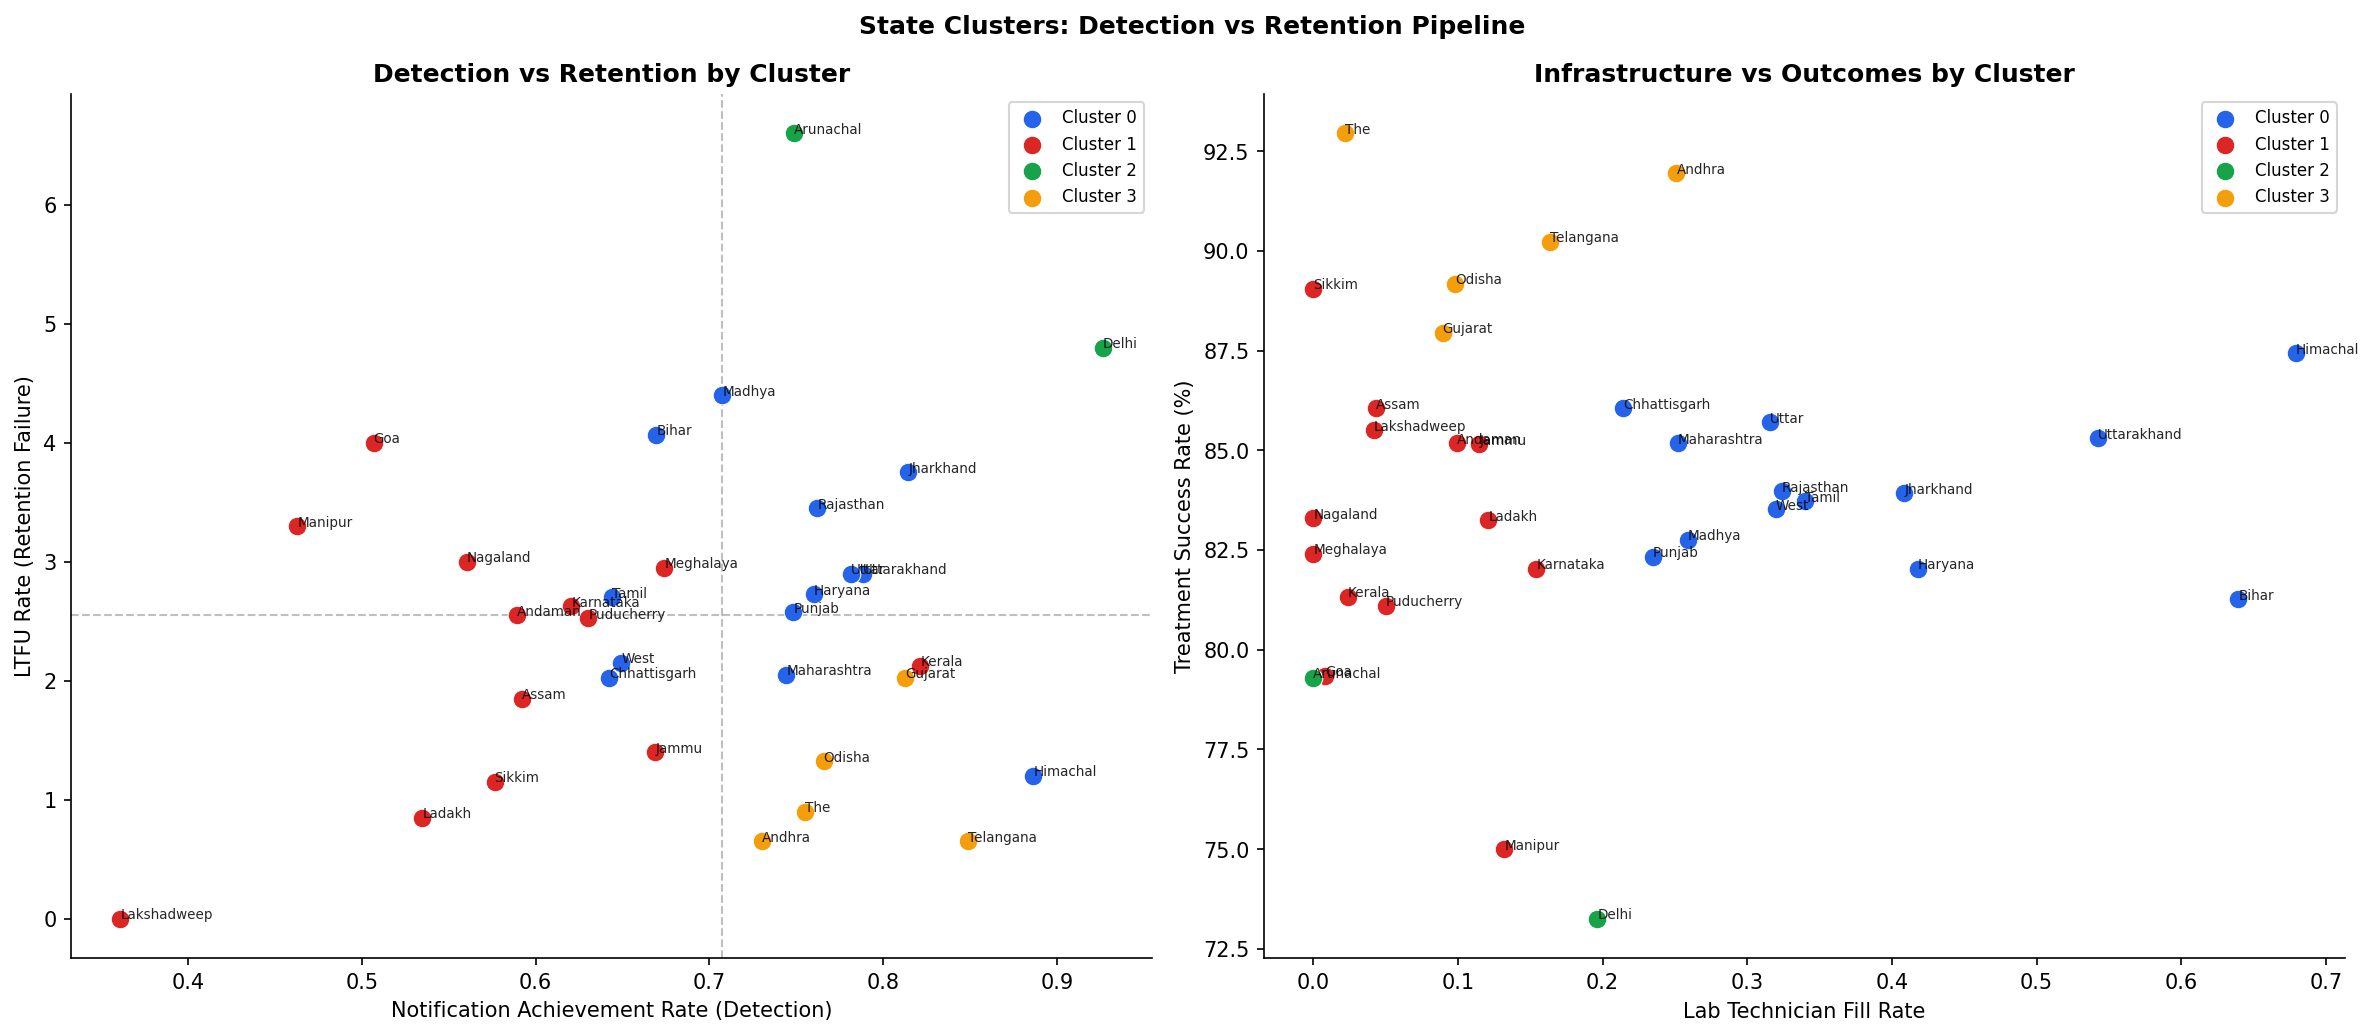

Saved 11_clusters.png


In [74]:
# ── CLUSTER SCATTER PLOT (quadrant-style) ─────────────────────────────────────
palette = {0: "#2563EB", 1: "#DC2626", 2: "#16A34A", 3: "#F59E0B"}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("State Clusters: Detection vs Retention Pipeline",
             fontweight="bold", fontsize=12)

# Left: notification vs LTFU (your quadrant chart, now coloured by cluster)
ax = axes[0]
for c in sorted(cluster_base["cluster"].unique()):
    sub = cluster_base[cluster_base["cluster"] == c]
    ax.scatter(sub["notification_achievement_rate"], sub["ltfu_rate"],
               color=palette[c], s=80, label=f"Cluster {c}",
               edgecolors="white", linewidth=0.5, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row["StateName"].split()[0],
                    (row["notification_achievement_rate"], row["ltfu_rate"]),
                    fontsize=6.5, alpha=0.85)

ax.axvline(cluster_base["notification_achievement_rate"].median(),
           color="grey", lw=1, linestyle="--", alpha=0.5)
ax.axhline(cluster_base["ltfu_rate"].median(),
           color="grey", lw=1, linestyle="--", alpha=0.5)
ax.set_xlabel("Notification Achievement Rate (Detection)")
ax.set_ylabel("LTFU Rate (Retention Failure)")
ax.set_title("Detection vs Retention by Cluster", fontweight="bold")
ax.legend(fontsize=8)

# Right: lab tech fill rate vs success rate
ax = axes[1]
for c in sorted(cluster_base["cluster"].unique()):
    sub = cluster_base[cluster_base["cluster"] == c]
    ax.scatter(sub["lab_tech_fill_rate"], sub["success_rate"],
               color=palette[c], s=80, label=f"Cluster {c}",
               edgecolors="white", linewidth=0.5, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row["StateName"].split()[0],
                    (row["lab_tech_fill_rate"], row["success_rate"]),
                    fontsize=6.5, alpha=0.85)

ax.set_xlabel("Lab Technician Fill Rate")
ax.set_ylabel("Treatment Success Rate (%)")
ax.set_title("Infrastructure vs Outcomes by Cluster", fontweight="bold")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "11_clusters.png", bbox_inches="tight")
plt.show()
print("Saved 11_clusters.png")

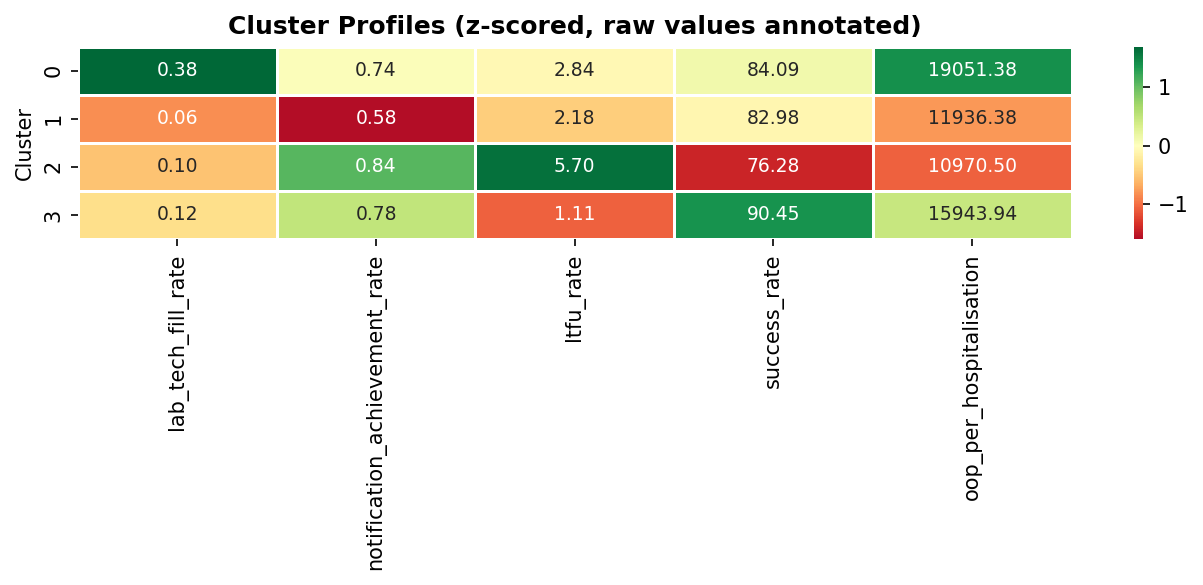

Saved 12_cluster_profiles.png


In [75]:
# ── CLUSTER PROFILE HEATMAP ───────────────────────────────────────────────────
profile_norm = cluster_base.groupby("cluster")[cluster_vars].mean()
profile_scaled = pd.DataFrame(
    StandardScaler().fit_transform(profile_norm),
    index=profile_norm.index,
    columns=profile_norm.columns
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(profile_scaled, annot=profile_norm.round(2),
            fmt=".2f", cmap="RdYlGn", center=0,
            linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_title("Cluster Profiles (z-scored, raw values annotated)",
             fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig(FIG_DIR / "12_cluster_profiles.png", bbox_inches="tight")
plt.show()
print("Saved 12_cluster_profiles.png")

In [76]:
# ── PUBLIC VS PRIVATE LTFU DECOMPOSITION ──────────────────────────────────────
panel_full = pd.read_csv("data/cleaned/panel_full.csv")

ltfu_split = (
    panel_full.groupby("StateName")[
        ["ltfu_rate", "ltfu_rate_public", "ltfu_rate_private"]
    ].mean()
    .dropna(subset=["ltfu_rate_public", "ltfu_rate_private"])
    .reset_index()
)

ltfu_split["private_excess_ltfu"] = (
    ltfu_split["ltfu_rate_private"] - ltfu_split["ltfu_rate_public"]
)

ltfu_split["private_drives_retention"] = (
    ltfu_split["ltfu_rate_private"] > ltfu_split["ltfu_rate_public"]
)

print("States where PRIVATE LTFU is worse than public:")
print(
    ltfu_split[ltfu_split["private_drives_retention"]]
    [["StateName","ltfu_rate_public","ltfu_rate_private","private_excess_ltfu"]]
    .sort_values("private_excess_ltfu", ascending=False)
    .to_string(index=False)
)

print("\nStates where PUBLIC LTFU is worse than private:")
print(
    ltfu_split[~ltfu_split["private_drives_retention"]]
    [["StateName","ltfu_rate_public","ltfu_rate_private","private_excess_ltfu"]]
    .sort_values("private_excess_ltfu")
    .to_string(index=False)
)

States where PRIVATE LTFU is worse than public:
                  StateName  ltfu_rate_public  ltfu_rate_private  private_excess_ltfu
                  Jharkhand              2.08              6.940                4.860
             Madhya Pradesh              3.36              7.840                4.480
                    Haryana              2.20              5.140                2.940
                  Rajasthan              2.80              5.340                2.540
                  Meghalaya              2.64              4.840                2.200
                    Gujarat              1.82              3.820                2.000
                      Delhi              4.50              6.180                1.680
               Chhattisgarh              1.66              2.920                1.260
              Uttar Pradesh              3.00              4.240                1.240
           Himachal Pradesh              1.38              2.500                1.120
      

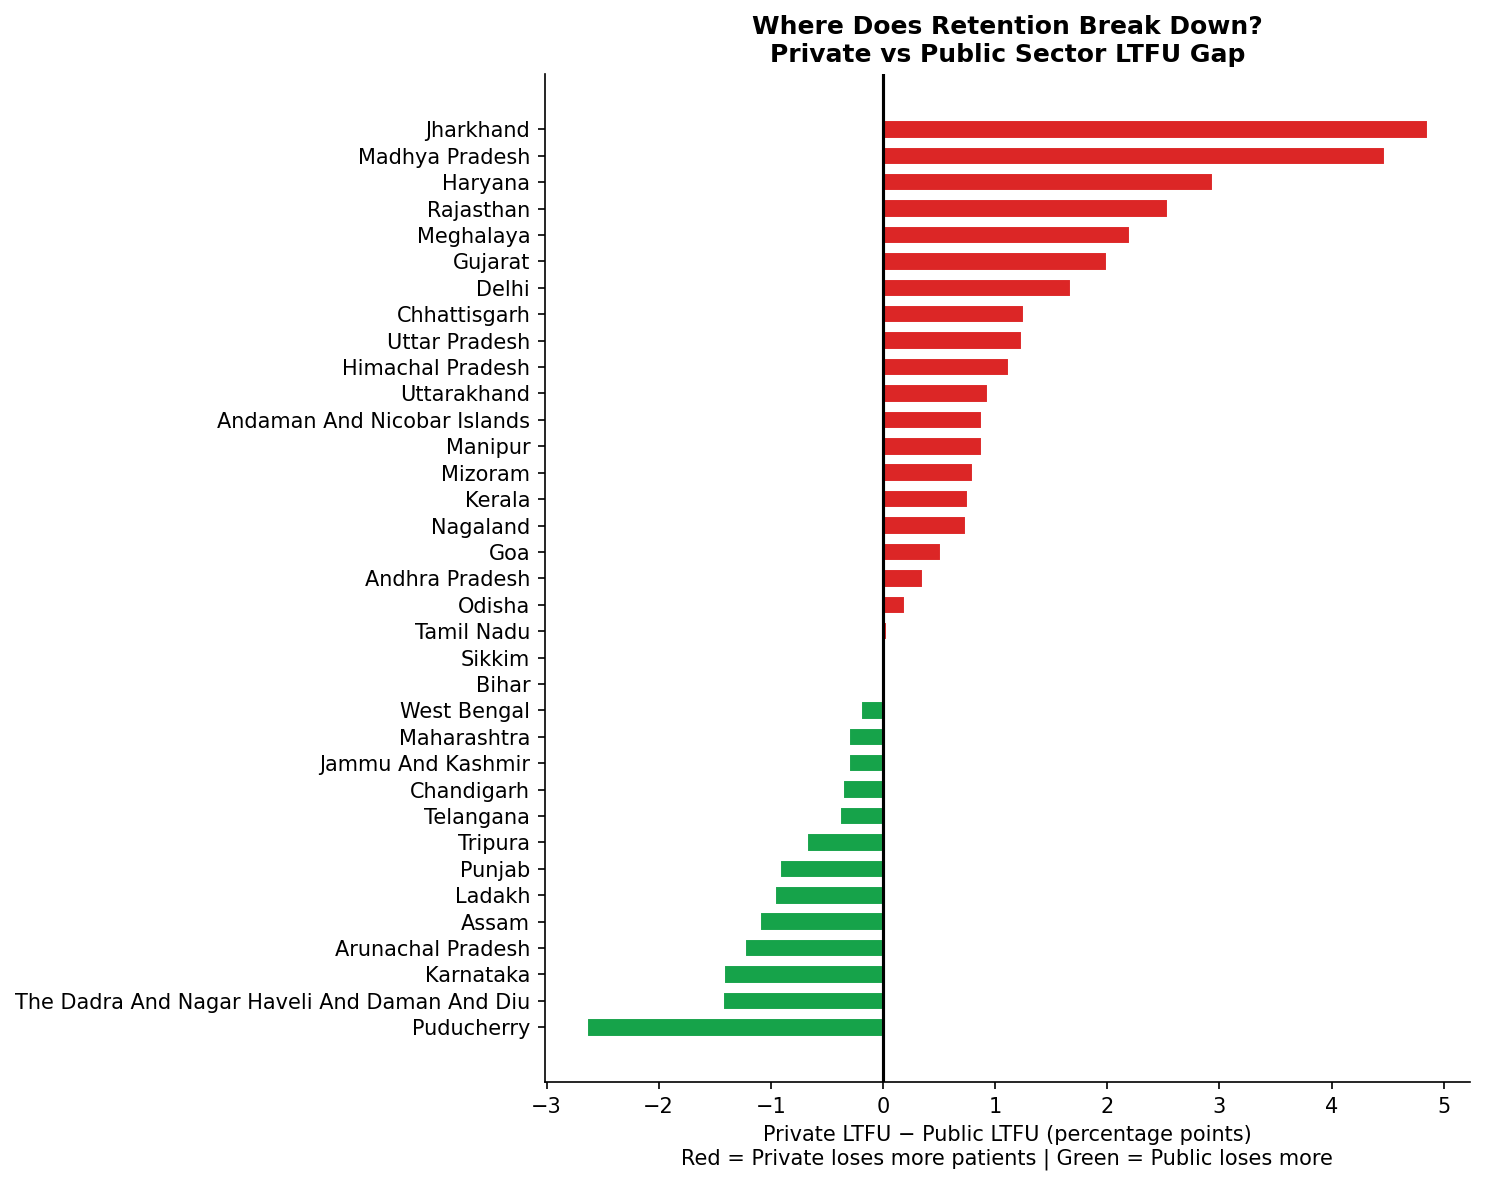

In [77]:
# Plot it
fig, ax = plt.subplots(figsize=(10, 8))
df_sorted = ltfu_split.sort_values("private_excess_ltfu")
colors = [RED if v > 0 else GREEN for v in df_sorted["private_excess_ltfu"]]

ax.barh(df_sorted["StateName"], df_sorted["private_excess_ltfu"],
        color=colors, edgecolor="white", height=0.7)
ax.axvline(0, color="black", lw=1.5)
ax.set_xlabel("Private LTFU − Public LTFU (percentage points)\n"
              "Red = Private loses more patients | Green = Public loses more")
ax.set_title("Where Does Retention Break Down?\nPrivate vs Public Sector LTFU Gap",
             fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "15_ltfu_public_private.png", bbox_inches="tight")
plt.show()

In [78]:
# ── LTFU TRAJECTORY ANALYSIS ──────────────────────────────────────────────────
from scipy import stats

ltfu_trends = panel_full[["StateName", "Year", "ltfu_rate"]].dropna()

def compute_trend(group):
    if len(group) < 3:
        return pd.Series({"slope": None, "pval": None, "direction": "insufficient data"})
    slope, intercept, r, p, se = stats.linregress(group["Year"], group["ltfu_rate"])
    direction = "Improving" if slope < 0 else "Worsening"
    return pd.Series({"slope": round(slope, 4), "pval": round(p, 3), "direction": direction})

trends = (
    ltfu_trends.groupby("StateName")
               .apply(compute_trend)
               .reset_index()
               .dropna(subset=["slope"])
               .sort_values("slope")
)

print("States with IMPROVING LTFU (decreasing dropout over time):")
print(trends[trends["direction"]=="Improving"]
      [["StateName","slope","pval"]].to_string(index=False))

print("\nStates with WORSENING LTFU (increasing dropout over time):")
print(trends[trends["direction"]=="Worsening"]
      [["StateName","slope","pval"]].sort_values("slope", ascending=False)
      .to_string(index=False))

States with IMPROVING LTFU (decreasing dropout over time):
                                   StateName   slope  pval
The Dadra And Nagar Haveli And Daman And Diu -1.3352 0.036
                               Uttar Pradesh -0.9100 0.000
                                     Haryana -0.7000 0.009
                                 Maharashtra -0.6900 0.007
                                   Karnataka -0.6700 0.032
                                     Gujarat -0.6500 0.005
                                       Assam -0.5800 0.037
                                      Odisha -0.5600 0.009
                              Andhra Pradesh -0.5100 0.003
                                 Uttarakhand -0.4800 0.005
                                   Rajasthan -0.3800 0.061
                                      Punjab -0.3300 0.102
                                   Telangana -0.3100 0.105
                                 West Bengal -0.2800 0.043
                                      Ladakh -0.2300 0.4

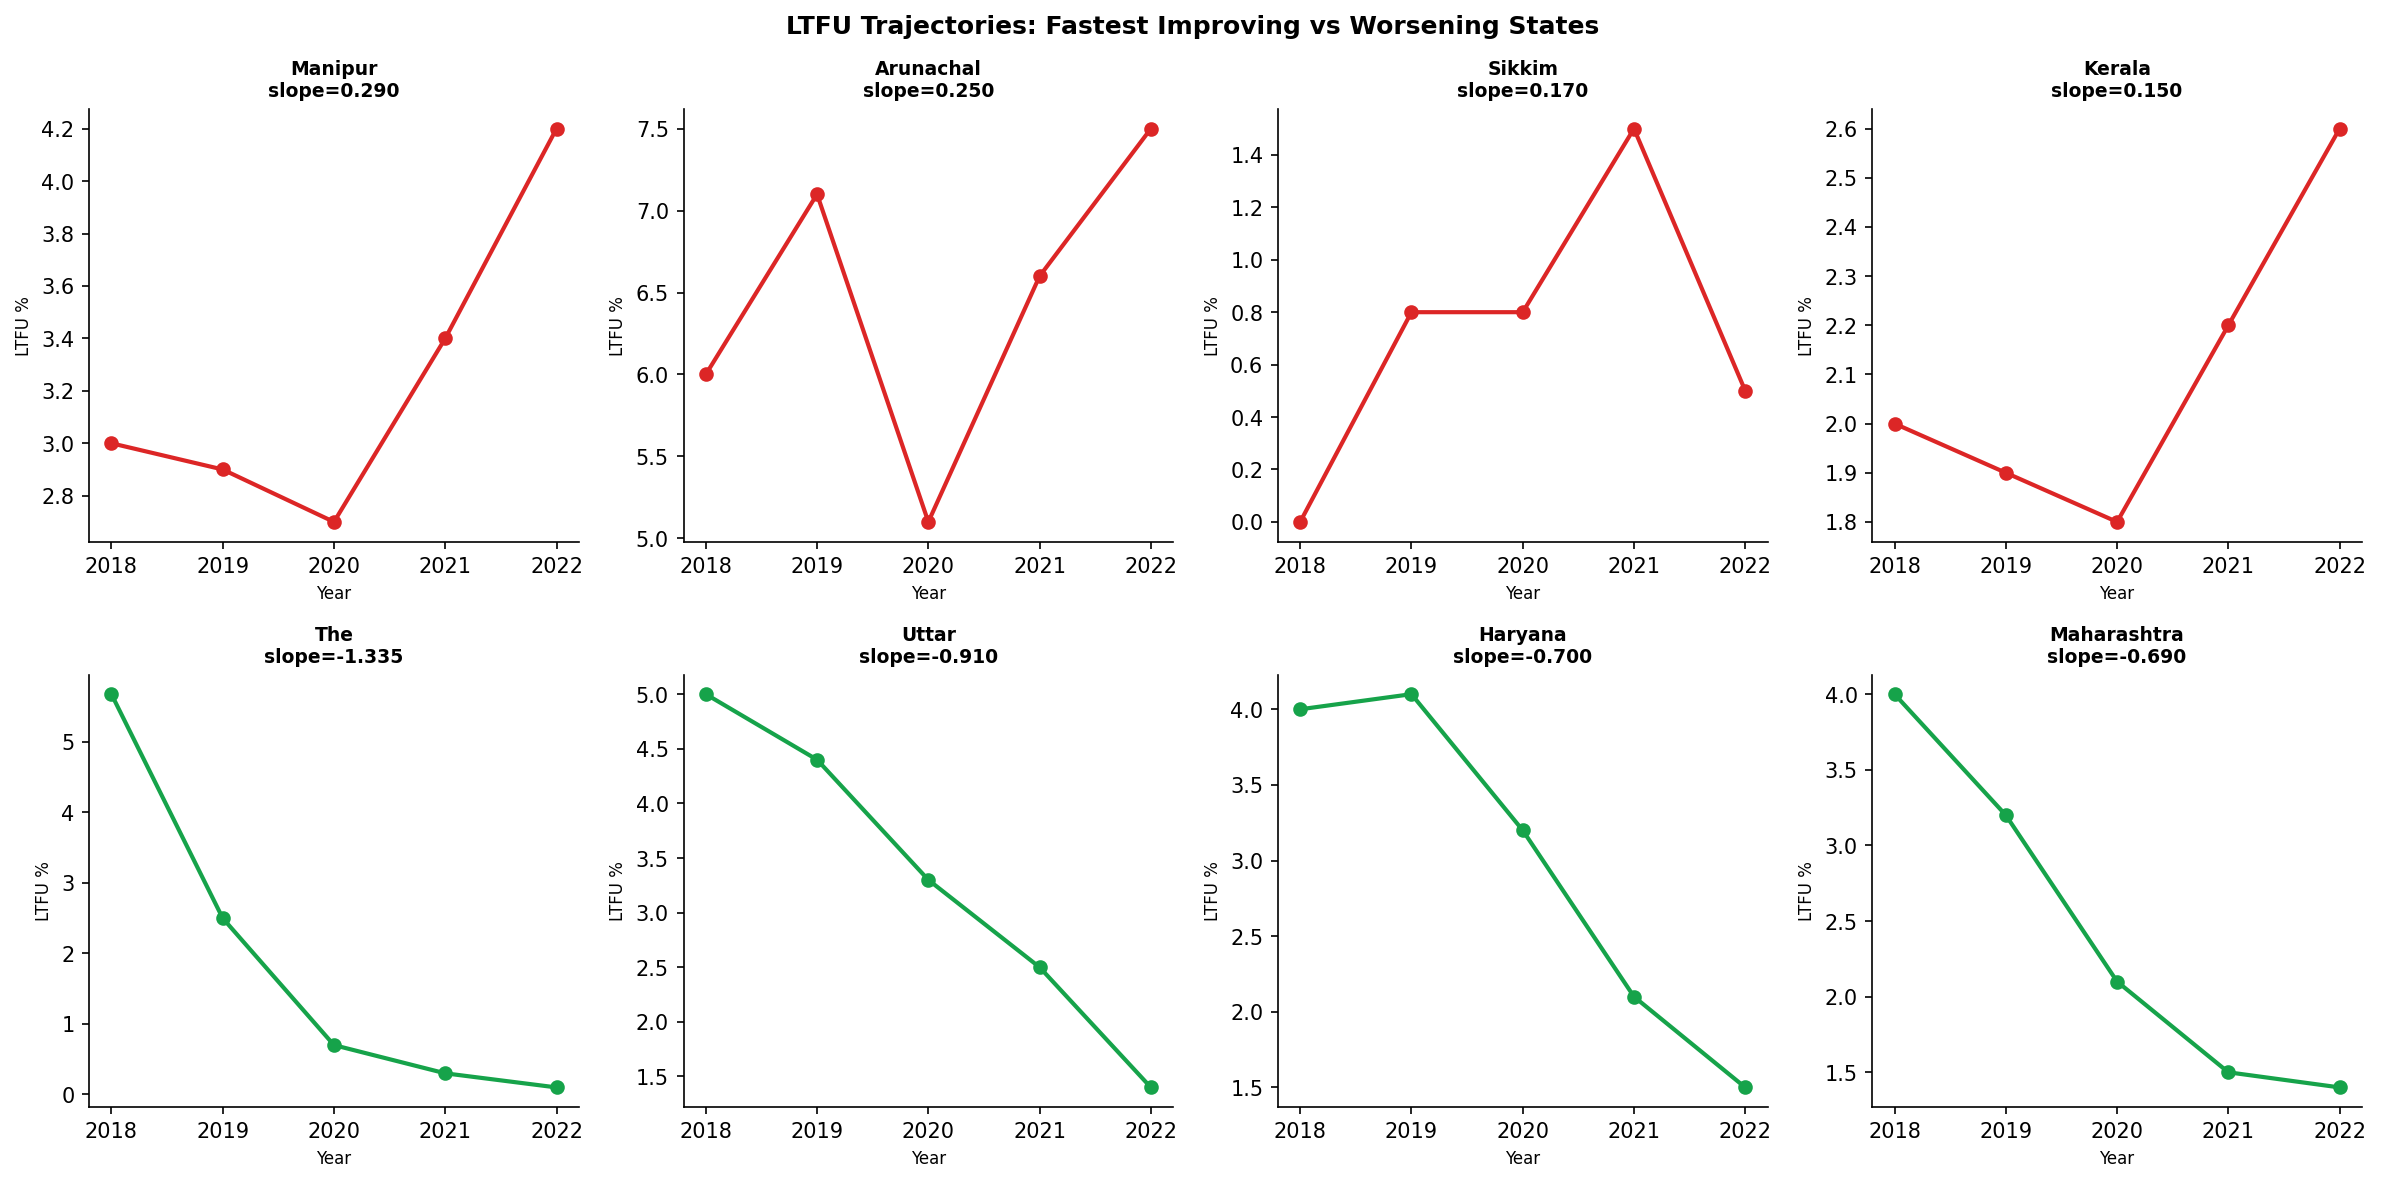

In [79]:
# Plot trajectories for the most extreme states
extreme_states = (
    trends.nlargest(4, "slope")["StateName"].tolist() +
    trends.nsmallest(4, "slope")["StateName"].tolist()
)

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=False)
fig.suptitle("LTFU Trajectories: Fastest Improving vs Worsening States",
             fontweight="bold", fontsize=12)

for ax, state in zip(axes.flat, extreme_states):
    data = ltfu_trends[ltfu_trends["StateName"] == state].sort_values("Year")
    slope_val = trends[trends["StateName"]==state]["slope"].values[0]
    color = GREEN if slope_val < 0 else RED
    
    ax.plot(data["Year"], data["ltfu_rate"],
            marker="o", color=color, lw=2)
    ax.set_title(f"{state.split()[0]}\nslope={slope_val:.3f}",
                 fontsize=9, fontweight="bold")
    ax.set_xlabel("Year", fontsize=8)
    ax.set_ylabel("LTFU %", fontsize=8)
    ax.set_xticks([2018, 2019, 2020, 2021, 2022])

plt.tight_layout()
plt.savefig(FIG_DIR / "16_ltfu_trajectories.png", bbox_inches="tight")
plt.show()

In [83]:
# ── NEW VS RETREATMENT LTFU ───────────────────────────────────────────────────
# Check if these files exist from your earlier data pull
import os

new_pt_path  = "data/raw/TB_TreatmentOutcome_New_Public_raw.csv"
retx_path    = "data/raw/TB_TreatmentOutcome_PreviouslyTreated_Public_raw.csv"

if os.path.exists(new_pt_path) and os.path.exists(retx_path):
    new_pt = pd.read_csv(new_pt_path)
    retx   = pd.read_csv(retx_path)
    
    # Find LTFU columns
    ltfu_new_col  = [c for c in new_pt.columns  if "lost_to_follow" in c.lower() 
                     and "percent" in c.lower() and "_avg" in c]
    ltfu_retx_col = [c for c in retx.columns if "lost_to_follow" in c.lower() 
                     and "percent" in c.lower() and "_avg" in c]
    
    print("New patient LTFU columns:", ltfu_new_col)
    print("Retreatment LTFU columns:", ltfu_retx_col)
    
    if ltfu_new_col and ltfu_retx_col:
        new_avg  = new_pt.groupby("StateName")[ltfu_new_col[0]].mean().reset_index()
        retx_avg = retx.groupby("StateName")[ltfu_retx_col[0]].mean().reset_index()
        
        comparison = new_avg.merge(retx_avg, on="StateName", suffixes=("_new","_retx"))
        comparison.columns = ["StateName", "ltfu_new", "ltfu_retreatment"]
        comparison["retreatment_excess"] = (
            comparison["ltfu_retreatment"] - comparison["ltfu_new"]
        )
        
        print("\nNew vs Retreatment LTFU by state:")
        print(comparison.sort_values("retreatment_excess", ascending=False)
              .to_string(index=False))
else:
    print("Files not found — check your data/raw directory for these filenames")
    print(os.listdir("data/raw"))

New patient LTFU columns: ['Percentage_of_lost_to_follow_up_avg']
Retreatment LTFU columns: ['Percentage_of_lost_to_follow_up_avg']

New vs Retreatment LTFU by state:
                                   StateName  ltfu_new  ltfu_retreatment  retreatment_excess
                                  Puducherry  2.083333          7.950000            5.866667
                                         Goa  3.216667          8.483333            5.266667
                                  Tamil Nadu  2.716667          6.183333            3.466667
The Dadra And Nagar Haveli And Daman And Diu  2.608720          5.870089            3.261369
                                   Karnataka  3.283333          6.433333            3.150000
                                 Maharashtra  2.500000          5.150000            2.650000
                                     Tripura  2.366667          4.950000            2.583333
                                 West Bengal  2.516667          4.816667            2.300

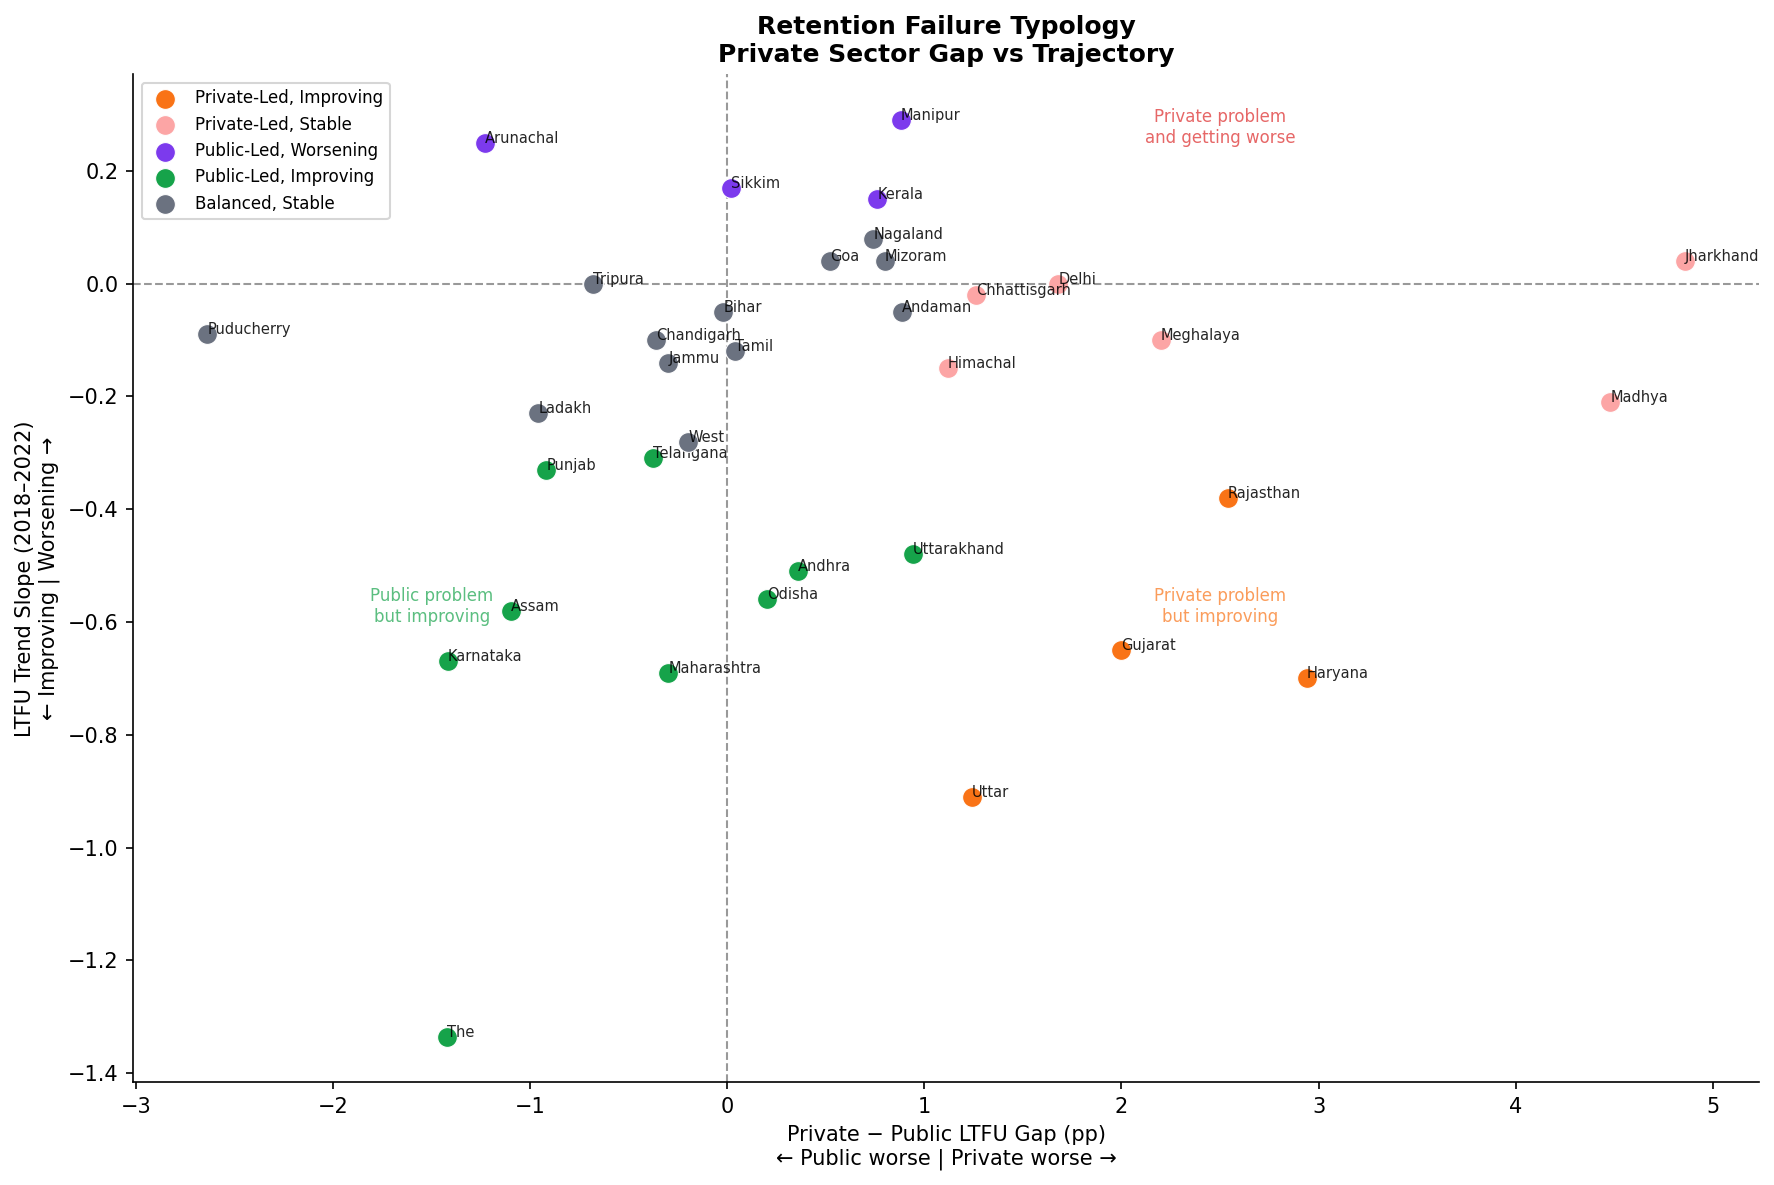

Saved 17_retention_typology.png


In [81]:
# ── RETENTION SYNTHESIS CHART ─────────────────────────────────────────────────
# Combine private excess LTFU + trajectory to characterise retention failure type

ltfu_split = (
    panel_full.groupby("StateName")[
        ["ltfu_rate","ltfu_rate_public","ltfu_rate_private"]
    ].mean()
    .dropna(subset=["ltfu_rate_public","ltfu_rate_private"])
    .reset_index()
)
ltfu_split["private_excess"] = (
    ltfu_split["ltfu_rate_private"] - ltfu_split["ltfu_rate_public"]
)

# Merge trajectory slopes
trends_clean = trends[["StateName","slope","pval"]].copy()
retention_synthesis = ltfu_split.merge(trends_clean, on="StateName", how="inner")

# Classify retention failure type
def retention_type(row):
    private_problem = row["private_excess"] > 1.0
    worsening       = row["slope"] > 0.1
    improving       = row["slope"] < -0.3
    
    if private_problem and worsening:
        return "Private-Led, Worsening"
    elif private_problem and improving:
        return "Private-Led, Improving"
    elif private_problem:
        return "Private-Led, Stable"
    elif worsening:
        return "Public-Led, Worsening"
    elif improving:
        return "Public-Led, Improving"
    else:
        return "Balanced, Stable"

retention_synthesis["retention_failure_type"] = retention_synthesis.apply(
    retention_type, axis=1
)

# Plot: private excess vs trend slope — scatter by type
type_colors = {
    "Private-Led, Worsening":  RED,
    "Private-Led, Improving":  "#F97316",
    "Private-Led, Stable":     "#FCA5A5",
    "Public-Led, Worsening":   "#7C3AED",
    "Public-Led, Improving":   GREEN,
    "Balanced, Stable":        "#6B7280",
}

fig, ax = plt.subplots(figsize=(12, 8))
for rtype, color in type_colors.items():
    sub = retention_synthesis[retention_synthesis["retention_failure_type"]==rtype]
    if len(sub) == 0:
        continue
    ax.scatter(sub["private_excess"], sub["slope"],
               color=color, s=90, label=rtype,
               edgecolors="white", linewidth=0.5, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row["StateName"].split()[0],
                    (row["private_excess"], row["slope"]),
                    fontsize=7, alpha=0.85)

ax.axvline(0, color="black", lw=1, linestyle="--", alpha=0.4)
ax.axhline(0, color="black", lw=1, linestyle="--", alpha=0.4)
ax.set_xlabel("Private − Public LTFU Gap (pp)\n← Public worse | Private worse →",
              fontsize=10)
ax.set_ylabel("LTFU Trend Slope (2018–2022)\n← Improving | Worsening →",
              fontsize=10)
ax.set_title("Retention Failure Typology\nPrivate Sector Gap vs Trajectory",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=8, loc="upper left")

# Quadrant labels
ax.text( 2.5,  0.25, "Private problem\nand getting worse",
         fontsize=8, color=RED, alpha=0.7, ha="center")
ax.text(-1.5, -0.6,  "Public problem\nbut improving",
         fontsize=8, color=GREEN, alpha=0.7, ha="center")
ax.text( 2.5, -0.6,  "Private problem\nbut improving",
         fontsize=8, color="#F97316", alpha=0.7, ha="center")

plt.tight_layout()
plt.savefig(FIG_DIR / "17_retention_typology.png", bbox_inches="tight")
plt.show()
print("Saved 17_retention_typology.png")

In [89]:
import pandas as pd
import numpy as np
from numpy import average

# ── Load population data ─────────────────────────────────────────────────────
pop_data = pd.read_csv("data/cleaned/tb_presumptive.csv")

# --- Clean state names (robust fix for mismatches) ---
def clean_state(s):
    return (
        str(s)
        .lower()
        .replace("&", "and")
        .replace("  ", " ")
        .strip()
    )

# Apply cleaning
state_avg["StateName_clean"] = state_avg["StateName"].apply(clean_state)
pop_data["StateName_clean"]  = pop_data["StateName"].apply(clean_state)

# Aggregate population
pop_avg = (
    pop_data.groupby("StateName_clean")["population"]
    .mean()
    .reset_index()
)

# ── Merge into dashboard ─────────────────────────────────────────────────────
dashboard_weighted = state_avg.merge(
    pop_avg,
    on="StateName_clean",
    how="left"
)

# ── Debug missing population ─────────────────────────────────────────────────
print("Missing population:", dashboard_weighted["population"].isna().sum())
print(
    dashboard_weighted[dashboard_weighted["population"].isna()][
        ["StateName", "StateName_clean"]
    ]
)

# ── Filter valid rows (IMPORTANT) ────────────────────────────────────────────
valid_success = dashboard_weighted[
    dashboard_weighted["success_rate"].notna() &
    dashboard_weighted["population"].notna()
]

valid_ltfu = dashboard_weighted[
    dashboard_weighted["ltfu_rate"].notna() &
    dashboard_weighted["population"].notna()
]

# ── Weighted national averages ───────────────────────────────────────────────
w_success = average(
    valid_success["success_rate"],
    weights=valid_success["population"]
)

w_ltfu = average(
    valid_ltfu["ltfu_rate"],
    weights=valid_ltfu["population"]
)

# ── Unweighted vs weighted comparison ────────────────────────────────────────
print(f"\nUnweighted mean success rate: {state_avg['success_rate'].mean():.2f}%")
print(f"Population-weighted success rate: {w_success:.2f}%")

print(f"\nUnweighted mean LTFU: {state_avg['ltfu_rate'].mean():.2f}%")
print(f"Population-weighted LTFU: {w_ltfu:.2f}%")

# ── Sanity check ─────────────────────────────────────────────────────────────
print("\nStates used (success):", len(valid_success))
print("States used (ltfu):", len(valid_ltfu))
print("Total population weight:", valid_success["population"].sum())

Missing population: 0
Empty DataFrame
Columns: [StateName, StateName_clean]
Index: []

Unweighted mean success rate: 84.14%
Population-weighted success rate: 84.58%

Unweighted mean LTFU: 2.49%
Population-weighted LTFU: 2.68%

States used (success): 33
States used (ltfu): 33
Total population weight: 13785.016199999998


In [91]:
print(ltfu_split.columns)

Index(['StateName', 'ltfu_rate', 'ltfu_rate_public', 'ltfu_rate_private',
       'private_excess'],
      dtype='str')


Correlation: private sector dependence vs private LTFU excess:
                            treatment_from_private_pct  private_excess
treatment_from_private_pct                    1.000000        0.167688
private_excess                                0.167688        1.000000


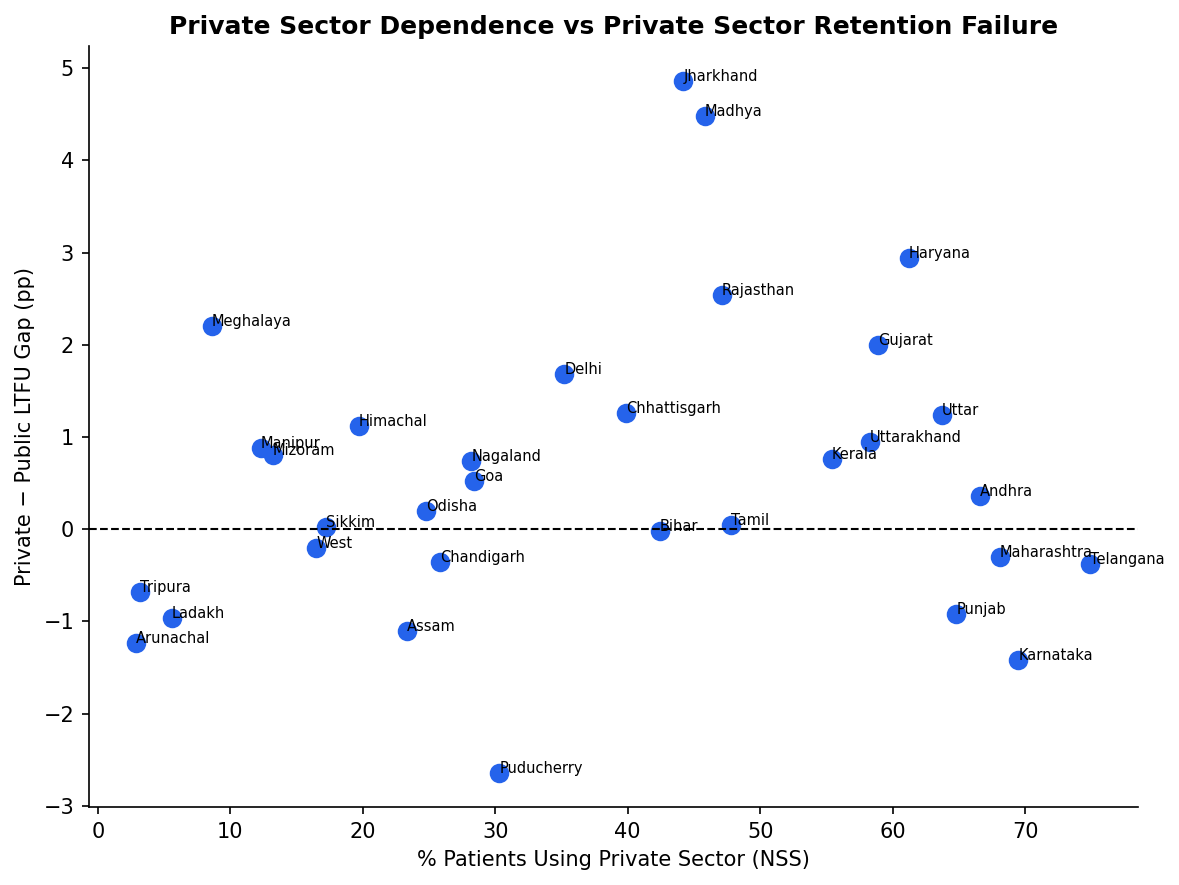

In [92]:
nss_treatment = pd.read_csv("data/cleaned/nss_treatment_source.csv")
priv_dep = nss_treatment[["StateCode","StateName","treatment_from_private_pct"]].copy()

# Merge with your LTFU split
retention_check = ltfu_split.merge(
    priv_dep,
    on="StateName",
    how="inner"
)
corr = retention_check[["treatment_from_private_pct","private_excess"]].corr()
print("Correlation: private sector dependence vs private LTFU excess:")
print(corr)

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(retention_check["treatment_from_private_pct"],
           retention_check["private_excess"], s=70, color=BLUE)
for _, row in retention_check.iterrows():
    ax.annotate(row["StateName"].split()[0],
                (row["treatment_from_private_pct"], row["private_excess"]),
                fontsize=7)
ax.axhline(0, color="black", lw=1, linestyle="--")
ax.set_xlabel("% Patients Using Private Sector (NSS)")
ax.set_ylabel("Private − Public LTFU Gap (pp)")
ax.set_title("Private Sector Dependence vs Private Sector Retention Failure",
             fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "18_private_dependence_ltfu.png", bbox_inches="tight")
plt.show()

In [93]:
health_exp = pd.read_csv("data/cleaned/health_expenditure.csv")

# Total expenditure proxy
health_exp["total_exp"] = (
    health_exp["expenditure_rural_health"].fillna(0) +
    health_exp["expenditure_urban_health"].fillna(0) +
    health_exp["expenditure_public_health"].fillna(0)
)

exp_avg = health_exp.groupby("StateName")["total_exp"].mean().reset_index()

# Merge with outcomes
exp_check = state_avg.merge(exp_avg, on="StateName", how="inner")

for outcome in ["success_rate", "notification_achievement_rate", "ltfu_rate"]:
    corr = exp_check[["total_exp", outcome]].corr().iloc[0,1]
    print(f"Health expenditure vs {outcome}: r = {corr:.3f}")

Health expenditure vs success_rate: r = 0.077
Health expenditure vs notification_achievement_rate: r = 0.359
Health expenditure vs ltfu_rate: r = 0.047


In [94]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_c = spec3[["presumptive_examination_rate","lab_tech_fill_rate",
             "phc_doctor_fill_rate","stunting_pct"]].dropna()
vif = pd.DataFrame({
    "feature": X_c.columns,
    "VIF": [variance_inflation_factor(X_c.values, i) 
            for i in range(X_c.shape[1])]
})
print(vif)

                        feature       VIF
0  presumptive_examination_rate  3.041911
1            lab_tech_fill_rate  2.685216
2          phc_doctor_fill_rate  2.983628
3                  stunting_pct  5.318783


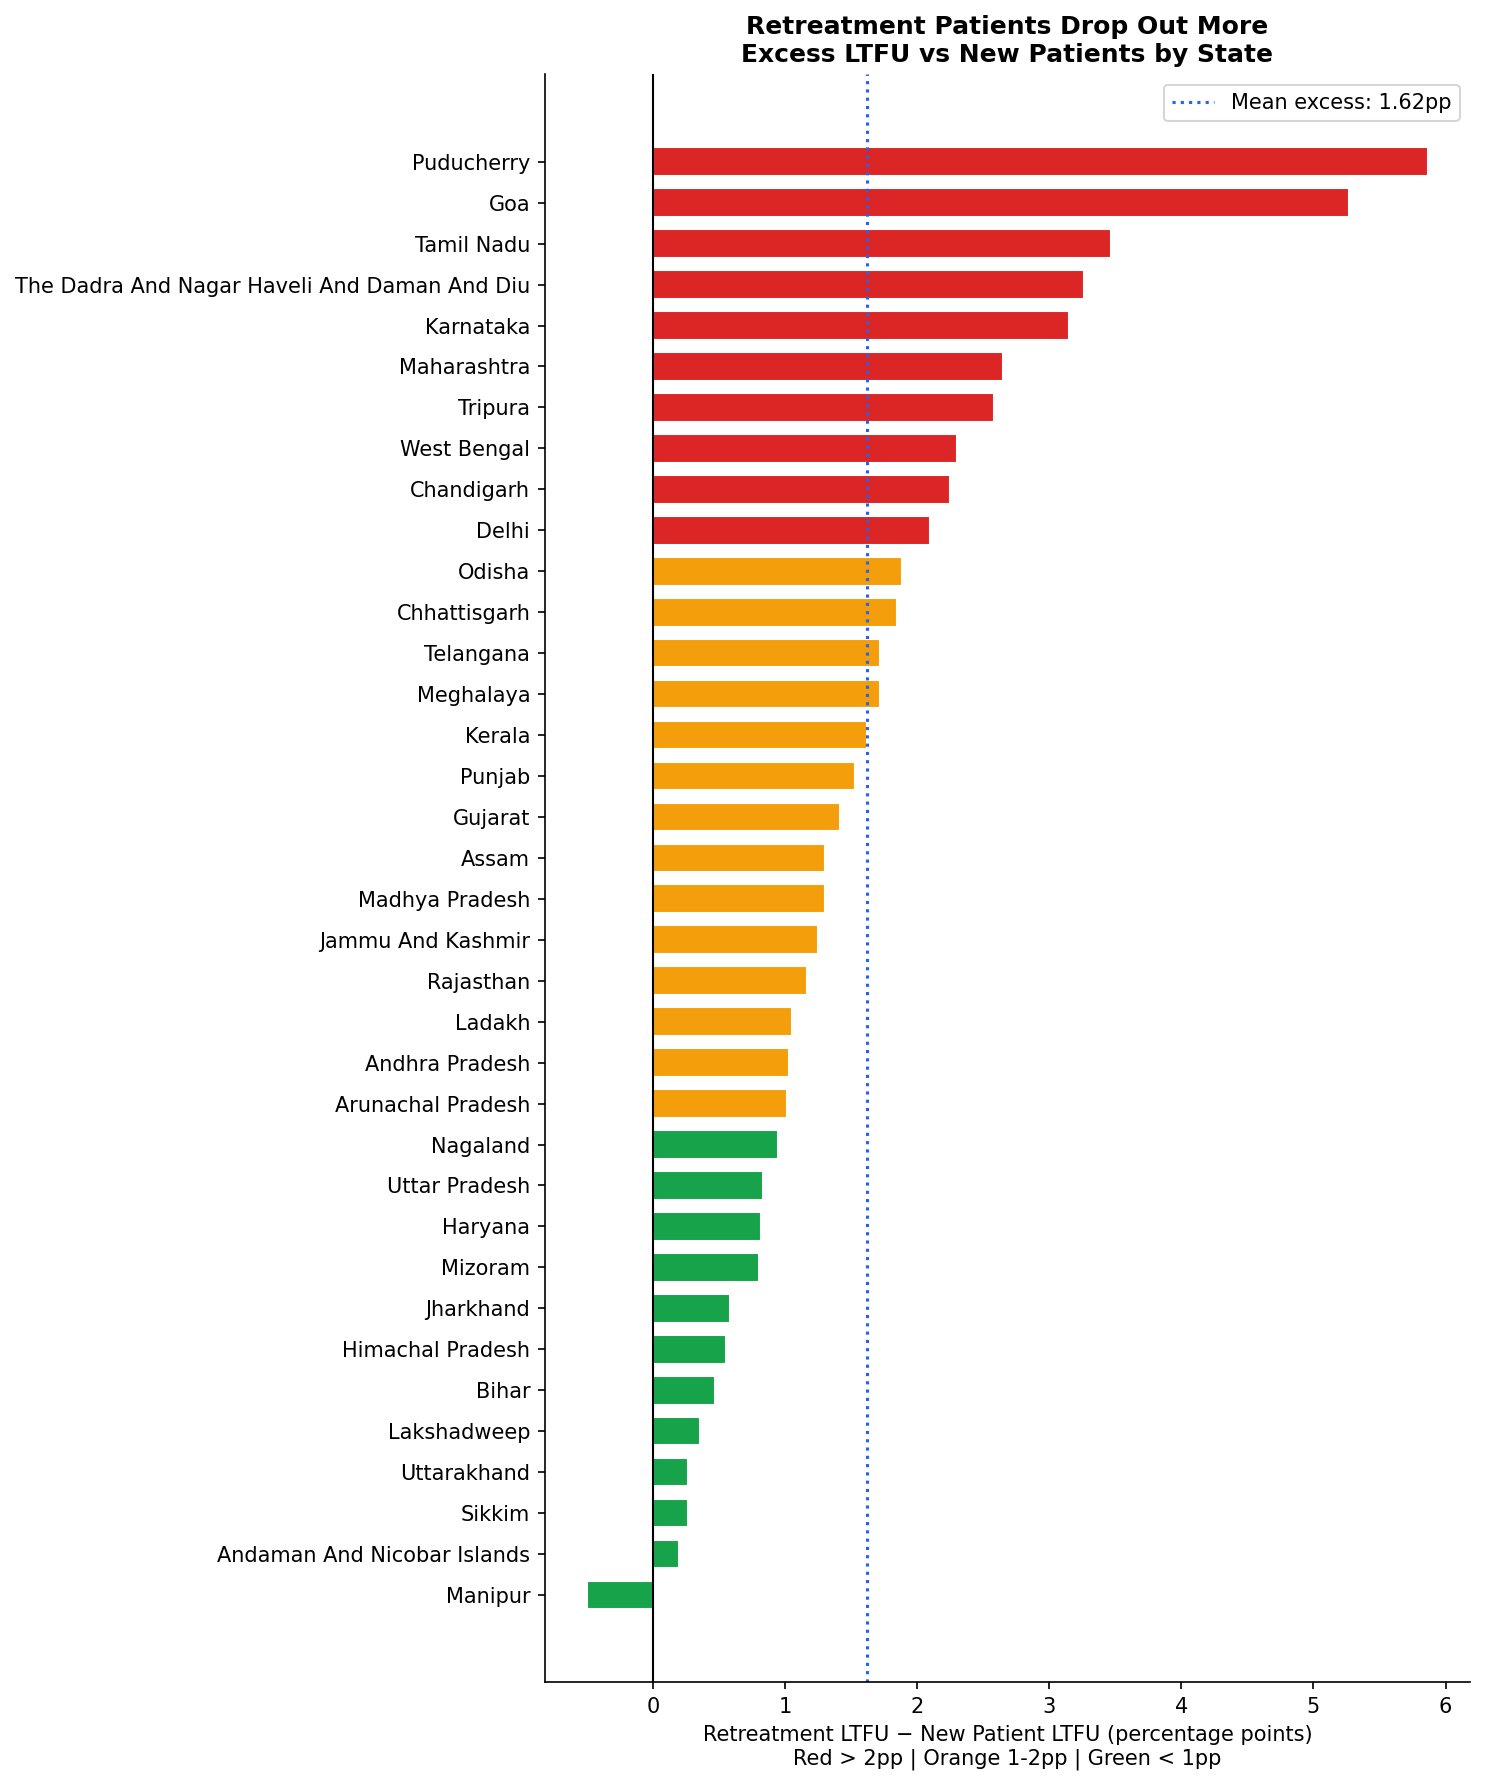

National mean retreatment excess LTFU: 1.62pp
States with excess > 2pp: 10


In [95]:
# ── RETREATMENT EXCESS CHART ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 12))

df_retx = comparison.sort_values("retreatment_excess", ascending=True)
colors = [RED if v > 2 else (ORANGE if v > 1 else GREEN) 
          for v in df_retx["retreatment_excess"]]

ax.barh(df_retx["StateName"], df_retx["retreatment_excess"],
        color=colors, edgecolor="white", height=0.7)
ax.axvline(0, color="black", lw=1)
ax.axvline(df_retx["retreatment_excess"].mean(), color=BLUE,
           lw=1.5, linestyle=":", 
           label=f"Mean excess: {df_retx['retreatment_excess'].mean():.2f}pp")
ax.set_xlabel("Retreatment LTFU − New Patient LTFU (percentage points)\n"
              "Red > 2pp | Orange 1-2pp | Green < 1pp")
ax.set_title("Retreatment Patients Drop Out More\nExcess LTFU vs New Patients by State",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "18_retreatment_excess.png", bbox_inches="tight")
plt.show()

national_mean_excess = comparison["retreatment_excess"].mean()
print(f"National mean retreatment excess LTFU: {national_mean_excess:.2f}pp")
print(f"States with excess > 2pp: {(comparison['retreatment_excess']>2).sum()}")